<a href="https://colab.research.google.com/github/SergeiVKalinin/camm_hackathon/blob/k4my4r/docs/day_13_08052026/IV_Agent_v1_Kalinin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generating IV data

This module generates dummy IV data for the Schottky diode in series witt resistor and shunted by another resistor. We will use actual data (plus material context and geometric device parameters) as an actual use case later.

Thermal voltage Vt = 25.85 mV
Points generated   : 181
V range            : 0.1 V → 1.2 V


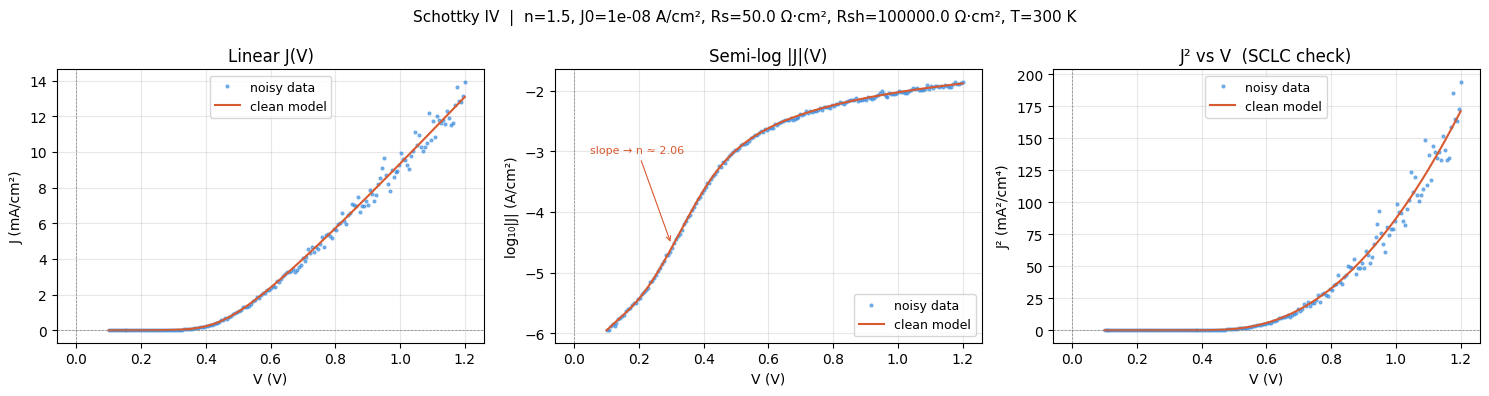

Figure saved: schottky_iv_dummy.png
CSV saved : schottky_iv_dummy.csv
     V_V  J_clean_Acm2  J_noisy_Acm2    I_noisy_A
0.100000      0.000001      0.000001 1.138445e-08
0.106111      0.000001      0.000001 1.140902e-08
0.112222      0.000001      0.000001 1.341151e-08
0.118333      0.000001      0.000001 1.449763e-08
0.124444      0.000001      0.000001 1.334405e-08
0.130556      0.000002      0.000001 1.479576e-08
0.136667      0.000002      0.000002 1.705349e-08
0.142778      0.000002      0.000002 1.784186e-08
0.148889      0.000002      0.000002 1.940138e-08
0.155000      0.000002      0.000002 1.992256e-08

── Sanity checks ──
J(V=0)             = 0.00e+00 A/cm²  (should be ≈ 0)
J(V=0.1)        = 1.14e-06 A/cm²  (reverse leakage)
J(V=1.2)         = 1.39e-02 A/cm²  (forward injection)
Rectification ratio = 1.2e+04


In [23]:
# ============================================================
#  Schottky IV Dummy Data Generator
#  Model: diode + series resistor (Rs) + shunt resistor (Rsh)
#
#  Equation (implicit, solved via Newton-Raphson):
#    J = J0 * [exp((V - J*Rs) / (n*Vt)) - 1]
#        + (V - J*Rs) / Rsh
#
#  Units: J in A/cm², V in V, Rs/Rsh in Ω·cm²
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── 1. PHYSICAL CONSTANTS ────────────────────────────────────
kB = 8.617333e-5   # Boltzmann constant (eV/K)
q  = 1.0           # charge already absorbed into kB units

# ── 2. DEVICE / MODEL PARAMETERS ────────────────────────────
params = {
    "n"    : 1.5,       # ideality factor
    "J0"   : 1e-8,      # reverse sat. current density (A/cm²)
    "T"    : 300,       # temperature (K)
    "Rs"   : 50.0,      # series resistance (Ω·cm²)
    "Rsh"  : 100000.0,   # shunt resistance  (Ω·cm²)
    "area" : 0.01,      # device area (cm²)
    "noise_pct": 0.05,  # relative noise amplitude (0 = no noise)
    "seed" : 42,        # random seed for reproducibility
}

# ── 3. VOLTAGE SWEEP ─────────────────────────────────────────
V_min   =  0.10   # V
V_max   =  1.20   # V
N_pts   =  181    # number of points

# ── 4. SOLVER ─────────────────────────────────────────────────
def solve_J(V_arr, n, J0, T, Rs, Rsh):
    """
    Solve the implicit diode equation for each voltage using
    Newton-Raphson iteration.

    Returns J in A/cm².
    """
    Vt = kB * T          # thermal voltage (eV → V, since kB in eV/K)
    J  = np.zeros_like(V_arr, dtype=float)

    for idx, V in enumerate(V_arr):
        j = 0.0
        for _ in range(200):
            Vd  = V - j * Rs
            exp_term = np.exp(np.clip(Vd / (n * Vt), -500, 500))
            F   = J0 * (exp_term - 1.0) + Vd / Rsh - j
            dF  = -J0 * Rs * exp_term / (n * Vt) - Rs / Rsh - 1.0
            dj  = -F / dF
            j  += dj
            if abs(dj) < 1e-18:
                break
        J[idx] = j

    return J


# ── 5. GENERATE DATA ─────────────────────────────────────────
def generate_iv(params, V_min, V_max, N_pts):
    rng = np.random.default_rng(params["seed"])
    V   = np.linspace(V_min, V_max, N_pts)

    J_clean = solve_J(
        V,
        n   = params["n"],
        J0  = params["J0"],
        T   = params["T"],
        Rs  = params["Rs"],
        Rsh = params["Rsh"],
    )

    # Additive noise: relative fraction of |J| + floor at J0 level
    if params["noise_pct"] > 0:
        sigma = np.abs(J_clean) * params["noise_pct"] + params["J0"] * 0.1
        noise = rng.normal(0, sigma)
    else:
        noise = np.zeros_like(J_clean)

    J_noisy = J_clean + noise
    I_noisy = J_noisy * params["area"]    # total current (A)

    return V, J_clean, J_noisy, I_noisy


V, J_clean, J_noisy, I_noisy = generate_iv(params, V_min, V_max, N_pts)
Vt = kB * params["T"]

print(f"Thermal voltage Vt = {Vt*1000:.2f} mV")
print(f"Points generated   : {N_pts}")
print(f"V range            : {V_min} V → {V_max} V")


# ── 6. PLOTS ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    f"Schottky IV  |  n={params['n']}, J0={params['J0']:.0e} A/cm², "
    f"Rs={params['Rs']} Ω·cm², Rsh={params['Rsh']} Ω·cm², T={params['T']} K",
    fontsize=11
)

# — Plot 1: Linear J(V) —
ax = axes[0]
ax.plot(V, J_noisy * 1e3, "o", ms=2, color="#378ADD", alpha=0.6, label="noisy data")
ax.plot(V, J_clean * 1e3, "-", lw=1.5, color="#D85A30", label="clean model")
ax.set_xlabel("V (V)")
ax.set_ylabel("J (mA/cm²)")
ax.set_title("Linear J(V)")
ax.legend(fontsize=9)
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.grid(True, alpha=0.3)

# — Plot 2: Semi-log |J|(V) — for extracting n and J0 —
ax = axes[1]
with np.errstate(divide="ignore"):
    logJ_noisy = np.log10(np.abs(J_noisy))
    logJ_clean = np.log10(np.abs(J_clean))

ax.plot(V, logJ_noisy, "o", ms=2, color="#378ADD", alpha=0.6, label="noisy data")
ax.plot(V, logJ_clean, "-", lw=1.5, color="#D85A30", label="clean model")
ax.set_xlabel("V (V)")
ax.set_ylabel("log₁₀|J| (A/cm²)")
ax.set_title("Semi-log |J|(V)")
ax.legend(fontsize=9)
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.grid(True, alpha=0.3)

# Annotate slope region for n extraction
V_fit_mask = (V > 0.1) & (V < 0.5)
if V_fit_mask.sum() > 5:
    coeffs = np.polyfit(V[V_fit_mask], logJ_clean[V_fit_mask], 1)
    n_extracted = 1.0 / (coeffs[0] * Vt * np.log(10))
    ax.annotate(
        f"slope → n ≈ {n_extracted:.2f}",
        xy=(0.3, np.polyval(coeffs, 0.3)),
        xytext=(0.05, np.polyval(coeffs, 0.3) + 1.5),
        fontsize=8, color="#D85A30",
        arrowprops=dict(arrowstyle="->", color="#D85A30", lw=0.8),
    )

# — Plot 3: J² vs V  — SCLC Mott-Gurney check (J ∝ V²) —
ax = axes[2]
J2_noisy = (J_noisy * 1e3) ** 2
J2_clean = (J_clean * 1e3) ** 2
ax.plot(V, J2_noisy, "o", ms=2, color="#378ADD", alpha=0.6, label="noisy data")
ax.plot(V, J2_clean, "-", lw=1.5, color="#D85A30", label="clean model")
ax.set_xlabel("V (V)")
ax.set_ylabel("J² (mA²/cm⁴)")
ax.set_title("J² vs V  (SCLC check)")
ax.legend(fontsize=9)
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("schottky_iv_dummy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: schottky_iv_dummy.png")


# ── 7. EXPORT CSV ─────────────────────────────────────────────
df = pd.DataFrame({
    "V_V"        : np.round(V, 6),
    "J_clean_Acm2" : J_clean,
    "J_noisy_Acm2" : J_noisy,
    "I_noisy_A"    : I_noisy,
})
csv_path = "schottky_iv_dummy.csv"
df.to_csv(csv_path, index=False)
print(f"CSV saved : {csv_path}")
print(df.head(10).to_string(index=False))


# ── 8. QUICK SANITY CHECK ─────────────────────────────────────
print("\n── Sanity checks ──")
J_at_0 = solve_J(np.array([0.0]), **{k: params[k] for k in ["n","J0","T","Rs","Rsh"]})[0]
print(f"J(V=0)             = {J_at_0:.2e} A/cm²  (should be ≈ 0)")

J_rev = J_noisy[0]
J_fwd = J_noisy[-1]
print(f"J(V={V_min})        = {J_rev:.2e} A/cm²  (reverse leakage)")
print(f"J(V={V_max})         = {J_fwd:.2e} A/cm²  (forward injection)")
if J_rev != 0:
    print(f"Rectification ratio = {abs(J_fwd/J_rev):.1e}")

# IV Agent - Iteration 0

In [24]:
!pip install anthropic numpy matplotlib PyGithub -q
!pip install lmfit -q

In [25]:
import anthropic
import numpy as np
import matplotlib.pyplot as plt
import json
import base64
import io
from IPython.display import display, clear_output

import os
import re
import textwrap
from datetime import datetime

import pandas as pd

In [26]:
from google.colab import userdata
ANTHROPIC_API_KEY = userdata.get('Agent_0')
client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
print("✅ Anthropic client ready")

✅ Anthropic client ready


In [27]:
from google.colab import userdata
from github import Github

GITHUB_TOKEN  = userdata.get('GitHub_Classic')
GITHUB_REPO   = "SergeiVKalinin/IV_Agent"  # <-- replace this
GITHUB_FOLDER = "Analysis"
GITHUB_BRANCH     = "main"

gh   = Github(GITHUB_TOKEN)
repo = gh.get_repo(GITHUB_REPO)

print(f"✅ GitHub connected")
print(f"📦 Repo: {repo.full_name}")
print(f"📁 Saving curves to: {GITHUB_FOLDER}/")

/tmp/ipykernel_19679/1827621574.py:9: DeprecationWarning: Argument login_or_token is deprecated, please use auth=github.Auth.Token(...) instead
  gh   = Github(GITHUB_TOKEN)


✅ GitHub connected
📦 Repo: SergeiVKalinin/IV_Agent
📁 Saving curves to: Analysis/


In [28]:
MODEL = "claude-sonnet-4-5"
print(f"✅ Model set to: {MODEL}")

✅ Model set to: claude-sonnet-4-5


### Agent 1: Hypothesis generation

In [29]:
# ╔══════════════════════════════════════════════════════════════╗
#  AGENT 1 — Hypothesis Generator & Data Normalizer
#  Paste as Cell 2.  Requires setup cell (Cell 1) to have run.
#  All functions prefixed a1_ to avoid collisions with other agents.
# ╚══════════════════════════════════════════════════════════════╝

import os, json, re, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anthropic
from datetime import datetime, timezone


# ── Configuration (edit here) ─────────────────────────────────
A1_CSV_PATH        = "schottky_iv_dummy.csv"
A1_MATERIAL_PROMPT = "Data as is, Material is ZnO with Au contacts"
A1_GEOMETRY        = {"area_cm2": 0.01, "thickness_nm": 200}
A1_N_HYPOTHESES    = 4
# Session scope expected: ANTHROPIC_API_KEY, MODEL,
#                         repo, GITHUB_FOLDER, GITHUB_BRANCH


# ══════════════════════════════════════════════════════════════
#  SECTION 1 — NORMALIZATION
# ══════════════════════════════════════════════════════════════

def a1_load_and_normalize(csv_path, geometry):
    df = pd.read_csv(csv_path)
    print(f"[A1] Loaded {len(df)} rows  columns={list(df.columns)}")

    V = df["V_V"].values.astype(float)

    if "J_noisy_Acm2" in df.columns:
        J = df["J_noisy_Acm2"].values.astype(float)
        print("[A1] J column used directly (A/cm²).")
    elif "I_noisy_A" in df.columns:
        J = df["I_noisy_A"].values.astype(float) / geometry["area_cm2"]
        print(f"[A1] I→J via area={geometry['area_cm2']} cm²")
    elif "I_A" in df.columns:
        J = df["I_A"].values.astype(float) / geometry["area_cm2"]
    else:
        raise ValueError("CSV needs J_noisy_Acm2, I_noisy_A, or I_A column.")

    d_nm = geometry.get("thickness_nm")
    E_MVcm = (V / (d_nm * 1e-7) / 1e6) if d_nm else None

    eps  = 1e-30
    absJ = np.abs(J)
    lnJ  = np.where(absJ > eps, np.log(absJ),   np.nan)
    logJ = np.where(absJ > eps, np.log10(absJ), np.nan)
    J2   = J ** 2
    sqrtE = np.sqrt(np.abs(E_MVcm)) if E_MVcm is not None else None

    pos, neg = V > 0, V < 0
    J_at_0   = float(np.interp(0.0, V, J))
    J_fwd    = float(np.max(J[pos])) if pos.any() else None
    J_rev    = float(np.min(J[neg])) if neg.any() else None
    rect     = abs(J_fwd / J_rev) if (J_fwd and J_rev and J_rev != 0) else None

    lv = (V > -0.1) & (V < 0.1)
    slope_lv = float(np.polyfit(V[lv], J[lv], 1)[0]) if lv.sum() > 3 else None
    Rsh_est  = (1.0 / slope_lv) if slope_lv and slope_lv != 0 else None

    fl = (V > 0.1) & (V < 0.5) & (absJ > eps)
    if fl.sum() > 3 and not np.all(np.isnan(lnJ[fl])):
        sf = float(np.polyfit(V[fl], lnJ[fl], 1)[0])
        n_est = 1.0 / (sf * 8.617e-5 * 300) if sf > 0 else None
    else:
        n_est = None

    normalized = {"V": V, "J": J, "E_MVcm": E_MVcm,
                  "lnJ": lnJ, "logJ": logJ, "J2": J2, "sqrtE": sqrtE}
    stats = {
        "n_points": int(len(V)),
        "V_range": [float(V.min()), float(V.max())],
        "J_at_0V": J_at_0, "J_max_forward": J_fwd, "J_min_reverse": J_rev,
        "rectification": rect, "Rsh_estimate_ohm": Rsh_est,
        "n_ideality_est": n_est,
        "area_cm2": geometry.get("area_cm2"),
        "thickness_nm": geometry.get("thickness_nm"),
    }
    disp = {k: round(v, 5) if isinstance(v, float) else v for k, v in stats.items()}
    print(f"[A1] Stats:\n{json.dumps(disp, indent=4)}")
    return normalized, stats


# ══════════════════════════════════════════════════════════════
#  SECTION 2 — LLM HYPOTHESIS GENERATION
# ══════════════════════════════════════════════════════════════

A1_SYSTEM_PROMPT = textwrap.dedent("""
    You are an expert in semiconductor physics and thin-film device transport.
    Propose conduction mechanisms for a metal/oxide/metal or Schottky-type device.

    For each mechanism provide ALL fields:
      1. mechanism_name        — short label
      2. description           — 1-2 sentences of physical reasoning
      3. dominant_regime       — "forward","reverse","both","high-field","low-field"
      4. equation_latex        — J(V) or J(E) in LaTeX
      5. equation_python       — single-line Python lambda string:
                                   lambda V, E, T, p: ...
                                 V,E are numpy arrays; T float (K);
                                 p dict of free params. numpy only (np.*).
      6. free_params           — list of dicts with keys:
                                   name, symbol, units,
                                   init_guess, bounds_low, bounds_high
      7. normalization_needed  — subset of [V,J,E_MVcm,lnJ,logJ,J2,sqrtE]
      8. literature_ref        — "Author et al., Year, Journal"
      9. priority              — int, 1=most likely

    Return ONLY a valid JSON array. No markdown, no preamble.
""")


def a1_build_prompt(material_prompt, stats, n_hyp,
                    orch_feedback=None, iteration=1):
    fb = ""
    if orch_feedback:
        fb = (f"\nORCHESTRATOR FEEDBACK (iter {iteration}):\n{orch_feedback}\n"
              "Do NOT repeat rejected mechanisms. Follow circuit suggestions.\n")

    def f(v, s=".3e"): return format(v, s) if v is not None else "N/A"

    return textwrap.dedent(f"""
        MATERIAL: {material_prompt}
        IV STATS:
          V range       : {stats['V_range'][0]:.2f} to {stats['V_range'][1]:.2f} V
          J(V=0)        : {f(stats['J_at_0V'])} A/cm²
          J_fwd max     : {f(stats['J_max_forward'])} A/cm²
          J_rev min     : {f(stats['J_min_reverse'])} A/cm²
          Rectification : {f(stats['rectification'],'.2e')}
          Rsh estimate  : {f(stats['Rsh_estimate_ohm'],'.1f')} Ω·cm²
          Ideality n    : {f(stats['n_ideality_est'],'.2f')}
          Area          : {stats['area_cm2']} cm²
          Thickness     : {stats['thickness_nm']} nm
        {fb}
        Generate exactly {n_hyp} hypotheses for this material system.
        Relevant mechanisms: Schottky emission, Poole-Frenkel, Fowler-Nordheim,
        trap-assisted tunneling, SCLC (Mott-Gurney ± traps), Mott VRH,
        ES-VRH, grain-boundary transport, equivalent circuit combinations.
        Return ONLY the JSON array.
    """).strip()


def a1_call_llm(material_prompt, stats, n_hyp,
                orch_feedback=None, iteration=1):
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    msg    = a1_build_prompt(material_prompt, stats, n_hyp,
                              orch_feedback, iteration)
    print(f"[A1] Calling {MODEL}  iteration={iteration} ...")
    resp = client.messages.create(
        model=MODEL, max_tokens=4096,
        system=A1_SYSTEM_PROMPT,
        messages=[{"role": "user", "content": msg}],
    )
    raw = resp.content[0].text.strip()
    raw = re.sub(r"^```[a-z]*\s*", "", raw, flags=re.IGNORECASE)
    raw = re.sub(r"\s*```$", "", raw)
    hyps = json.loads(raw)
    print(f"[A1] Got {len(hyps)} hypotheses:")
    for h in sorted(hyps, key=lambda x: x.get("priority", 99)):
        print(f"  [{h.get('priority','?')}] "
              f"{h.get('mechanism_name','?'):<35s}"
              f"  regime={h.get('dominant_regime','?')}")
    return hyps


# ══════════════════════════════════════════════════════════════
#  SECTION 3 — OUTPUT ASSEMBLY
# ══════════════════════════════════════════════════════════════

def a1_assemble_output(normalized, stats, hypotheses,
                       material_prompt, geometry, iteration):
    """6-arg assembly. Unique name — never overwritten by other agents."""
    V, J = normalized["V"], normalized["J"]

    def arr(a):
        if a is None: return None
        return [None if (v is not None and np.isnan(float(v)))
                else float(v) for v in a]

    return {
        "meta": {
            "agent": "agent1_hypothesis",
            "timestamp": datetime.now(timezone.utc).isoformat(),
            "iteration": iteration,
            "material_prompt": material_prompt,
            "geometry": geometry,
            "model_used": MODEL,
        },
        "normalized_data": {
            "V_V":    V.tolist(),
            "J_Acm2": J.tolist(),
            "E_MVcm": arr(normalized["E_MVcm"]),
            "lnJ":    arr(normalized["lnJ"]),
            "logJ":   arr(normalized["logJ"]),
            "J2":     normalized["J2"].tolist(),
            "sqrtE":  arr(normalized["sqrtE"]),
        },
        "iv_stats":  stats,
        "hypotheses": hypotheses,
        "agent2_instructions": {
            "fit_each_hypothesis": True,
            "temperature_K": 300,
            "fit_V_range": [-0.5, 1.0],
            "use_log_scale_for_fit": True,
            "return_fields": ["mechanism_name", "fit_params", "param_errors",
                              "R2", "chi2", "residuals_rms", "fit_success"],
        },
    }


# ══════════════════════════════════════════════════════════════
#  SECTION 4 — PLOT
# ══════════════════════════════════════════════════════════════

def a1_plot(normalized, stats, output_path):
    V, J, absJ = normalized["V"], normalized["J"], np.abs(normalized["J"])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Agent 1 — Normalized IV Data", fontsize=11)

    axes[0].plot(V, J*1e3, "o", ms=2, color="#378ADD", alpha=0.7)
    axes[0].set(xlabel="V (V)", ylabel="J (mA/cm²)", title="Linear J(V)")
    axes[0].axhline(0, color="gray", lw=0.5, ls="--")
    axes[0].axvline(0, color="gray", lw=0.5, ls="--")
    axes[0].grid(True, alpha=0.3)

    mask = absJ > 0
    axes[1].semilogy(V[mask], absJ[mask], "o", ms=2, color="#D85A30", alpha=0.7)
    n_est = stats.get("n_ideality_est")
    axes[1].set(xlabel="V (V)", ylabel="|J| (A/cm²)",
                title=f"Semi-log [n≈{n_est:.2f}]" if n_est else "Semi-log")
    axes[1].axvline(0, color="gray", lw=0.5, ls="--")
    axes[1].grid(True, alpha=0.3, which="both")

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[A1] Plot saved: {output_path}")


# ══════════════════════════════════════════════════════════════
#  SECTION 5 — GITHUB PUSH
# ══════════════════════════════════════════════════════════════

def a1_push(local_path, iteration=1):
    try:
        fname  = os.path.basename(local_path)
        rpath  = f"{GITHUB_FOLDER}/{fname}"
        content = open(local_path, "rb").read()
        msg    = f"Agent1|iter={iteration}|{datetime.now(timezone.utc):%Y-%m-%d %H:%M} UTC"
        try:
            ex = repo.get_contents(rpath, ref=GITHUB_BRANCH)
            repo.update_file(rpath, msg, content, ex.sha, branch=GITHUB_BRANCH)
            print(f"[A1] ✅ Updated {repo.full_name}/{rpath}")
        except Exception:
            repo.create_file(rpath, msg, content, branch=GITHUB_BRANCH)
            print(f"[A1] ✅ Created {repo.full_name}/{rpath}")
    except Exception as e:
        print(f"[A1] ⚠️  GitHub push failed: {e}")


# ══════════════════════════════════════════════════════════════
#  MAIN
# ══════════════════════════════════════════════════════════════

def run_agent1(
    csv_path              = A1_CSV_PATH,
    material_prompt       = A1_MATERIAL_PROMPT,
    geometry              = A1_GEOMETRY,
    orchestrator_feedback = None,
    n_hypotheses          = A1_N_HYPOTHESES,
    iteration             = 1,
    output_json           = "agent1_output.json",
    output_plot           = "agent1_normalized.png",
):
    print("=" * 62)
    print(f"  AGENT 1  |  Iteration {iteration}  |  {MODEL}")
    print(f"  Prompt  : {material_prompt}")
    if orchestrator_feedback:
        print(f"  Feedback: {orchestrator_feedback[:80].replace(chr(10),' ')}...")
    print("=" * 62)

    normalized, stats = a1_load_and_normalize(csv_path, geometry)

    hypotheses = a1_call_llm(material_prompt, stats, n_hypotheses,
                              orchestrator_feedback, iteration)

    output = a1_assemble_output(normalized, stats, hypotheses,
                                 material_prompt, geometry, iteration)

    with open(output_json, "w") as f:
        json.dump(output, f, indent=2, default=str)
    print(f"[A1] JSON saved: {output_json}")

    a1_plot(normalized, stats, output_plot)
    a1_push(output_json, iteration)
    a1_push(output_plot, iteration)

    print("\n── Hypotheses ──────────────────────────────────────────")
    for h in sorted(hypotheses, key=lambda x: x.get("priority", 99)):
        pnames = [p["name"] for p in h.get("free_params", [])]
        print(f"  [{h.get('priority','?')}] "
              f"{h.get('mechanism_name','?'):<35s}"
              f"  regime={h.get('dominant_regime','?')}")
        print(f"      {h.get('description','')[:90]}")
        print(f"      params: {pnames}")
        print(f"      ref   : {h.get('literature_ref','—')}")
        print()

    print(f"[A1] ✅ Done → '{output_json}'")
    return output

print("✅ Agent 1 loaded  (run_agent1 ready)")

✅ Agent 1 loaded  (run_agent1 ready)


### Agent 2: IV Fit

In [30]:
# ╔══════════════════════════════════════════════════════════════╗
#  AGENT 2 — Curve Fitter  (fits log|J|, not linear J)
#  Paste as Cell 3.  All functions prefixed a2_.
#
#  Fitting strategy:
#    Pass 1 — log-space warm start (forward bias only) → good p0
#    Pass 2 — main fit on log|J| over all positive-J points
#    Fallback — linear fit if too few positive-J points
#
#  Metrics reported:
#    R2_log  ← primary quality indicator (fitting objective)
#    R2      ← informational only
# ╚══════════════════════════════════════════════════════════════╝

import os, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime, timezone
from scipy.optimize import curve_fit

try:
    import lmfit
    A2_LMFIT = True
except ImportError:
    A2_LMFIT = False
    print("[A2] lmfit not found — scipy fallback.")


# ── Configuration ─────────────────────────────────────────────
A2_FIT_V_RANGE   = (-0.5, 1.0)
A2_LOG_FIT_V_MIN = 0.05       # lower bound for log-space fit window
A2_MAX_NFEV      = 50000
A2_NOISE_FLOOR   = 1e-9
A2_NR_MAX_ITER   = 200
A2_NR_TOL        = 1e-15
A2_COLORS = ["#378ADD", "#D85A30", "#1D9E75", "#BA7517",
             "#7F77DD", "#D4537E", "#639922", "#E24B4A"]


# ══════════════════════════════════════════════════════════════
#  SECTION 1 — LOAD
# ══════════════════════════════════════════════════════════════

def a2_load(path="agent1_output.json"):
    with open(path) as f:
        data = json.load(f)
    print(f"[A2] Loaded '{path}'  "
          f"iter={data['meta']['iteration']}  "
          f"hyps={len(data['hypotheses'])}")
    return data


def a2_extract_arrays(data):
    nd = data["normalized_data"]
    def to_arr(k):
        v = nd.get(k)
        if v is None:
            return None
        return np.array([np.nan if x is None else x for x in v], dtype=float)
    return {k: to_arr(m) for k, m in
            [("V",     "V_V"),
             ("J",     "J_Acm2"),
             ("E_MVcm","E_MVcm"),
             ("lnJ",   "lnJ"),
             ("logJ",  "logJ"),
             ("J2",    "J2"),
             ("sqrtE", "sqrtE")]}


# ══════════════════════════════════════════════════════════════
#  SECTION 2 — EQUATION HANDLING
# ══════════════════════════════════════════════════════════════

def a2_build_callable(eq_str, free_params, T):
    """
    Compile the equation_python lambda from Agent 1 into a
    callable f(V, *param_values) → J.

    Handles:
      Explicit  — J = f(V, E, T, p)  direct evaluation
      Implicit  — 'Rs' in params → Newton-Raphson solve for J
    """
    pnames      = [p["name"] for p in free_params]
    is_implicit = "Rs" in pnames
    fn          = eval(eq_str, {"np": np})

    if not is_implicit:
        def func(V, *args):
            p = dict(zip(pnames, args))
            return fn(V, np.zeros_like(V), T, p)
    else:
        def func(V, *args):
            p  = dict(zip(pnames, args))
            Rs = p["Rs"]
            Jo = np.zeros_like(V, dtype=float)
            for i, v in enumerate(V):
                j = 0.0
                for _ in range(A2_NR_MAX_ITER):
                    Vd = v - j * Rs
                    try:
                        F  = fn(np.array([Vd]), np.array([0.]), T, p)[0] - j
                        dv = 1e-6
                        Fp = fn(np.array([Vd+dv]), np.array([0.]), T, p)[0]
                        Fm = fn(np.array([Vd-dv]), np.array([0.]), T, p)[0]
                        dF = (Fp - Fm) / (2*dv) * (-Rs) - 1.0
                        if abs(dF) < 1e-30:
                            break
                        dj = -F / dF
                        j += dj
                        if abs(dj) < A2_NR_TOL:
                            break
                    except Exception:
                        break
                Jo[i] = j
            return Jo

    return func, pnames, is_implicit


# ══════════════════════════════════════════════════════════════
#  SECTION 3 — FIT METRICS
# ══════════════════════════════════════════════════════════════

def a2_metrics(J_data, J_fit):
    """
    Compute R² (linear), R²_log (primary), χ²_red, RMS.
    R²_log is the main quality indicator since we fit log|J|.
    """
    res  = J_data - J_fit
    rms  = float(np.sqrt(np.nanmean(res**2)))

    # R² on linear J (informational only)
    ss_r = np.nansum(res**2)
    ss_t = np.nansum((J_data - np.nanmean(J_data))**2)
    R2   = float(1 - ss_r / ss_t) if ss_t > 0 else np.nan

    # R²_log — primary metric, computed on all positive-J points
    pm = (J_data > 0) & (J_fit > 0)
    if pm.sum() > 5:
        ld  = np.log(J_data[pm])
        lf  = np.log(J_fit[pm])
        r   = ld - lf
        ss_rl = np.nansum(r**2)
        ss_tl = np.nansum((ld - np.nanmean(ld))**2)
        R2l = float(1 - ss_rl / ss_tl) if ss_tl > 0 else np.nan
    else:
        R2l = np.nan

    # Reduced chi² with noise model σ = noise_floor + 5%|J|
    sig  = A2_NOISE_FLOOR + 0.05 * np.abs(J_data)
    chi2 = float(np.nansum((res / sig)**2))
    nf   = len(res[np.isfinite(res)])
    chi2r= chi2 / max(nf - 1, 1)

    return {
        "R2":            round(R2,   6),
        "R2_log":        round(R2l,  6) if not np.isnan(R2l) else None,
        "chi2_reduced":  round(chi2r, 4),
        "residuals_rms": float(rms),
    }


# ══════════════════════════════════════════════════════════════
#  SECTION 4 — FIT HELPERS
# ══════════════════════════════════════════════════════════════

def a2_fit_lmfit_log(func_ln, Vf_log, lnJf, fps, p0, blo, bhi):
    """
    Main fitter: lmfit on log|J|.
    Each point weighted equally → every decade counts the same.
    Automatically widens degenerate bounds (min == max) so lmfit
    does not crash on fixed-value parameters from the LLM.
    """
    params = lmfit.Parameters()
    for i, fp in enumerate(fps):
        lo  = blo[i]
        hi  = bhi[i]
        val = p0[i]

        # Widen degenerate bounds — lmfit raises ValueError if min == max
        if lo >= hi:
            if val > 0:
                lo = val * 0.01
                hi = val * 100.0
            elif val < 0:
                lo = val * 100.0
                hi = val * 0.01
            else:
                lo = -1.0
                hi =  1.0
            print(f"  ⚠️  '{fp['name']}': bounds_low>=bounds_high, "
                  f"auto-widened to [{lo:.3g}, {hi:.3g}]")

        # Ensure initial value is strictly inside bounds
        margin = 1e-10 * (hi - lo)
        val    = float(np.clip(val, lo + margin, hi - margin))

        params.add(fp["name"], value=val, min=lo, max=hi)

    def residual(params):
        args = [params[fp["name"]].value for fp in fps]
        try:
            return lnJf - func_ln(Vf_log, *args)
        except Exception:
            return np.full_like(Vf_log, 1e10)

    try:
        r    = lmfit.minimize(residual, params, method="leastsq",
                              max_nfev=A2_MAX_NFEV)
        popt = np.array([r.params[fp["name"]].value for fp in fps])
        pcov = (r.covar if r.covar is not None
                else np.diag([np.nan] * len(popt)))
        note = "lmfit_log_ok" if r.success else f"lmfit_log_warn:{r.message}"
        return popt, pcov, note
    except Exception as e:
        return None, None, f"lmfit_log_failed:{e}"


def a2_fit_scipy_log(func_ln, Vf_log, lnJf, p0, blo, bhi):
    """Scipy fallback: curve_fit on log|J|."""
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            popt, pcov = curve_fit(
                func_ln, Vf_log, lnJf,
                p0=p0, bounds=(blo, bhi), maxfev=A2_MAX_NFEV,
            )
        return popt, pcov, "scipy_log_ok"
    except Exception as e:
        return None, None, f"scipy_log_failed:{e}"


def a2_fit_lmfit_linear(func, Vf, Jf, fps, p0, blo, bhi):
    """
    Linear-space lmfit — fallback only when too few positive-J points
    exist for log fitting (e.g. purely reverse-bias models).
    """
    params = lmfit.Parameters()
    for i, fp in enumerate(fps):
        params.add(fp["name"], value=p0[i], min=blo[i], max=bhi[i])

    def residual(params):
        args = [params[fp["name"]].value for fp in fps]
        try:
            Jp = func(Vf, *args)
            w  = 1.0 / (np.abs(Jf) + A2_NOISE_FLOOR)
            return (Jf - Jp) * w
        except Exception:
            return np.full_like(Vf, 1e10)

    try:
        r    = lmfit.minimize(residual, params, method="leastsq",
                              max_nfev=A2_MAX_NFEV)
        popt = np.array([r.params[fp["name"]].value for fp in fps])
        pcov = (r.covar if r.covar is not None
                else np.diag([np.nan] * len(popt)))
        note = "lmfit_linear_ok" if r.success else f"lmfit_linear_warn:{r.message}"
        return popt, pcov, note
    except Exception as e:
        return None, None, f"lmfit_linear_failed:{e}"


def a2_fit_scipy_linear(func, Vf, Jf, p0, blo, bhi):
    """Scipy linear fallback."""
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            popt, pcov = curve_fit(
                func, Vf, Jf,
                p0=p0, bounds=(blo, bhi), maxfev=A2_MAX_NFEV,
            )
        return popt, pcov, "scipy_linear_ok"
    except Exception as e:
        return None, None, f"scipy_linear_failed:{e}"


# ══════════════════════════════════════════════════════════════
#  SECTION 5 — FIT ONE MODEL
# ══════════════════════════════════════════════════════════════

def a2_fit_one(hyp, arrays, T=300, fit_V_range=A2_FIT_V_RANGE):
    """
    Fit a single conduction mechanism model.

    Pass 1 — log-space warm start on forward-bias points → good p0
    Pass 2 — main log|J| fit on all J>0 points (primary)
    Fallback — linear fit when insufficient positive-J points
    """
    name   = hyp["mechanism_name"]
    eq_str = hyp["equation_python"]
    fps    = hyp["free_params"]
    regime = hyp.get("dominant_regime", "both")
    print(f"\n[A2] Fitting: {name}")

    V, J    = arrays["V"], arrays["J"]
    v_lo, v_hi = fit_V_range
    mask_full  = (V >= v_lo) & (V <= v_hi) & np.isfinite(J)
    Vf, Jf     = V[mask_full], J[mask_full]

    if len(Vf) < len(fps) + 2:
        return a2_fail(hyp, "insufficient_data")

    try:
        func, pnames, implicit = a2_build_callable(eq_str, fps, T)
    except Exception as e:
        return a2_fail(hyp, f"lambda_error:{e}")

    p0  = [p["init_guess"]  for p in fps]
    blo = [p["bounds_low"]  for p in fps]
    bhi = [p["bounds_high"] for p in fps]

    # ── Pass 1: log warm start ────────────────────────────────
    warm_mask = mask_full & (V >= A2_LOG_FIT_V_MIN) & (J > 0)
    if warm_mask.sum() > len(fps) + 1:
        def func_log_warm(V_, *args):
            return np.log(np.clip(func(V_, *args), 1e-30, None))
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                pl, _ = curve_fit(
                    func_log_warm, V[warm_mask], np.log(J[warm_mask]),
                    p0=p0, bounds=(blo, bhi), maxfev=A2_MAX_NFEV,
                )
            p0 = list(pl)
            print("  Pass 1 (log warm start) OK → p0 updated")
        except Exception as e:
            print(f"  Pass 1 (log warm start) skipped: {e}")

    # ── Pass 2: main log|J| fit ───────────────────────────────
    log_mask = mask_full & (J > 0)
    n_log    = log_mask.sum()

    if n_log > len(fps) + 2:
        Vf_log = V[log_mask]
        lnJf   = np.log(J[log_mask])

        def func_ln(V_, *args):
            return np.log(np.clip(func(V_, *args), 1e-30, None))

        if A2_LMFIT:
            popt, pcov, note = a2_fit_lmfit_log(
                func_ln, Vf_log, lnJf, fps, p0, blo, bhi
            )
        else:
            popt, pcov, note = a2_fit_scipy_log(
                func_ln, Vf_log, lnJf, p0, blo, bhi
            )
        print(f"  Pass 2 (log|J| fit, {n_log} pts): {note}")

    else:
        # Fallback: linear fit when not enough positive-J points
        print(f"  ⚠️  Only {n_log} positive-J points — using linear fallback.")
        if A2_LMFIT:
            popt, pcov, note = a2_fit_lmfit_linear(
                func, Vf, Jf, fps, p0, blo, bhi
            )
        else:
            popt, pcov, note = a2_fit_scipy_linear(
                func, Vf, Jf, p0, blo, bhi
            )
        print(f"  Pass 2 (linear fallback): {note}")

    if popt is None:
        return a2_fail(hyp, note)

    # ── Evaluate on full V array ──────────────────────────────
    try:
        Jmod = func(V, *popt)
    except Exception as e:
        return a2_fail(hyp, f"eval_error:{e}")

    mets = a2_metrics(J[mask_full], Jmod[mask_full])
    perr = (np.sqrt(np.diag(np.abs(pcov))).tolist()
            if pcov is not None and np.isfinite(pcov).all()
            else [np.nan] * len(popt))

    fit_params = {n: float(v) for n, v in zip(pnames, popt)}
    fit_errors = {n: float(e) for n, e in zip(pnames, perr)}

    print(f"  R²={mets['R2']:.4f}  R²_log={mets['R2_log']}  "
          f"χ²_r={mets['chi2_reduced']:.2f}")
    for pn, pv, pe in zip(pnames, popt, perr):
        print(f"    {pn:15s} = {pv:.4e}  ± {pe:.2e}")

    return {
        "mechanism_name":   name,
        "fit_success":      True,
        "fit_note":         note,
        "fit_params":       fit_params,
        "param_errors":     fit_errors,
        "J_fit":            Jmod.tolist(),
        "residuals":        (J - Jmod).tolist(),
        "n_points_fitted":  int(log_mask.sum()),
        "fit_V_range_used": list(fit_V_range),
        **mets,
        "equation_latex":   hyp.get("equation_latex", ""),
        "dominant_regime":  regime,
        "priority":         hyp.get("priority", 99),
        "literature_ref":   hyp.get("literature_ref", ""),
        "free_params_meta": fps,
    }


def a2_fail(hyp, reason):
    print(f"  ✗ {reason}")
    return {
        "mechanism_name":   hyp["mechanism_name"],
        "fit_success":      False,
        "fit_note":         reason,
        "fit_params":       {},
        "param_errors":     {},
        "J_fit":            None,
        "residuals":        None,
        "R2":               None,
        "R2_log":           None,
        "chi2_reduced":     None,
        "residuals_rms":    None,
        "n_points_fitted":  0,
        "fit_V_range_used": list(A2_FIT_V_RANGE),
        "equation_latex":   hyp.get("equation_latex", ""),
        "dominant_regime":  hyp.get("dominant_regime", ""),
        "priority":         hyp.get("priority", 99),
        "literature_ref":   hyp.get("literature_ref", ""),
        "free_params_meta": hyp.get("free_params", []),
    }


# ══════════════════════════════════════════════════════════════
#  SECTION 6 — PLOT
# ══════════════════════════════════════════════════════════════

def a2_plot(arrays, results, output_path):
    V, Jd = arrays["V"], arrays["J"]
    ok    = [r for r in results if r["fit_success"] and r["J_fit"]]
    if not ok:
        print("[A2] Nothing to plot.")
        return

    n   = len(ok)
    fig = plt.figure(figsize=(5*n, 8))
    gs  = gridspec.GridSpec(2, n, hspace=0.45, wspace=0.35)

    for ci, res in enumerate(ok):
        Jf  = np.array(res["J_fit"])
        col = A2_COLORS[ci % len(A2_COLORS)]
        R2, R2l = res["R2"], res["R2_log"]

        # Linear
        ax = fig.add_subplot(gs[0, ci])
        ax.plot(V, Jd*1e3, "o", ms=2, color="gray", alpha=0.5, label="data")
        ax.plot(V, Jf*1e3, "-", lw=1.8, color=col,
                label=f"R²={R2:.3f}" if R2 is not None else "fit")
        ax.set(xlabel="V (V)", ylabel="J (mA/cm²)",
               title=res["mechanism_name"][:28])
        ax.legend(fontsize=7)
        ax.axhline(0, color="gray", lw=0.4, ls="--")
        ax.axvline(0, color="gray", lw=0.4, ls="--")
        ax.grid(True, alpha=0.25)

        # Semi-log (fitting objective)
        ax2 = fig.add_subplot(gs[1, ci])
        md  = np.abs(Jd) > 0
        ax2.semilogy(V[md], np.abs(Jd[md]), "o", ms=2,
                     color="gray", alpha=0.5, label="data")
        mf  = np.abs(Jf) > 0
        lbl = f"R²_log={R2l:.4f}" if R2l is not None else "fit"
        ax2.semilogy(V[mf], np.abs(Jf[mf]), "-", lw=1.8,
                     color=col, label=lbl)
        ax2.set(xlabel="V (V)", ylabel="|J| (A/cm²)",
                title="← fitting objective")
        ax2.legend(fontsize=7)
        ax2.axvline(0, color="gray", lw=0.4, ls="--")
        ax2.grid(True, alpha=0.25, which="both")

        ps = "\n".join(f"{k}={v:.3g}"
                       for k, v in list(res["fit_params"].items())[:4])
        ax2.text(0.03, 0.03, ps, transform=ax2.transAxes, fontsize=7,
                 va="bottom", family="monospace",
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

    fig.suptitle("Agent 2 — Model Fits (log|J| objective)", fontsize=11, y=1.01)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[A2] Plot saved: {output_path}")


# ══════════════════════════════════════════════════════════════
#  SECTION 7 — ASSEMBLE OUTPUT
# ══════════════════════════════════════════════════════════════

def a2_assemble_output(results, agent1_data):
    """Unique name — never overwritten by other agents."""
    def sk(r):
        if not r["fit_success"]: return (-999, -999)
        return (r["R2_log"] or -999, r["R2"] or -999)

    ranked = sorted(results, key=sk, reverse=True)
    best   = ranked[0] if ranked and ranked[0]["fit_success"] else {}

    return {
        "meta": {
            "agent":          "agent2_fitter",
            "timestamp":      datetime.now(timezone.utc).isoformat(),
            "iteration":      agent1_data["meta"]["iteration"],
            "material_prompt":agent1_data["meta"]["material_prompt"],
            "geometry":       agent1_data["meta"]["geometry"],
            "temperature_K":  agent1_data["agent2_instructions"]["temperature_K"],
            "lmfit_used":     A2_LMFIT,
            "fit_objective":  "log|J|",
        },
        "iv_stats":        agent1_data["iv_stats"],
        "normalized_data": agent1_data["normalized_data"],
        "fit_results":     ranked,
        "summary": {
            "n_hypotheses":  len(results),
            "n_successful":  sum(1 for r in results if r["fit_success"]),
            "best_model":    best.get("mechanism_name"),
            "best_R2":       best.get("R2"),
            "best_R2_log":   best.get("R2_log"),
        },
        "agent3_instructions": {
            "check_each_fit":          True,
            "physical_reasonableness": True,
            "material_prompt":         agent1_data["meta"]["material_prompt"],
            "temperature_K":           agent1_data["agent2_instructions"]["temperature_K"],
            "fit_objective":           "log|J|",
            "primary_quality_metric":  "R2_log",
            "verdict_options":         ["accepted", "plausible", "marginal", "rejected"],
            "trigger_orchestrator_if": "all_rejected or best_R2_log < 0.99",
        },
    }


# ══════════════════════════════════════════════════════════════
#  SECTION 8 — GITHUB PUSH
# ══════════════════════════════════════════════════════════════

def a2_push(local_path, iteration=1):
    try:
        fname   = os.path.basename(local_path)
        rpath   = f"{GITHUB_FOLDER}/{fname}"
        content = open(local_path, "rb").read()
        msg     = (f"Agent2|iter={iteration}|"
                   f"{datetime.now(timezone.utc):%Y-%m-%d %H:%M} UTC")
        try:
            ex = repo.get_contents(rpath, ref=GITHUB_BRANCH)
            repo.update_file(rpath, msg, content, ex.sha, branch=GITHUB_BRANCH)
            print(f"[A2] ✅ Updated {repo.full_name}/{rpath}")
        except Exception:
            repo.create_file(rpath, msg, content, branch=GITHUB_BRANCH)
            print(f"[A2] ✅ Created {repo.full_name}/{rpath}")
    except Exception as e:
        print(f"[A2] ⚠️  GitHub push failed: {e}")


# ══════════════════════════════════════════════════════════════
#  MAIN
# ══════════════════════════════════════════════════════════════

def run_agent2(
    agent1_json = "agent1_output.json",
    output_json = "agent2_output.json",
    output_plot = "agent2_fits.png",
    fit_V_range = A2_FIT_V_RANGE,
):
    print("=" * 62)
    print("  AGENT 2  |  Curve Fitter  [objective: log|J|]")
    print(f"  lmfit: {'available' if A2_LMFIT else 'not available (scipy)'}")
    print("=" * 62)

    data    = a2_load(agent1_json)
    arrays  = a2_extract_arrays(data)
    T       = data["agent2_instructions"]["temperature_K"]

    results = []
    for hyp in sorted(data["hypotheses"], key=lambda h: h.get("priority", 99)):
        results.append(a2_fit_one(hyp, arrays, T=T, fit_V_range=fit_V_range))

    # Summary table
    print("\n── Results ─────────────────────────────────────────────")
    print(f"  {'Model':<35}  {'R²':>7}  {'R²_log':>8}  {'χ²_r':>8}  OK")
    print("  " + "-" * 65)
    for r in sorted(results, key=lambda x: x.get("R2_log") or -999, reverse=True):
        r2   = f"{r['R2']:.4f}"     if r["R2"]    is not None else "   N/A "
        r2l  = f"{r['R2_log']:.4f}" if r["R2_log"] is not None else "   N/A "
        c2   = f"{r['chi2_reduced']:.2f}" if r["chi2_reduced"] is not None else "  N/A"
        ok   = "✓" if r["fit_success"] else "✗"
        print(f"  {r['mechanism_name']:<35}  {r2:>7}  {r2l:>8}  {c2:>8}  {ok}")

    output = a2_assemble_output(results, data)

    with open(output_json, "w") as f:
        json.dump(output, f, indent=2, default=str)
    print(f"\n[A2] JSON saved: {output_json}")

    a2_plot(arrays, results, output_plot)

    iteration = data["meta"]["iteration"]
    a2_push(output_json, iteration)
    a2_push(output_plot, iteration)

    print(f"\n[A2] ✅ Done.")
    print(f"  Best model : {output['summary']['best_model']}")
    print(f"  Best R²_log: {output['summary']['best_R2_log']}")
    return output

print("✅ Agent 2 loaded  (run_agent2 ready)")

✅ Agent 2 loaded  (run_agent2 ready)


### Agent 3: Evaluator

In [31]:
# ╔══════════════════════════════════════════════════════════════╗
#  AGENT 3 — Judge & Validator
#  Paste as Cell 4.  All functions prefixed a3_.
# ╚══════════════════════════════════════════════════════════════╝

import os, json, re, textwrap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import anthropic
from datetime import datetime, timezone


# ── Configuration ─────────────────────────────────────────────
A3_R2_ACCEPT       = 0.950
A3_R2LOG_ACCEPT    = 0.950
A3_CHI2_ACCEPT     = 10.0
A3_CHI2_REJECT     = 100.0
A3_RMS_WARN_FRAC   = 0.20
A3_R2LOG_THRESHOLD = 0.95   # below this → trigger orchestrator

A3_VERDICT_COLORS = {
    "accepted" : "#1D9E75",
    "plausible": "#378ADD",
    "marginal" : "#BA7517",
    "rejected" : "#D85A30",
    None       : "#888780",
}
A3_VERDICT_RANK = {"accepted": 4, "plausible": 3, "marginal": 2, "rejected": 1}
A3_VERDICT_TABLE = {
    ("good",     "reasonable")  : "accepted",
    ("good",     "borderline")  : "plausible",
    ("good",     "unreasonable"): "marginal",
    ("moderate", "reasonable")  : "plausible",
    ("moderate", "borderline")  : "marginal",
    ("moderate", "unreasonable"): "rejected",
    ("poor",     "reasonable")  : "marginal",
    ("poor",     "borderline")  : "rejected",
    ("poor",     "unreasonable"): "rejected",
    ("rejected", "reasonable")  : "rejected",
    ("rejected", "borderline")  : "rejected",
    ("rejected", "unreasonable"): "rejected",
}


# ══════════════════════════════════════════════════════════════
#  SECTION 1 — LOAD
# ══════════════════════════════════════════════════════════════

def a3_load(path="agent2_output.json"):
    with open(path) as f: data = json.load(f)
    n  = len(data.get("fit_results", []))
    nok = sum(1 for r in data["fit_results"] if r["fit_success"])
    print(f"[A3] Loaded '{path}'  iter={data['meta']['iteration']}")
    print(f"[A3] Material : {data['meta']['material_prompt']}")
    print(f"[A3] Fits     : {nok}/{n} successful")
    print(f"[A3] Best     : {data['summary']['best_model']}  "
          f"R²_log={data['summary']['best_R2_log']}")
    return data


def a3_extract_arrays(data):
    nd = data["normalized_data"]
    def ta(k):
        v = nd.get(k)
        if v is None: return None
        return np.array([np.nan if x is None else x for x in v], dtype=float)
    return {"V": ta("V_V"), "J": ta("J_Acm2"), "E_MVcm": ta("E_MVcm")}


# ══════════════════════════════════════════════════════════════
#  SECTION 2 — NUMERICAL QUALITY CHECK
# ══════════════════════════════════════════════════════════════

def a3_numerical_check(result, iv_stats):
    if not result["fit_success"]:
        return {"quality_score": 0, "flags": ["fit_did_not_converge"],
                "residual_pattern": "N/A", "numerical_verdict": "rejected"}

    flags, deduct = [], 0
    R2    = result.get("R2")
    R2l   = result.get("R2_log")
    chi2r = result.get("chi2_reduced")
    rms   = result.get("residuals_rms")
    resids= result.get("residuals")

    # ── R² linear (informational only — not the fitting objective) ──
    if R2 is not None:
        if R2 < 0.70:
            flags.append(f"R²={R2:.3f} very low (linear, informational)")
            deduct += 10
        elif R2 < 0.90:
            flags.append(f"R²={R2:.3f} moderate (linear, informational)")
            deduct += 5
        # R² > 0.90 in linear space: no penalty — log|J| is the objective

    # ── R²_log (PRIMARY metric — this is what was fitted) ──────────
    if R2l is not None:
        if R2l < 0.95:
            flags.append(f"R²_log={R2l:.3f} very low (poor log-space fit)")
            deduct += 40
        elif R2l < 0.99:
            flags.append(f"R²_log={R2l:.3f} below threshold 0.99")
            deduct += 20

    # ── χ²_reduced ─────────────────────────────────────────────────
    if chi2r is not None:
        if chi2r > A3_CHI2_REJECT:
            flags.append(f"χ²_r={chi2r:.1f} >> 1  (very poor fit)")
            deduct += 35
        elif chi2r > A3_CHI2_ACCEPT:
            flags.append(f"χ²_r={chi2r:.1f} elevated")
            deduct += 10

    # ── Residual structure ──────────────────────────────────────────
    residual_pattern = "random"
    if resids and len(resids) > 10:
        ra = np.array([x if x is not None else np.nan for x in resids])
        ra = ra[np.isfinite(ra)]
        if len(ra) > 10:
            signs = np.sign(ra)
            runs  = int(np.sum(np.diff(signs) != 0)) + 1
            if runs < len(ra) * 0.4:
                flags.append("systematic residual structure (too few sign changes)")
                residual_pattern = "systematic"
                deduct += 20
            n3 = len(ra) // 3
            if np.mean(np.abs(ra[-n3:])) > 3 * np.mean(np.abs(ra[:n3])):
                flags.append("residuals grow at high V — possible missing Rs")
                residual_pattern = "high-V systematic"
                deduct += 15

    # ── RMS relative to signal ──────────────────────────────────────
    Jmax = iv_stats.get("J_max_forward")
    if rms is not None and Jmax and abs(Jmax) > 0:
        if rms / abs(Jmax) > A3_RMS_WARN_FRAC:
            flags.append(f"RMS residual = {rms/abs(Jmax)*100:.1f}% of J_max")
            deduct += 10

    score = max(0, 100 - deduct)
    if   score >= 80: nv = "good"
    elif score >= 55: nv = "moderate"
    elif score >= 30: nv = "poor"
    else:             nv = "rejected"

    return {
        "quality_score"    : score,
        "flags"            : flags or ["no numerical issues"],
        "residual_pattern" : residual_pattern,
        "numerical_verdict": nv,
    }


# ══════════════════════════════════════════════════════════════
#  SECTION 3 — LLM PHYSICAL CHECK
# ══════════════════════════════════════════════════════════════

A3_PHYSICS_SYSTEM = textwrap.dedent("""
    You are an expert in semiconductor device physics specializing in
    metal-oxide thin-film transport and Schottky-type devices.

    Evaluate whether each fitted parameter is physically reasonable
    for the given material system.

    For each parameter provide:
      1. expected_range   — plausible range for this material
      2. value_assessment — "reasonable", "borderline", or "unreasonable"
      3. reasoning        — 1-2 sentences referencing known material properties
      4. severity         — "ok", "minor", "moderate", or "fatal"

    Also check internal consistency between correlated parameters.

    Return ONLY a valid JSON object:
    {
      "parameter_checks": [
        {"param_name","fitted_value","fitted_error","units",
         "expected_range","value_assessment","reasoning","severity"}
      ],
      "consistency_checks": [
        {"check_name","passed","reasoning"}
      ],
      "overall_physical_verdict": "reasonable|borderline|unreasonable",
      "overall_reasoning": "2-3 sentence summary",
      "suggested_next_if_bad": "what to try if rejected"
    }
    No preamble. No markdown. Pure JSON only.
""")


def a3_physical_check(result, material_prompt, geometry, T):
    if not result["fit_success"] or not result["fit_params"]:
        return {"parameter_checks": [], "consistency_checks": [],
                "overall_physical_verdict": "unknown",
                "overall_reasoning": "Fit did not converge.",
                "suggested_next_if_bad": ""}

    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

    plines = []
    for pname, pval in result["fit_params"].items():
        perr  = result["param_errors"].get(pname, float("nan"))
        units = next((fp.get("units","") for fp in result.get("free_params_meta",[])
                      if fp["name"] == pname), "")
        plines.append(f"  {pname:15s} = {pval:.4e} ± {perr:.2e}  [{units}]")

    msg = textwrap.dedent(f"""
        MATERIAL: {material_prompt}
        Area={geometry.get('area_cm2')} cm²  Thickness={geometry.get('thickness_nm')} nm  T={T} K

        MECHANISM: {result['mechanism_name']}
        Equation : {result.get('equation_latex','N/A')}
        Regime   : {result.get('dominant_regime','N/A')}
        Reference: {result.get('literature_ref','N/A')}

        FITTED PARAMETERS:
        {chr(10).join(plines)}

        FIT QUALITY: R²={result.get('R2')}  R²_log={result.get('R2_log')}  χ²_r={result.get('chi2_reduced')}

        Evaluate physical reasonableness. Return ONLY the JSON object.
    """).strip()

    print(f"  [A3] LLM physics check: {result['mechanism_name']} ...")
    resp = client.messages.create(
        model=MODEL, max_tokens=2048,
        system=A3_PHYSICS_SYSTEM,
        messages=[{"role": "user", "content": msg}],
    )
    raw = resp.content[0].text.strip()
    raw = re.sub(r"^```[a-z]*\s*", "", raw, flags=re.IGNORECASE)
    raw = re.sub(r"\s*```$", "", raw)
    try:
        return json.loads(raw)
    except Exception as e:
        print(f"  ⚠️  Physics check parse error: {e}")
        return {"parameter_checks": [], "consistency_checks": [],
                "overall_physical_verdict": "unknown",
                "overall_reasoning": f"Parse error: {e}",
                "suggested_next_if_bad": ""}


# ══════════════════════════════════════════════════════════════
#  SECTION 4 — COMBINE VERDICT
# ══════════════════════════════════════════════════════════════

def a3_combine_verdicts(num_check, phys_check):
    nv = num_check.get("numerical_verdict", "rejected")
    pv = phys_check.get("overall_physical_verdict", "unknown")
    if pv == "unknown": pv = "borderline"
    return A3_VERDICT_TABLE.get((nv, pv), "marginal")


def a3_judge_one(result, material_prompt, geometry, T, iv_stats):
    name = result["mechanism_name"]
    print(f"\n[A3] Judging: {name}")

    num   = a3_numerical_check(result, iv_stats)
    print(f"  Numerical: score={num['quality_score']}  verdict={num['numerical_verdict']}")
    for fl in num["flags"]:
        if fl != "no numerical issues": print(f"    ⚠ {fl}")

    phys  = a3_physical_check(result, material_prompt, geometry, T)
    print(f"  Physical : {phys.get('overall_physical_verdict','?')}")
    print(f"  Reasoning: {phys.get('overall_reasoning','')[:100]}")

    verdict = a3_combine_verdicts(num, phys)
    print(f"  ═► VERDICT: {verdict.upper()}")

    return {
        "mechanism_name":         name,
        "dominant_regime":        result.get("dominant_regime", ""),
        "equation_latex":         result.get("equation_latex", ""),
        "literature_ref":         result.get("literature_ref", ""),
        "priority_agent1":        result.get("priority", 99),
        "R2":                     result.get("R2"),
        "R2_log":                 result.get("R2_log"),
        "chi2_reduced":           result.get("chi2_reduced"),
        "residuals_rms":          result.get("residuals_rms"),
        "fit_params":             result.get("fit_params", {}),
        "param_errors":           result.get("param_errors", {}),
        "numerical_quality_score":num["quality_score"],
        "numerical_verdict":      num["numerical_verdict"],
        "numerical_flags":        num["flags"],
        "residual_pattern":       num["residual_pattern"],
        "physical_verdict":       phys["overall_physical_verdict"],
        "physical_reasoning":     phys["overall_reasoning"],
        "parameter_checks":       phys["parameter_checks"],
        "consistency_checks":     phys.get("consistency_checks", []),
        "suggested_next_if_bad":  phys.get("suggested_next_if_bad", ""),
        "final_verdict":          verdict,
        "verdict_rank":           A3_VERDICT_RANK.get(verdict, 0),
    }


# ══════════════════════════════════════════════════════════════
#  SECTION 5 — ORCHESTRATOR FEEDBACK GENERATION
# ══════════════════════════════════════════════════════════════

A3_ORCH_SYSTEM = textwrap.dedent("""
    You are an expert semiconductor physicist advising an automated IV-curve
    analysis pipeline. Given model verdicts and IV statistics, write a concise
    feedback paragraph for the Hypothesis Generator (Agent 1) saying:
      1. Which mechanisms to avoid and why (1 sentence each)
      2. What new mechanisms or equivalent circuits to try
      3. Specific physical features of the data that constrain the search
    Write 3-6 sentences. Be specific. Plain paragraph text only — no bullets or JSON.
""")


def a3_generate_orch_feedback(judgements, iv_stats, material_prompt):
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

    def _fmt_val(v):
        try:
            return f"{float(v):.3g}"
        except Exception:
            return str(v)

    lines = []
    for j in judgements:
        ps = "; ".join(
            f"{p.get('param_name','?')}="
            f"{_fmt_val(p.get('fitted_value','?'))}"
            f"({p.get('value_assessment','?')})"
            for p in j.get("parameter_checks", [])[:4]
        )
        lines.append(
            f"  [{j['final_verdict'].upper():8s}] {j['mechanism_name']}\n"
            f"    R²={j.get('R2')}  R²_log={j.get('R2_log')}  "
            f"physical={j.get('physical_verdict','?')}\n"
            f"    params: {ps}\n"
            f"    next: {j.get('suggested_next_if_bad','')[:80]}"
        )

    def f(v):
        return str(v) if v is not None else "N/A"

    msg = textwrap.dedent(f"""
        MATERIAL: {material_prompt}
        IV STATS:
          Rectification : {f(iv_stats.get('rectification'))}
          Rsh estimate  : {f(iv_stats.get('Rsh_estimate_ohm'))} Ω·cm²
          Ideality n    : {f(iv_stats.get('n_ideality_est'))}
          J(V=0)        : {f(iv_stats.get('J_at_0V'))} A/cm²

        MODELS TRIED:
        {chr(10).join(lines)}

        Write feedback for Agent 1 telling it what to try next.
    """).strip()

    resp = client.messages.create(
        model=MODEL, max_tokens=512,
        system=A3_ORCH_SYSTEM,
        messages=[{"role": "user", "content": msg}],
    )
    return resp.content[0].text.strip()


# ══════════════════════════════════════════════════════════════
#  SECTION 6 — PLOT
# ══════════════════════════════════════════════════════════════

def a3_plot(arrays, agent2_data, judgements, output_path):
    V, Jd = arrays["V"], arrays["J"]
    frs   = {r["mechanism_name"]: r for r in agent2_data["fit_results"]}
    best  = next((j for j in sorted(judgements,
                                    key=lambda x: x["verdict_rank"], reverse=True)
                  if j["R2"] is not None), None)

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(3, 4, hspace=0.55, wspace=0.40,
                             height_ratios=[2.5, 2, 1.8])

    # Row 0: best fit
    if best:
        fr   = frs.get(best["mechanism_name"], {})
        Jf   = np.array(fr["J_fit"]) if fr.get("J_fit") else None
        col  = A3_VERDICT_COLORS.get(best["final_verdict"], "gray")

        ax = fig.add_subplot(gs[0, :2])
        ax.plot(V, Jd*1e3, "o", ms=2, color="gray", alpha=0.5, label="data")
        if Jf is not None:
            ax.plot(V, Jf*1e3, "-", lw=2, color=col,
                    label=f"{best['mechanism_name']} [{best['final_verdict'].upper()}]")
        ax.set(xlabel="V (V)", ylabel="J (mA/cm²)", title="Best model — linear")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
        ax.axhline(0, color="gray", lw=0.4, ls="--")
        ax.axvline(0, color="gray", lw=0.4, ls="--")

        ax2 = fig.add_subplot(gs[0, 2:])
        absJd = np.abs(Jd); m = absJd > 0
        ax2.semilogy(V[m], absJd[m], "o", ms=2, color="gray", alpha=0.5, label="data")
        if Jf is not None:
            absJf = np.abs(Jf); m2 = absJf > 0
            ax2.semilogy(V[m2], absJf[m2], "-", lw=2, color=col,
                         label=f"R²_log={best['R2_log']:.4f}" if best['R2_log'] else "fit")
        ax2.set(xlabel="V (V)", ylabel="|J| (A/cm²)", title="Best model — semi-log")
        ax2.legend(fontsize=8); ax2.grid(True, alpha=0.25, which="both")
        ax2.axvline(0, color="gray", lw=0.4, ls="--")

    # Row 1: residuals
    for ci, jdg in enumerate(sorted(judgements,
                                    key=lambda x: x["verdict_rank"],
                                    reverse=True)[:4]):
        ax = fig.add_subplot(gs[1, ci])
        fr  = frs.get(jdg["mechanism_name"], {})
        if fr.get("residuals"):
            res = np.array([x if x is not None else np.nan for x in fr["residuals"]])
            col = A3_VERDICT_COLORS.get(jdg["final_verdict"], "gray")
            ax.plot(V, res*1e3, ".", ms=1.5, color=col, alpha=0.7)
            ax.axhline(0, color="black", lw=0.6)
            ax.axvline(0, color="gray",  lw=0.4, ls="--")
        ax.set(xlabel="V (V)", ylabel="ΔJ (mA/cm²)",
               title=f"{jdg['mechanism_name'][:20]}\n[{jdg['final_verdict'].upper()}]")
        ax.title.set_color(A3_VERDICT_COLORS.get(jdg["final_verdict"], "gray"))
        ax.grid(True, alpha=0.2); ax.tick_params(labelsize=7)

    # Row 2: scorecard
    ax_s = fig.add_subplot(gs[2, :3])
    names  = [j["mechanism_name"] for j in judgements]
    scores = [j["numerical_quality_score"] for j in judgements]
    r2ls   = [(j["R2_log"] or 0)*100 for j in judgements]
    colors = [A3_VERDICT_COLORS.get(j["final_verdict"], "gray") for j in judgements]
    x, w   = np.arange(len(names)), 0.35
    ax_s.bar(x-w/2, scores, w, color=colors, alpha=0.85, label="Num. score")
    ax_s.bar(x+w/2, r2ls,   w, color=colors, alpha=0.45, hatch="///", label="R²_log×100")
    ax_s.set_xticks(x)
    ax_s.set_xticklabels([n[:28] for n in names], rotation=25, ha="right", fontsize=8)
    ax_s.set(ylabel="Score / R²_log×100", title="Scorecard", ylim=(0, 110))
    ax_s.axhline(80, color="green",  lw=0.8, ls="--", alpha=0.5)
    ax_s.axhline(55, color="orange", lw=0.8, ls="--", alpha=0.5)
    ax_s.legend(fontsize=7); ax_s.grid(True, alpha=0.2, axis="y")

    # Legend box
    axl = fig.add_subplot(gs[2, 3]); axl.axis("off")
    for i, (v, c) in enumerate(A3_VERDICT_COLORS.items()):
        if v:
            axl.text(0.05, 0.80-i*0.20, "■", color=c, fontsize=18,
                     transform=axl.transAxes)
            axl.text(0.25, 0.82-i*0.20, v, fontsize=9, transform=axl.transAxes)

    fig.suptitle(f"Agent 3 — Judgement | {agent2_data['meta']['material_prompt']}",
                 fontsize=11, y=1.01)
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[A3] Plot saved: {output_path}")


# ══════════════════════════════════════════════════════════════
#  SECTION 7 — FINAL REPORT TEXT
# ══════════════════════════════════════════════════════════════

def a3_build_report(judgements, agent2_data, orch_feedback):
    meta = agent2_data["meta"]
    lines = ["="*68,
             "  AGENT IV — Analysis Report",
             f"  Material  : {meta['material_prompt']}",
             f"  Timestamp : {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')}",
             f"  Iteration : {meta['iteration']}",
             f"  T         : {meta['temperature_K']} K",
             "="*68, ""]

    for label, filt in [("ACCEPTED",  lambda j: j["final_verdict"]=="accepted"),
                         ("PLAUSIBLE", lambda j: j["final_verdict"]=="plausible"),
                         ("MARGINAL",  lambda j: j["final_verdict"]=="marginal"),
                         ("REJECTED",  lambda j: j["final_verdict"]=="rejected")]:
        for j in filter(filt, judgements):
            lines.append(f"  [{label:8s}]  {j['mechanism_name']}")
            lines.append(f"             R²={j['R2']}  R²_log={j['R2_log']}  χ²_r={j['chi2_reduced']}")
    lines.append("")

    best_group = [j for j in judgements if j["final_verdict"] in ("accepted","plausible")]
    if best_group:
        lines += ["BEST MODEL(S)", "-"*50]
        for j in best_group:
            lines += [f"\n  {j['mechanism_name']}  [{j['final_verdict'].upper()}]",
                      f"  Equation : {j['equation_latex']}",
                      f"  Regime   : {j['dominant_regime']}",
                      f"  Ref      : {j['literature_ref']}", ""]
            pm = {p["param_name"]: p for p in j.get("parameter_checks", [])}
            lines.append(f"  {'Param':<16} {'Value':>14} {'±Error':>14}  {'Assessment':<14}  Range")
            lines.append("  " + "-"*75)
            for pn, pv in j["fit_params"].items():
                pe = j["param_errors"].get(pn, float("nan"))
                pc = pm.get(pn, {})
                lines.append(f"  {pn:<16} {pv:>14.4e} {pe:>14.2e}  "
                             f"{pc.get('value_assessment','—'):<14}  "
                             f"{pc.get('expected_range','—')}")
            lines += ["", f"  {j['physical_reasoning']}"]
            for cc in j.get("consistency_checks", []):
                ok = "✓" if cc.get("passed") else "✗"
                lines.append(f"    {ok}  {cc['check_name']}: {cc['reasoning']}")
    lines.append("")

    if orch_feedback:
        lines += ["ORCHESTRATOR FEEDBACK", "-"*50, orch_feedback, ""]
    lines.append("="*68)
    return "\n".join(lines)


# ══════════════════════════════════════════════════════════════
#  SECTION 8 — ASSEMBLE OUTPUT
# ══════════════════════════════════════════════════════════════

def a3_assemble_output(judgements, agent2_data, orch_feedback,
                       final_report, trigger):
    """Unique name — never overwritten by other agents."""
    best = next((j for j in sorted(judgements,
                                   key=lambda x: x["verdict_rank"], reverse=True)
                 if j["R2"] is not None), None)
    return {
        "meta": {
            "agent":          "agent3_judge",
            "timestamp":      datetime.now(timezone.utc).isoformat(),
            "iteration":      agent2_data["meta"]["iteration"],
            "material_prompt":agent2_data["meta"]["material_prompt"],
            "geometry":       agent2_data["meta"]["geometry"],
            "temperature_K":  agent2_data["meta"]["temperature_K"],
            "model_used":     MODEL,
        },
        "iv_stats":    agent2_data["iv_stats"],
        "judgements":  judgements,
        "summary": {
            "n_accepted":  sum(1 for j in judgements if j["final_verdict"]=="accepted"),
            "n_plausible": sum(1 for j in judgements if j["final_verdict"]=="plausible"),
            "n_marginal":  sum(1 for j in judgements if j["final_verdict"]=="marginal"),
            "n_rejected":  sum(1 for j in judgements if j["final_verdict"]=="rejected"),
            "best_model":  best["mechanism_name"] if best else None,
            "best_verdict":best["final_verdict"]  if best else None,
            "best_R2":     best["R2"]             if best else None,
            "best_R2_log": best["R2_log"]         if best else None,
            "trigger_orchestrator": trigger,
        },
        "orchestrator_feedback": orch_feedback,
        "final_report":          final_report,
        "orchestrator_instructions": {
            "trigger":            trigger,
            "feedback_for_agent1":orch_feedback,
            "next_iteration":     agent2_data["meta"]["iteration"] + 1,
            "reason": ("No accepted/plausible model" if trigger
                       else "Satisfactory model found"),
        },
    }


# ══════════════════════════════════════════════════════════════
#  SECTION 9 — GITHUB PUSH
# ══════════════════════════════════════════════════════════════

def a3_push(local_path, iteration=1):
    try:
        fname   = os.path.basename(local_path)
        rpath   = f"{GITHUB_FOLDER}/{fname}"
        content = open(local_path, "rb").read()
        msg     = f"Agent3|iter={iteration}|{datetime.now(timezone.utc):%Y-%m-%d %H:%M} UTC"
        try:
            ex = repo.get_contents(rpath, ref=GITHUB_BRANCH)
            repo.update_file(rpath, msg, content, ex.sha, branch=GITHUB_BRANCH)
            print(f"[A3] ✅ Updated {repo.full_name}/{rpath}")
        except Exception:
            repo.create_file(rpath, msg, content, branch=GITHUB_BRANCH)
            print(f"[A3] ✅ Created {repo.full_name}/{rpath}")
    except Exception as e:
        print(f"[A3] ⚠️  GitHub push failed: {e}")


# ══════════════════════════════════════════════════════════════
#  MAIN
# ══════════════════════════════════════════════════════════════

def run_agent3(
    agent2_json  = "agent2_output.json",
    output_json  = "agent3_output.json",
    output_plot  = "agent3_report.png",
):
    print("=" * 62)
    print("  AGENT 3  |  Judge & Validator")
    print(f"  Input   : {agent2_json}")
    print("=" * 62)

    data       = a3_load(agent2_json)
    arrays     = a3_extract_arrays(data)
    fit_results= data["fit_results"]
    iv_stats   = data["iv_stats"]
    meta       = data["meta"]
    mat_prompt = meta["material_prompt"]
    geometry   = meta["geometry"]
    T          = meta["temperature_K"]
    iteration  = meta["iteration"]

    # Judge each model
    judgements = []
    for result in fit_results:
        judgements.append(
            a3_judge_one(result, mat_prompt, geometry, T, iv_stats)
        )

    # Sort best first
    judgements.sort(key=lambda j: (j["verdict_rank"], j["R2_log"] or 0),
                    reverse=True)

    # Decide trigger
    best_rank   = max((j["verdict_rank"] for j in judgements), default=0)
    best_r2log  = max((j["R2_log"] for j in judgements
                       if j["R2_log"] is not None), default=0.0)
    trigger = (best_rank < A3_VERDICT_RANK["plausible"] or
               best_r2log < A3_R2LOG_THRESHOLD)

    # Orchestrator feedback if needed
    if trigger:
        print("\n[A3] Generating orchestrator feedback ...")
        orch_feedback = a3_generate_orch_feedback(judgements, iv_stats, mat_prompt)
        print(f"[A3] Feedback: {orch_feedback[:120]}...")
    else:
        orch_feedback = ""

    # Summary table
    print("\n── Judgement summary ───────────────────────────────────")
    print(f"  {'Model':<35}  {'Num':>5}  {'Phys':<12}  Verdict")
    print("  " + "-"*65)
    for j in judgements:
        print(f"  {j['mechanism_name']:<35}  "
              f"{j['numerical_quality_score']:>5}  "
              f"{j['physical_verdict']:<12}  "
              f"{j['final_verdict'].upper()}")
    print(f"\n  Trigger orchestrator: {trigger}")

    # Report
    report     = a3_build_report(judgements, data, orch_feedback)
    print("\n" + report)
    report_txt = output_json.replace(".json", "_report.txt")
    with open(report_txt, "w") as f: f.write(report)

    # Assemble and save JSON
    output = a3_assemble_output(judgements, data, orch_feedback, report, trigger)
    with open(output_json, "w") as f:
        json.dump(output, f, indent=2, default=str)
    print(f"[A3] JSON saved: {output_json}")

    # Plot
    a3_plot(arrays, data, judgements, output_plot)

    # Push to GitHub
    a3_push(output_json,  iteration)
    a3_push(output_plot,  iteration)
    a3_push(report_txt,   iteration)

    print(f"\n[A3] ✅ Done.")
    print(f"  Best : {output['summary']['best_model']}")
    print(f"  Verdict: {output['summary']['best_verdict']}")
    print(f"  Orchestrator: {'TRIGGERED' if trigger else 'not needed'}")
    return output

print("✅ Agent 3 loaded  (run_agent3 ready)")

✅ Agent 3 loaded  (run_agent3 ready)


### Agent 4: Orchestartor

In [32]:
# ╔══════════════════════════════════════════════════════════════╗
#  ORCHESTRATOR (AGENT 4) — Pipeline Controller & Strategy Agent
#  Paste as Cell 5.  All functions prefixed a4_.
#  Calls run_agent1, run_agent2, run_agent3 defined in prior cells.
# ╚══════════════════════════════════════════════════════════════╝

import os, json, re, textwrap
import numpy as np
import matplotlib.pyplot as plt
import anthropic
from datetime import datetime, timezone


# ── Configuration ─────────────────────────────────────────────
A4_MAX_ITER          = 4
A4_SUCCESS_R2LOG     = 0.95
A4_SUCCESS_VERDICTS  = {"accepted", "plausible"}
A4_RS_ROLLOVER_FRAC  = 3.0
A4_RSH_LEAKAGE_FRAC  = 0.30
A4_LOW_RECT          = 50.0

A4_STATE_FILE  = "orchestrator_state.json"
A4_FINAL_JSON  = "pipeline_final.json"
A4_FINAL_REPORT= "pipeline_final_report.txt"
A4_FINAL_PLOT  = "pipeline_final_plot.png"


# ══════════════════════════════════════════════════════════════
#  SECTION 1 — STATE MANAGEMENT
# ══════════════════════════════════════════════════════════════

def a4_init_state(material_prompt, geometry, csv_path):
    return {
        "pipeline_version"  : "agent_iv_v2",
        "material_prompt"   : material_prompt,
        "geometry"          : geometry,
        "csv_path"          : csv_path,
        "current_iteration" : 1,
        "max_iterations"    : A4_MAX_ITER,
        "status"            : "running",
        "tried_mechanisms"  : [],
        "verdict_history"   : [],
        "feedback_history"  : [],
        "diagnosis_history" : [],
        "best_result"       : None,
        "created_at"        : datetime.now(timezone.utc).isoformat(),
        "updated_at"        : datetime.now(timezone.utc).isoformat(),
    }


def a4_save_state(state, path=A4_STATE_FILE):
    state["updated_at"] = datetime.now(timezone.utc).isoformat()
    with open(path, "w") as f:
        json.dump(state, f, indent=2, default=str)


def a4_load_state(path=A4_STATE_FILE):
    with open(path) as f: state = json.load(f)
    print(f"[A4] Resuming iter={state['current_iteration']} status={state['status']}")
    return state


def a4_update_state(state, agent3_data, diagnosis, feedback):
    iteration  = agent3_data["meta"]["iteration"]
    judgements = agent3_data["judgements"]

    for j in judgements:
        name = j["mechanism_name"]
        if name not in state["tried_mechanisms"]:
            state["tried_mechanisms"].append(name)

    state["verdict_history"].append({
        "iteration"  : iteration,
        "timestamp"  : datetime.now(timezone.utc).isoformat(),
        "models"     : [{"name":         j["mechanism_name"],
                         "verdict":      j["final_verdict"],
                         "R2":           j["R2"],
                         "R2_log":       j["R2_log"],
                         "numerical":    j["numerical_verdict"],
                         "physical":     j["physical_verdict"],
                         "residual_pat": j["residual_pattern"]}
                        for j in judgements],
        "best_model" : agent3_data["summary"]["best_model"],
        "best_verdict":agent3_data["summary"]["best_verdict"],
        "best_R2_log": agent3_data["summary"]["best_R2_log"],
    })
    state["diagnosis_history"].append(diagnosis)
    if feedback: state["feedback_history"].append(feedback)

    # Track overall best
    best = agent3_data["summary"]
    if (state["best_result"] is None or
            (best["best_R2_log"] or 0) > (state["best_result"].get("best_R2_log") or 0)):
        state["best_result"] = {
            "iteration" : iteration,
            "model"     : best["best_model"],
            "verdict"   : best["best_verdict"],
            "R2"        : best["best_R2"],
            "R2_log"    : best["best_R2_log"],
            "fit_params": next((j["fit_params"] for j in judgements
                                if j["mechanism_name"] == best["best_model"]), {}),
        }


# ══════════════════════════════════════════════════════════════
#  SECTION 2 — CIRCUIT-ELEMENT DIAGNOSIS
# ══════════════════════════════════════════════════════════════

def a4_diagnose(agent2_data, agent3_data):
    iv    = agent3_data["iv_stats"]
    jdgs  = agent3_data["judgements"]
    nd    = agent2_data["normalized_data"]
    V     = np.array(nd["V_V"])
    J     = np.array([x if x is not None else np.nan for x in nd["J_Acm2"]])

    diag = {
        "needs_series_resistance" : False, "Rs_estimate_ohm_cm2" : None,
        "needs_shunt_resistance"  : False, "Rsh_estimate_ohm_cm2": None,
        "needs_parallel_mechanism": False, "evidence"            : [],
    }

    Rsh_est = iv.get("Rsh_estimate_ohm")
    rect    = iv.get("rectification") or 1e6
    J_at_0  = abs(iv.get("J_at_0V") or 0)
    J_max   = abs(iv.get("J_max_forward") or 1)

    if rect < A4_LOW_RECT:
        diag["needs_shunt_resistance"]  = True
        diag["Rsh_estimate_ohm_cm2"]    = Rsh_est
        diag["evidence"].append(f"Low rect ratio ({rect:.1f}) → parallel leakage path.")

    if J_at_0 > A4_RSH_LEAKAGE_FRAC * J_max:
        diag["needs_shunt_resistance"]  = True
        diag["Rsh_estimate_ohm_cm2"]    = Rsh_est
        diag["evidence"].append(f"J(0V)={J_at_0:.2e} is {J_at_0/J_max*100:.0f}% of J_max → shunt.")

    if Rsh_est and Rsh_est < 50000:
        diag["needs_shunt_resistance"]  = True
        diag["Rsh_estimate_ohm_cm2"]    = Rsh_est
        diag["evidence"].append(f"Low-V slope → Rsh≈{Rsh_est:.0f} Ω·cm².")

    best_name = agent3_data["summary"].get("best_model")
    best_fr   = next((r for r in agent2_data["fit_results"]
                      if r["mechanism_name"] == best_name and r.get("residuals")), None)
    if best_fr:
        res = np.array([x if x is not None else np.nan for x in best_fr["residuals"]])
        fin = np.isfinite(res) & np.isfinite(V)
        if fin.sum() > 10:
            idx  = np.where(fin)[0]
            n3   = fin.sum() // 3
            lo   = float(np.sqrt(np.mean(res[idx[:n3]]**2)))
            hi   = float(np.sqrt(np.mean(res[idx[-n3:]]**2)))
            if hi > A4_RS_ROLLOVER_FRAC * lo and lo > 0:
                diag["needs_series_resistance"] = True
                Jhi  = np.abs(J[idx[-n3:]])
                Rhi  = np.abs(res[idx[-n3:]])
                valid= Jhi > 1e-10
                if valid.sum() > 3:
                    Rs_est = float(np.median(Rhi[valid]/Jhi[valid]))
                    diag["Rs_estimate_ohm_cm2"] = Rs_est
                    diag["evidence"].append(
                        f"Residuals grow {hi/lo:.1f}× at high V → Rs≈{Rs_est:.1f} Ω·cm².")
                else:
                    diag["evidence"].append(
                        f"Residuals grow {hi/lo:.1f}× at high V → Rs likely missing.")

    for j in jdgs:
        rp = j.get("residual_pattern","")
        if "high-V systematic" in rp and not diag["needs_series_resistance"]:
            diag["needs_series_resistance"] = True
            diag["evidence"].append(f"Agent 3 flagged high-V systematic in '{j['mechanism_name']}'.")
        if "systematic" in rp and "high-V" not in rp:
            diag["needs_parallel_mechanism"] = True
            diag["evidence"].append(f"Systematic residuals in '{j['mechanism_name']}' → missing parallel path.")

    if not diag["evidence"]:
        diag["evidence"].append("No strong evidence for missing circuit elements.")
    return diag


# ══════════════════════════════════════════════════════════════
#  SECTION 3 — STRATEGY LLM CALL
# ══════════════════════════════════════════════════════════════

A4_STRATEGY_SYSTEM = textwrap.dedent("""
    You are a senior semiconductor physicist advising an automated IV-curve
    analysis pipeline for metal-oxide thin-film devices.

    Given the full history and circuit-element diagnosis, produce a JSON strategy:
    {
      "diagnosis_summary": "2-3 sentences summarising what the data tells us",
      "circuit_suggestion": {
        "add_series_resistance":     true/false,
        "Rs_initial_guess_ohm_cm2":  number or null,
        "add_shunt_resistance":      true/false,
        "Rsh_initial_guess_ohm_cm2": number or null,
        "add_parallel_mechanism":    true/false,
        "parallel_mechanism_name":   string or null
      },
      "new_mechanisms": [
        {"name","motivation","circuit_form","priority"}
      ],
      "mechanisms_to_avoid": [{"name","reason"}],
      "feedback_for_agent1": "Complete instruction paragraph. 4-8 sentences.
        Name mechanisms. Cite data evidence. Give quantitative circuit estimates."
    }
    RULES:
      - new_mechanisms must NOT include anything already tried
      - Be specific about equivalent circuit topology
      - Return ONLY valid JSON. No preamble or markdown.
""")


def a4_strategy_llm(state, agent3_data, diagnosis):
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    iv     = agent3_data["iv_stats"]
    jdgs   = agent3_data["judgements"]

    hist = []
    for vh in state["verdict_history"]:
        for m in vh["models"]:
            hist.append(f"  iter={vh['iteration']} [{m['verdict'].upper():8s}] "
                        f"{m['name']:<35} R²_log={m['R2_log']} "
                        f"num={m['numerical']} phys={m['physical']} resid={m['residual_pat']}")

    detail = []
    for j in jdgs:
        ps = "  ".join(f"{k}={v:.3g}" for k,v in list(j.get("fit_params",{}).items())[:5])
        detail.append(f"  {j['mechanism_name']}\n"
                      f"    verdict={j['final_verdict']}  R²={j['R2']}  R²_log={j['R2_log']}\n"
                      f"    physical: {j['physical_reasoning'][:100]}\n"
                      f"    params: {ps}\n"
                      f"    next: {j.get('suggested_next_if_bad','—')[:80]}")

    diag_str = "\n".join(f"  - {e}" for e in diagnosis["evidence"])

    def f(v): return str(v) if v is not None else "N/A"

    msg = textwrap.dedent(f"""
        MATERIAL: {state['material_prompt']}
        Area={state['geometry'].get('area_cm2')} cm²  Thickness={state['geometry'].get('thickness_nm')} nm
        T={agent3_data['meta']['temperature_K']} K

        IV STATS:
          Rectification : {f(iv.get('rectification'))}
          Rsh estimate  : {f(iv.get('Rsh_estimate_ohm'))} Ω·cm²
          Ideality n    : {f(iv.get('n_ideality_est'))}
          J(V=0)        : {f(iv.get('J_at_0V'))} A/cm²
          J_fwd max     : {f(iv.get('J_max_forward'))} A/cm²

        TRIED MECHANISMS (DO NOT REPEAT):
        {json.dumps(state['tried_mechanisms'], indent=2)}

        FULL VERDICT HISTORY:
        {chr(10).join(hist)}

        LATEST ITERATION DETAIL:
        {chr(10).join(detail)}

        CIRCUIT DIAGNOSIS:
        {diag_str}
          needs_Rs ={diagnosis['needs_series_resistance']}  est={f(diagnosis.get('Rs_estimate_ohm_cm2'))} Ω·cm²
          needs_Rsh={diagnosis['needs_shunt_resistance']}  est={f(diagnosis.get('Rsh_estimate_ohm_cm2'))} Ω·cm²
          needs_parallel={diagnosis['needs_parallel_mechanism']}

        AGENT 3 FEEDBACK:
        {agent3_data.get('orchestrator_feedback','(none)')}

        Return ONLY the strategy JSON.
    """).strip()

    print("[A4] Calling strategy LLM ...")
    resp = client.messages.create(
        model=MODEL, max_tokens=2048,
        system=A4_STRATEGY_SYSTEM,
        messages=[{"role": "user", "content": msg}],
    )
    raw = resp.content[0].text.strip()
    raw = re.sub(r"^```[a-z]*\s*","",raw,flags=re.IGNORECASE)
    raw = re.sub(r"\s*```$","",raw)
    try:
        return json.loads(raw)
    except Exception as e:
        print(f"[A4] ⚠️  Strategy parse error: {e}  — using A3 feedback.")
        return {
            "diagnosis_summary"  : "Parse error.",
            "circuit_suggestion" : {
                "add_series_resistance" : diagnosis["needs_series_resistance"],
                "Rs_initial_guess_ohm_cm2": diagnosis.get("Rs_estimate_ohm_cm2"),
                "add_shunt_resistance"  : diagnosis["needs_shunt_resistance"],
                "Rsh_initial_guess_ohm_cm2": diagnosis.get("Rsh_estimate_ohm_cm2"),
                "add_parallel_mechanism": diagnosis["needs_parallel_mechanism"],
                "parallel_mechanism_name": None,
            },
            "new_mechanisms"     : [],
            "mechanisms_to_avoid": [],
            "feedback_for_agent1": agent3_data.get("orchestrator_feedback",""),
        }


def a4_build_feedback(strategy, state):
    base   = strategy.get("feedback_for_agent1","")
    tried  = ", ".join(f'"{m}"' for m in state["tried_mechanisms"])
    constr = f"\n\nDO NOT propose any of these already-tried mechanisms: {tried}."
    cs     = strategy.get("circuit_suggestion",{})
    hints  = []
    if cs.get("add_series_resistance"):
        v = cs.get("Rs_initial_guess_ohm_cm2")
        hints.append(f"Include series resistance Rs in the equivalent circuit"
                     + (f" (init guess ≈{v:.1f} Ω·cm²)." if v else "."))
    if cs.get("add_shunt_resistance"):
        v = cs.get("Rsh_initial_guess_ohm_cm2")
        hints.append(f"Include shunt resistance Rsh in parallel"
                     + (f" (init guess ≈{v:.1f} Ω·cm²)." if v else "."))
    if cs.get("add_parallel_mechanism") and cs.get("parallel_mechanism_name"):
        hints.append(f"Add a parallel {cs['parallel_mechanism_name']} path.")
    if hints:
        constr += "\nCircuit guidance: " + " ".join(hints)
    return base + constr


# ══════════════════════════════════════════════════════════════
#  SECTION 4 — TERMINATION
# ══════════════════════════════════════════════════════════════

def a4_check_success(agent3_data):
    s   = agent3_data["summary"]
    return (s.get("best_verdict") in A4_SUCCESS_VERDICTS and
            (s.get("best_R2_log") or 0) >= A4_SUCCESS_R2LOG)


def a4_banner(iteration, max_iter, status="running"):
    print("\n" + "█"*62)
    print(f"  ORCHESTRATOR  |  Iteration {iteration}/{max_iter}  |  {status.upper()}")
    print("█"*62)


# ══════════════════════════════════════════════════════════════
#  SECTION 5 — FINAL REPORT & PLOT
# ══════════════════════════════════════════════════════════════

def a4_final_report(state, agent3_data):
    best  = state.get("best_result",{})
    lines = ["="*68,
             "  AGENT IV — Final Pipeline Report",
             f"  Material   : {state['material_prompt']}",
             f"  Timestamp  : {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')}",
             f"  Iterations : {state['current_iteration']}",
             f"  Status     : {state['status'].upper()}",
             "="*68,""]

    if state["status"] == "success" and best:
        lines += ["WINNING MODEL","-"*50,
                  f"  Mechanism : {best['model']}",
                  f"  Verdict   : {best['verdict'].upper()}",
                  f"  R²        : {best['R2']}",
                  f"  R²_log    : {best['R2_log']}",
                  f"  Iteration : {best['iteration']}","",
                  "  Fit parameters:"]
        for pn, pv in best.get("fit_params",{}).items():
            lines.append(f"    {pn:<16} = {pv:.4e}")
    else:
        lines += [f"⚠  ESCALATED after {state['current_iteration']} iterations.",
                  f"  Best : {best.get('model','N/A')}  R²_log={best.get('R2_log','N/A')}",
                  "  Manual review required.",""]

    lines += ["","ITERATION HISTORY","-"*50]
    for vh in state["verdict_history"]:
        lines.append(f"\n  Iter {vh['iteration']}  best={vh['best_model']}  R²_log={vh['best_R2_log']}")
        for m in vh["models"]:
            lines.append(f"    [{m['verdict'].upper():8s}] {m['name']}")
    lines += ["","ALL TRIED","-"*50]
    for i,n in enumerate(state["tried_mechanisms"],1):
        lines.append(f"  {i:2d}. {n}")
    lines += ["","="*68]
    return "\n".join(lines)


def a4_final_plot(state, agent3_data, agent2_data, output_path):
    nd = agent2_data["normalized_data"]
    V  = np.array(nd["V_V"])
    J  = np.array([x if x is not None else np.nan for x in nd["J_Acm2"]])
    best_name = state.get("best_result",{}).get("model")
    best_fr   = next((r for r in agent2_data["fit_results"]
                      if r["mechanism_name"]==best_name and r.get("J_fit")), None)

    fig, axes = plt.subplots(1, 3, figsize=(15,4))
    fig.suptitle(f"Agent IV Final | {state['material_prompt']} | {state['status'].upper()}",
                 fontsize=10)

    # Linear
    axes[0].plot(V, J*1e3,"o",ms=2,color="gray",alpha=0.5,label="data")
    if best_fr:
        Jf = np.array(best_fr["J_fit"])
        axes[0].plot(V, Jf*1e3,"-",lw=2,color="#1D9E75",label=best_name)
    axes[0].set(xlabel="V (V)",ylabel="J (mA/cm²)",title="Best — linear")
    axes[0].legend(fontsize=7); axes[0].grid(True,alpha=0.3)
    axes[0].axhline(0,color="gray",lw=0.4,ls="--")
    axes[0].axvline(0,color="gray",lw=0.4,ls="--")

    # Semi-log
    absJ=np.abs(J); m=absJ>0
    axes[1].semilogy(V[m],absJ[m],"o",ms=2,color="gray",alpha=0.5,label="data")
    if best_fr:
        absJf=np.abs(np.array(best_fr["J_fit"])); m2=absJf>0
        r2l=state.get("best_result",{}).get("R2_log","")
        axes[1].semilogy(V[m2],absJf[m2],"-",lw=2,color="#1D9E75",
                         label=f"R²_log={r2l:.4f}" if r2l else best_name)
    axes[1].set(xlabel="V (V)",ylabel="|J| (A/cm²)",title="Best — semi-log")
    axes[1].legend(fontsize=7); axes[1].grid(True,alpha=0.3,which="both")
    axes[1].axvline(0,color="gray",lw=0.4,ls="--")

    # R²_log progression
    ax = axes[2]
    vc = {"accepted":"#1D9E75","plausible":"#378ADD",
          "marginal":"#BA7517","rejected":"#D85A30"}
    for vh in state["verdict_history"]:
        it = vh["iteration"]
        for m in vh["models"]:
            r2l = m["R2_log"] or 0
            col = vc.get(m["verdict"],"gray")
            ax.scatter(it, r2l, color=col, s=40, zorder=3)
            ax.annotate(m["name"][:16],(it,r2l),
                        textcoords="offset points",xytext=(4,0),
                        fontsize=5,color=col)
    ax.axhline(A4_SUCCESS_R2LOG,color="green",lw=0.8,ls="--",
               label=f"target {A4_SUCCESS_R2LOG}")
    ax.set(xlabel="Iteration",ylabel="R²_log",title="R²_log by iteration",
           ylim=(-0.05,1.05))
    ax.set_xticks(range(1,state["current_iteration"]+1))
    ax.legend(fontsize=7); ax.grid(True,alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_path,dpi=150,bbox_inches="tight")
    plt.show()
    print(f"[A4] Final plot saved: {output_path}")


# ══════════════════════════════════════════════════════════════
#  SECTION 6 — GITHUB PUSH
# ══════════════════════════════════════════════════════════════

def a4_push(local_path, label="orchestrator", iteration=0):
    try:
        fname   = os.path.basename(local_path)
        rpath   = f"{GITHUB_FOLDER}/{fname}"
        content = open(local_path,"rb").read()
        msg     = f"{label}|iter={iteration}|{datetime.now(timezone.utc):%Y-%m-%d %H:%M} UTC"
        try:
            ex = repo.get_contents(rpath, ref=GITHUB_BRANCH)
            repo.update_file(rpath,msg,content,ex.sha,branch=GITHUB_BRANCH)
            print(f"[A4] ✅ Updated {repo.full_name}/{rpath}")
        except Exception:
            repo.create_file(rpath,msg,content,branch=GITHUB_BRANCH)
            print(f"[A4] ✅ Created {repo.full_name}/{rpath}")
    except Exception as e:
        print(f"[A4] ⚠️  GitHub push failed: {e}")


# ══════════════════════════════════════════════════════════════
#  MAIN LOOP
# ══════════════════════════════════════════════════════════════

def run_orchestrator(
    csv_path        = "schottky_iv_dummy.csv",
    material_prompt = "Data as is, Material is ZnO with Au contacts",
    geometry        = {"area_cm2": 0.01, "thickness_nm": 200},
    n_hypotheses    = 4,
    max_iterations  = A4_MAX_ITER,
    resume          = False,
):
    """
    Full pipeline loop.  Calls run_agent1, run_agent2, run_agent3
    which must already be defined in the Colab session.
    """
    if resume and os.path.exists(A4_STATE_FILE):
        state = a4_load_state()
        state["max_iterations"] = max_iterations
    else:
        state = a4_init_state(material_prompt, geometry, csv_path)
        state["max_iterations"] = max_iterations

    feedback = None

    # ══════════════════════════════════════════════════════════
    while state["current_iteration"] <= max_iterations:
        iteration = state["current_iteration"]
        a4_banner(iteration, max_iterations)

        # Agent 1
        print(f"\n{'─'*40}\n  Agent 1  (iteration {iteration})\n{'─'*40}")
        run_agent1(
            csv_path              = csv_path,
            material_prompt       = material_prompt,
            geometry              = geometry,
            orchestrator_feedback = feedback,
            n_hypotheses          = n_hypotheses,
            iteration             = iteration,
        )

        # Agent 2
        print(f"\n{'─'*40}\n  Agent 2  (iteration {iteration})\n{'─'*40}")
        run_agent2()

        # Agent 3
        print(f"\n{'─'*40}\n  Agent 3  (iteration {iteration})\n{'─'*40}")
        run_agent3()

        with open("agent3_output.json") as f: a3_data = json.load(f)
        with open("agent2_output.json") as f: a2_data = json.load(f)

        # Diagnose
        print("\n[A4] Circuit-element diagnosis ...")
        diag = a4_diagnose(a2_data, a3_data)
        for ev in diag["evidence"]: print(f"  → {ev}")

        # Success?
        if a4_check_success(a3_data):
            state["status"] = "success"
            a4_update_state(state, a3_data, diag, "")
            a4_save_state(state)
            a4_banner(iteration, max_iterations, "SUCCESS")
            br = state["best_result"]
            print(f"  ✅  {br['model']}  R²={br['R2']}  R²_log={br['R2_log']}")
            break

        # Max iterations?
        if iteration >= max_iterations:
            state["status"] = "escalated"
            a4_update_state(state, a3_data, diag, "")
            a4_save_state(state)
            a4_banner(iteration, max_iterations, "ESCALATED")
            print(f"  ⚠️  Max iterations reached. Best: {state['best_result']}")
            break

        # Strategy for next iteration
        print(f"\n[A4] Strategy for iteration {iteration+1} ...")
        strategy = a4_strategy_llm(state, a3_data, diag)
        print(f"  Diagnosis: {strategy.get('diagnosis_summary','')[:80]}")
        cs = strategy.get("circuit_suggestion",{})
        print(f"  Add Rs={cs.get('add_series_resistance')} ({cs.get('Rs_initial_guess_ohm_cm2')} Ω·cm²)"
              f"  Add Rsh={cs.get('add_shunt_resistance')} ({cs.get('Rsh_initial_guess_ohm_cm2')} Ω·cm²)")
        for nm in strategy.get("new_mechanisms",[]):
            print(f"  → [{nm.get('priority','?')}] {nm['name']}  ({nm.get('circuit_form','?')})")
            print(f"       {nm.get('motivation','')[:80]}")

        feedback = a4_build_feedback(strategy, state)
        print(f"\n[A4] Feedback preview: {feedback[:150]}...")

        a4_update_state(state, a3_data, diag, feedback)
        state["current_iteration"] += 1
        a4_save_state(state)
        a4_push(A4_STATE_FILE, "state", iteration)

    # ── Finalise ──────────────────────────────────────────────
    with open("agent3_output.json") as f: a3_final = json.load(f)
    with open("agent2_output.json") as f: a2_final = json.load(f)

    report = a4_final_report(state, a3_final)
    print("\n" + report)
    with open(A4_FINAL_REPORT,"w") as f: f.write(report)

    final = {
        "pipeline_status"  : state["status"],
        "material_prompt"  : state["material_prompt"],
        "geometry"         : state["geometry"],
        "total_iterations" : state["current_iteration"],
        "tried_mechanisms" : state["tried_mechanisms"],
        "best_result"      : state["best_result"],
        "verdict_history"  : state["verdict_history"],
        "diagnosis_history": state["diagnosis_history"],
        "feedback_history" : state["feedback_history"],
        "final_judgements" : a3_final["judgements"],
        "timestamp"        : datetime.now(timezone.utc).isoformat(),
    }
    with open(A4_FINAL_JSON,"w") as f: json.dump(final,f,indent=2,default=str)

    a4_final_plot(state, a3_final, a2_final, A4_FINAL_PLOT)

    for fp in [A4_FINAL_JSON, A4_FINAL_REPORT, A4_FINAL_PLOT, A4_STATE_FILE]:
        a4_push(fp, "pipeline-final", state["current_iteration"])

    print(f"\n[A4] ✅ Pipeline complete.")
    print(f"  Status    : {state['status'].upper()}")
    print(f"  Iterations: {state['current_iteration']}")
    if state["best_result"]:
        print(f"  Best model: {state['best_result']['model']}")
        print(f"  R²_log    : {state['best_result']['R2_log']}")
    return state

print("✅ Orchestrator loaded  (run_orchestrator ready)")

✅ Orchestrator loaded  (run_orchestrator ready)



██████████████████████████████████████████████████████████████
  ORCHESTRATOR  |  Iteration 1/3  |  RUNNING
██████████████████████████████████████████████████████████████

────────────────────────────────────────
  Agent 1  (iteration 1)
────────────────────────────────────────
  AGENT 1  |  Iteration 1  |  claude-sonnet-4-5
  Prompt  : Data as is, Material is ZnO with Au contacts
[A1] Loaded 181 rows  columns=['V_V', 'J_clean_Acm2', 'J_noisy_Acm2', 'I_noisy_A']
[A1] J column used directly (A/cm²).
[A1] Stats:
{
    "n_points": 181,
    "V_range": [
        0.1,
        1.2
    ],
    "J_at_0V": 0.0,
    "J_max_forward": 0.01393,
    "J_min_reverse": null,
    "rectification": null,
    "Rsh_estimate_ohm": null,
    "n_ideality_est": 2.05214,
    "area_cm2": 0.01,
    "thickness_nm": 200
}
[A1] Calling claude-sonnet-4-5  iteration=1 ...
[A1] Got 4 hypotheses:
  [1] Thermionic_Emission_Schottky         regime=forward
  [2] Trap_Assisted_Tunneling_TAT          regime=both
  [3] SCLC_wit

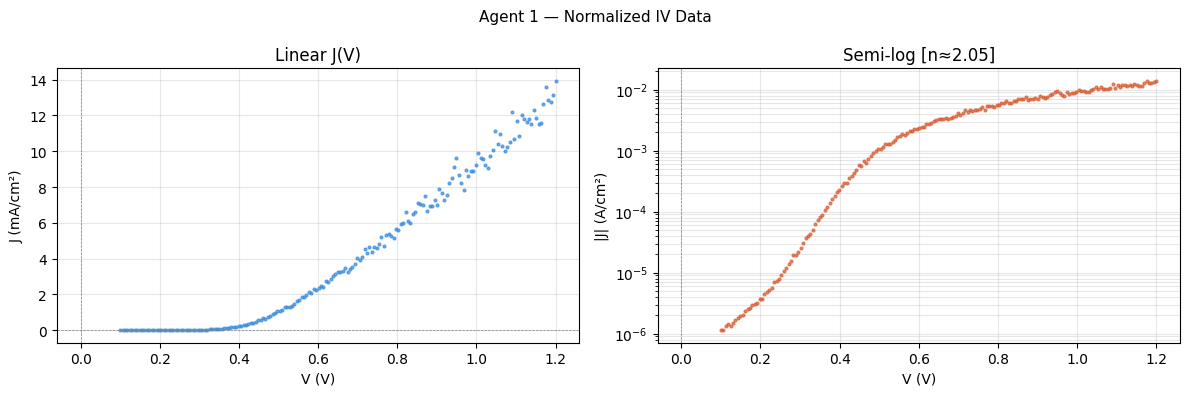

[A1] Plot saved: agent1_normalized.png
[A1] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent1_output.json
[A1] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent1_normalized.png

── Hypotheses ──────────────────────────────────────────
  [1] Thermionic_Emission_Schottky         regime=forward
      Thermionic emission over the Schottky barrier at the Au/ZnO interface, dominant in forward
      params: ['phi_B', 'n_id', 'A_star']
      ref   : Rhoderick & Williams, 1988, Metal-Semiconductor Contacts

  [2] Trap_Assisted_Tunneling_TAT          regime=both
      Trap-assisted tunneling through localized states in ZnO band gap, mediated by oxygen vacan
      params: ['J0_TAT', 'V0_TAT']
      ref   : Simmons, 1967, J. Appl. Phys.

  [3] SCLC_with_Traps                      regime=forward
      Space-charge-limited current with exponential trap distribution in ZnO. At low voltages Oh
      params: ['mu_eff', 'eps_r', 'V_TFL', 'l_trap', 'd_nm']
      ref   : Lampert & Mark, 1970, Current Injec

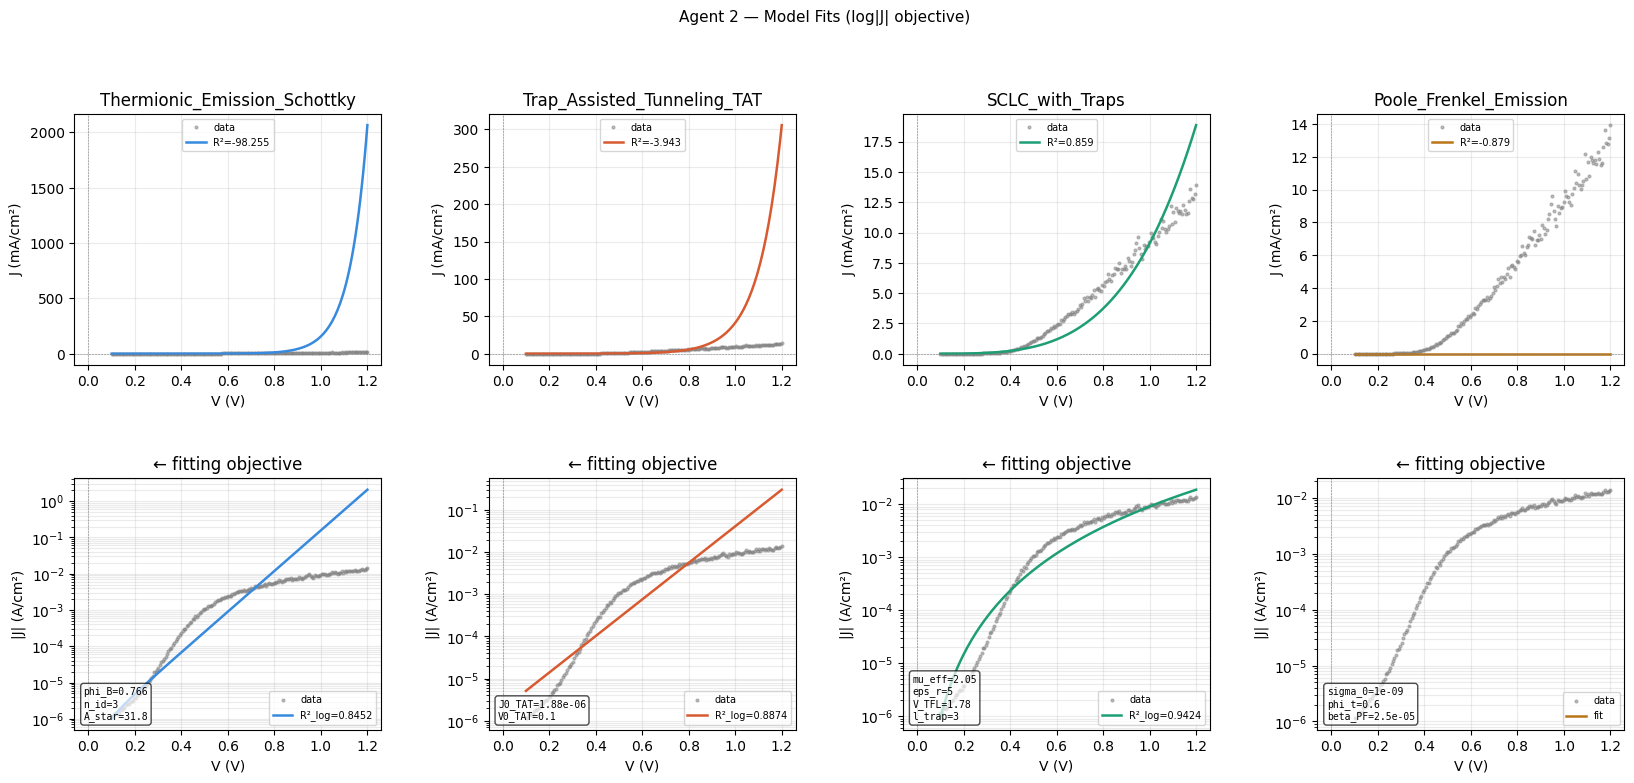

[A2] Plot saved: agent2_fits.png
[A2] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent2_output.json
[A2] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent2_fits.png

[A2] ✅ Done.
  Best model : SCLC_with_Traps
  Best R²_log: 0.942369

────────────────────────────────────────
  Agent 3  (iteration 1)
────────────────────────────────────────
  AGENT 3  |  Judge & Validator
  Input   : agent2_output.json
[A3] Loaded 'agent2_output.json'  iter=1
[A3] Material : Data as is, Material is ZnO with Au contacts
[A3] Fits     : 4/4 successful
[A3] Best     : SCLC_with_Traps  R²_log=0.942369

[A3] Judging: SCLC_with_Traps
  Numerical: score=0  verdict=rejected
    ⚠ R²=0.859 moderate (linear, informational)
    ⚠ R²_log=0.942 very low (poor log-space fit)
    ⚠ χ²_r=561.2 >> 1  (very poor fit)
    ⚠ systematic residual structure (too few sign changes)
    ⚠ residuals grow at high V — possible missing Rs
  [A3] LLM physics check: SCLC_with_Traps ...
  Physical : unreasonable
  Reasoning: The fit has

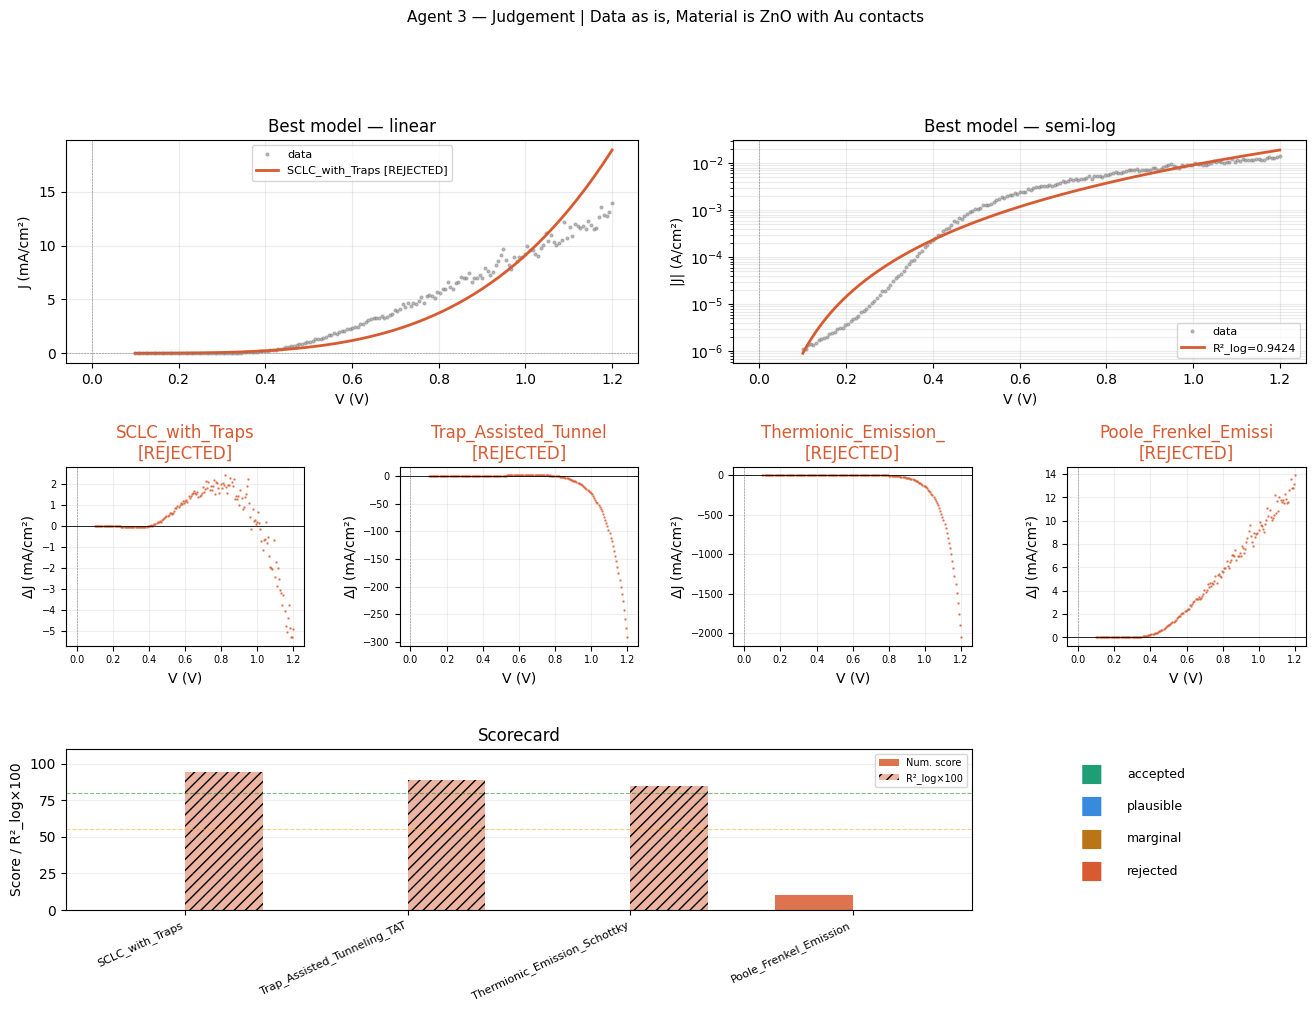

[A3] Plot saved: agent3_report.png
[A3] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent3_output.json
[A3] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent3_report.png
[A3] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent3_output_report.txt

[A3] ✅ Done.
  Best : SCLC_with_Traps
  Verdict: rejected
  Orchestrator: TRIGGERED

[A4] Circuit-element diagnosis ...
  → Residuals grow 39.2× at high V → Rs≈0.2 Ω·cm².

[A4] Strategy for iteration 2 ...
[A4] Calling strategy LLM ...
  Diagnosis: The ideality factor n=2.05 is a textbook signature of Shockley-Read-Hall recombi
  Add Rs=True (0.195 Ω·cm²)  Add Rsh=False (None Ω·cm²)
  → [1] Recombination_Diode_with_Series_R  (J = J0_rec * [exp(q(V-J*Rs*A)/(2*k*T)) - 1] where n=2 fixed, fit J0_rec and Rs)
       Ideality n≈2 directly indicates recombination-generation current in depletion re
  → [2] Two_Diode_Model_Interface_Bulk  (J = J01*[exp(q(V-JRs)/(kT))-1] + J02*[exp(q(V-JRs)/(2kT))-1] + (V-JRs)/Rsh, fit J01, J02, Rs)
       Separate interface

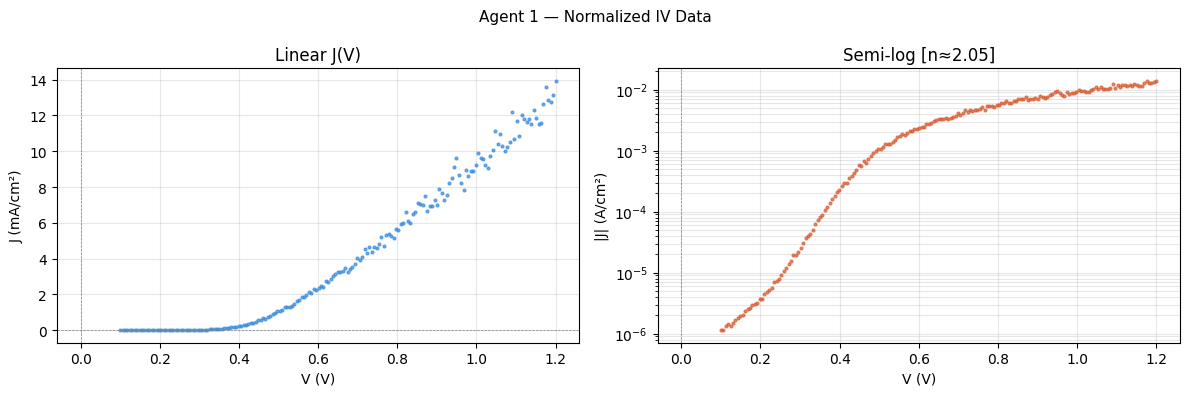

[A1] Plot saved: agent1_normalized.png
[A1] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent1_output.json
[A1] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent1_normalized.png

── Hypotheses ──────────────────────────────────────────
  [1] Recombination_Diode_n2_Series_R      regime=forward
      Interface recombination-dominated diode with fixed ideality factor n=2, accounting for vol
      params: ['J0_rec', 'Rs', 'Area']
      ref   : Sze & Ng, Physics of Semiconductor Devices, 3rd ed., 2007; Rhoderick & Williams, Metal-Semiconductor Contacts, 1988

  [2] Two_Diode_Model_Series_R             regime=forward
      Parallel combination of diffusion diode (n=1) and recombination diode (n=2) with series re
      params: ['J01', 'J02', 'Rs', 'Area']
      ref   : Green, Solar Cells: Operating Principles, Technology and System Applications, 1982; Sze & Ng, 2007

  [3] SRH_Recombination_Midgap_Series_R    regime=forward
      Shockley-Read-Hall recombination through midgap interface states 

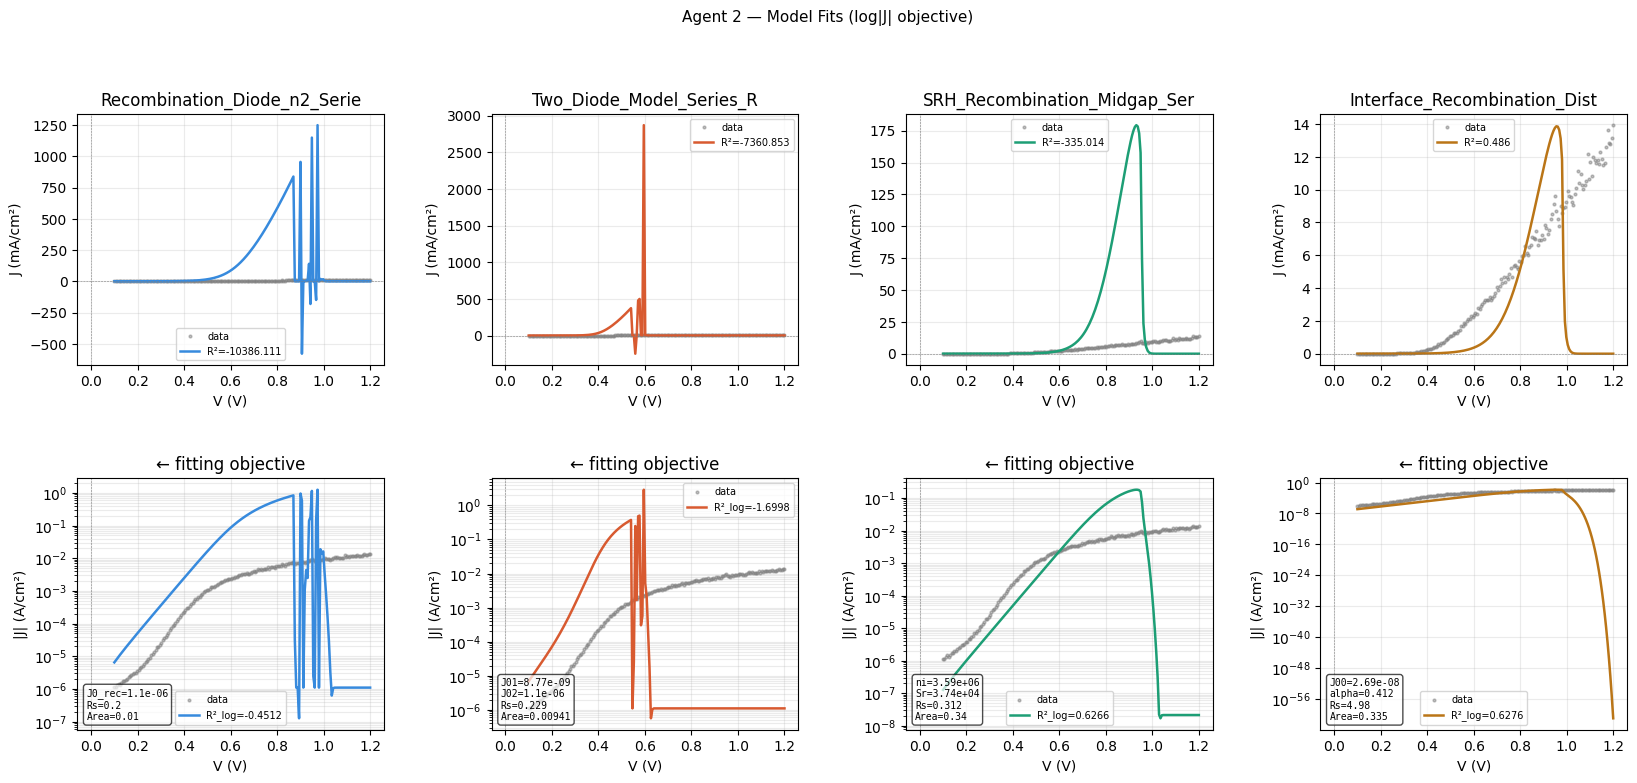

[A2] Plot saved: agent2_fits.png
[A2] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent2_output.json
[A2] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent2_fits.png

[A2] ✅ Done.
  Best model : Interface_Recombination_Distributed_Traps_Series_R
  Best R²_log: 0.627643

────────────────────────────────────────
  Agent 3  (iteration 2)
────────────────────────────────────────
  AGENT 3  |  Judge & Validator
  Input   : agent2_output.json
[A3] Loaded 'agent2_output.json'  iter=2
[A3] Material : Data as is, Material is ZnO with Au contacts
[A3] Fits     : 4/4 successful
[A3] Best     : Interface_Recombination_Distributed_Traps_Series_R  R²_log=0.627643

[A3] Judging: Interface_Recombination_Distributed_Traps_Series_R
  Numerical: score=0  verdict=rejected
    ⚠ R²=0.486 very low (linear, informational)
    ⚠ R²_log=0.628 very low (poor log-space fit)
    ⚠ χ²_r=227.3 >> 1  (very poor fit)
    ⚠ systematic residual structure (too few sign changes)
    ⚠ residuals grow at high V — possible mi

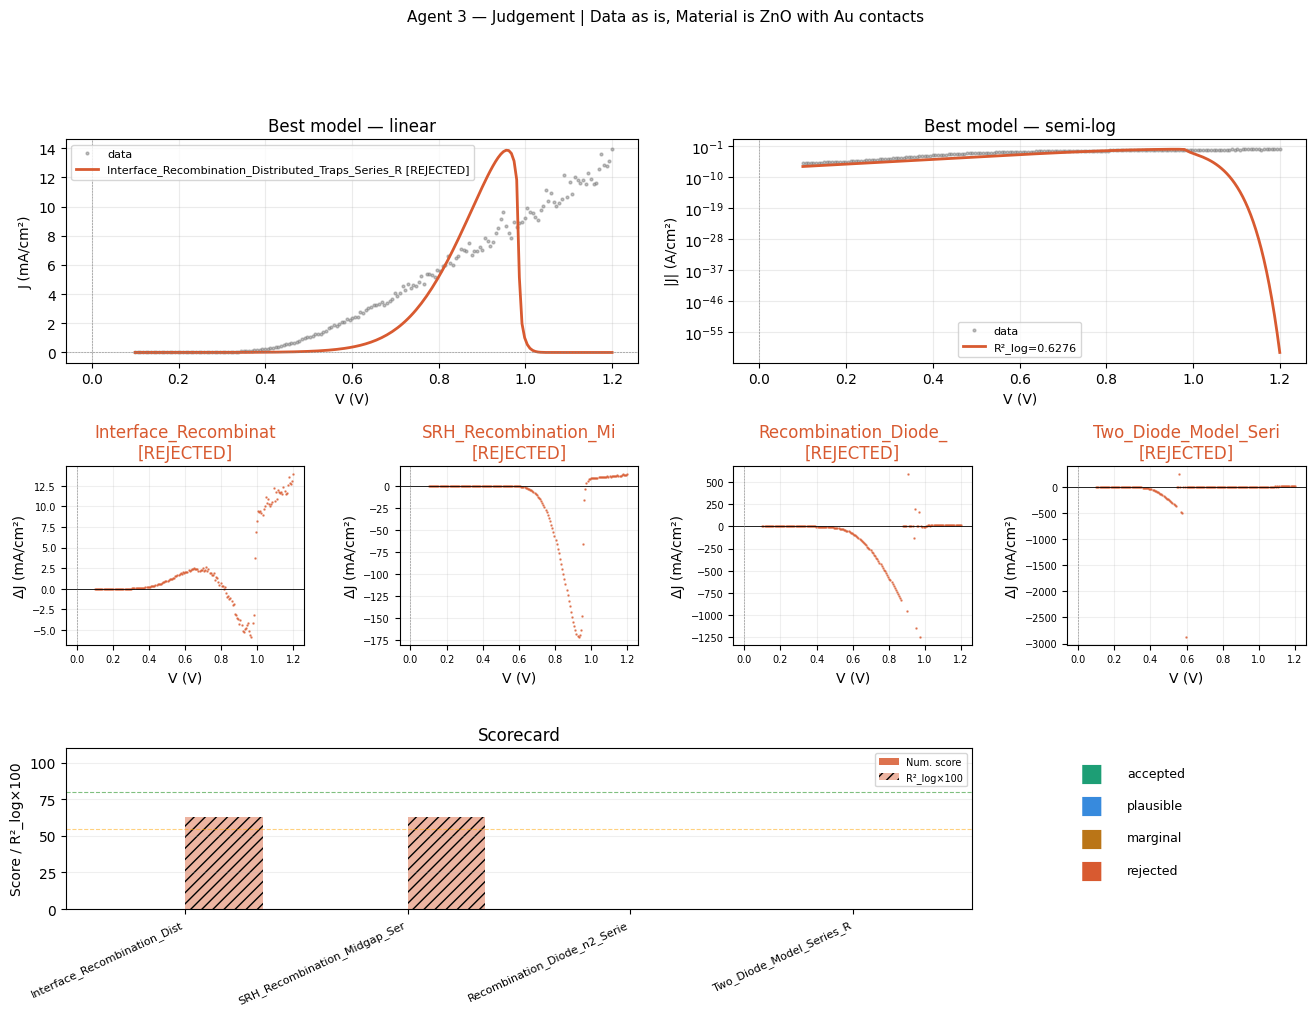

[A3] Plot saved: agent3_report.png
[A3] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent3_output.json
[A3] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent3_report.png
[A3] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent3_output_report.txt

[A3] ✅ Done.
  Best : Interface_Recombination_Distributed_Traps_Series_R
  Verdict: rejected
  Orchestrator: TRIGGERED

[A4] Circuit-element diagnosis ...
  → Residuals grow 49.0× at high V → Rs≈1.0 Ω·cm².
  → Systematic residuals in 'Two_Diode_Model_Series_R' → missing parallel path.

[A4] Strategy for iteration 3 ...
[A4] Calling strategy LLM ...
  Diagnosis: The Au/ZnO interface exhibits severely degraded Schottky behavior with n=2.05 an
  Add Rs=True (1.0 Ω·cm²)  Add Rsh=True (8800 Ω·cm²)
  → [1] Ohmic_Leakage_Plus_Series_R  (J = V / (R_total_ohm_cm2), fit R_total as single parameter)
       Test if device is simply resistive with no true rectification. The J(V=0)=1.14e-
  → [2] Schottky_Emission_Barrier_Lowering_Series_R  (J = J_s(T) exp[-q(Φ_

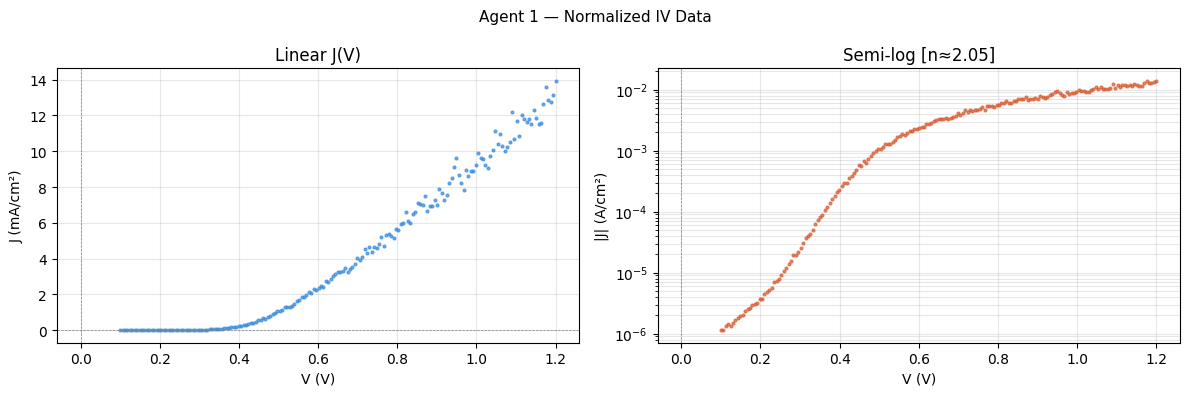

[A1] Plot saved: agent1_normalized.png
[A1] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent1_output.json
[A1] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent1_normalized.png

── Hypotheses ──────────────────────────────────────────
  [1] Ohmic_Leakage_Plus_Series_R          regime=both
      Pure resistive transport baseline model with series resistance to verify any nonlinearity 
      params: ['Rsh', 'Rs']
      ref   : Sze & Ng, Physics of Semiconductor Devices, 2007

  [2] Schottky_Emission_Barrier_Lowering_Series_R  regime=forward
      Thermionic emission with image-force barrier lowering at metal-semiconductor interface. J 
      params: ['A_star', 'Phi_B', 'beta', 'Rs']
      ref   : Rhoderick & Williams, Metal-Semiconductor Contacts, 1988

  [3] Multistep_Tunneling_Through_Interface_States  regime=both
      Trap-assisted tunneling through localized interface states with power-law voltage dependen
      params: ['C', 'm', 'E_t', 'V0', 'Rs']
      ref   : Simmons, J. Appl. Ph

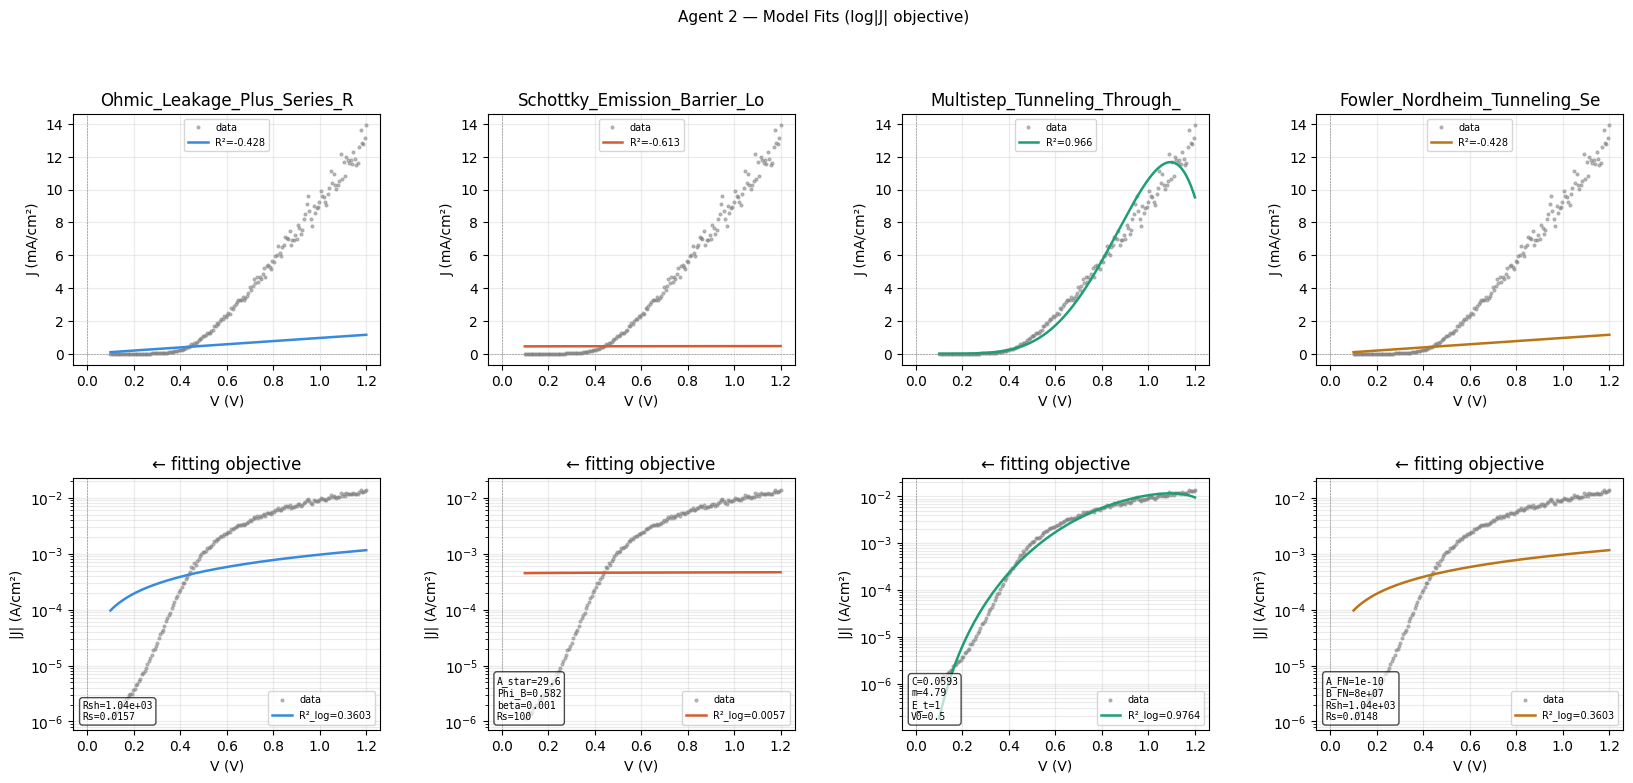

[A2] Plot saved: agent2_fits.png
[A2] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent2_output.json
[A2] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent2_fits.png

[A2] ✅ Done.
  Best model : Multistep_Tunneling_Through_Interface_States
  Best R²_log: 0.976355

────────────────────────────────────────
  Agent 3  (iteration 3)
────────────────────────────────────────
  AGENT 3  |  Judge & Validator
  Input   : agent2_output.json
[A3] Loaded 'agent2_output.json'  iter=3
[A3] Material : Data as is, Material is ZnO with Au contacts
[A3] Fits     : 4/4 successful
[A3] Best     : Multistep_Tunneling_Through_Interface_States  R²_log=0.976355

[A3] Judging: Multistep_Tunneling_Through_Interface_States
  Numerical: score=10  verdict=rejected
    ⚠ R²_log=0.976 below threshold 0.99
    ⚠ χ²_r=100.7 >> 1  (very poor fit)
    ⚠ systematic residual structure (too few sign changes)
    ⚠ residuals grow at high V — possible missing Rs
  [A3] LLM physics check: Multistep_Tunneling_Through_Interface_S

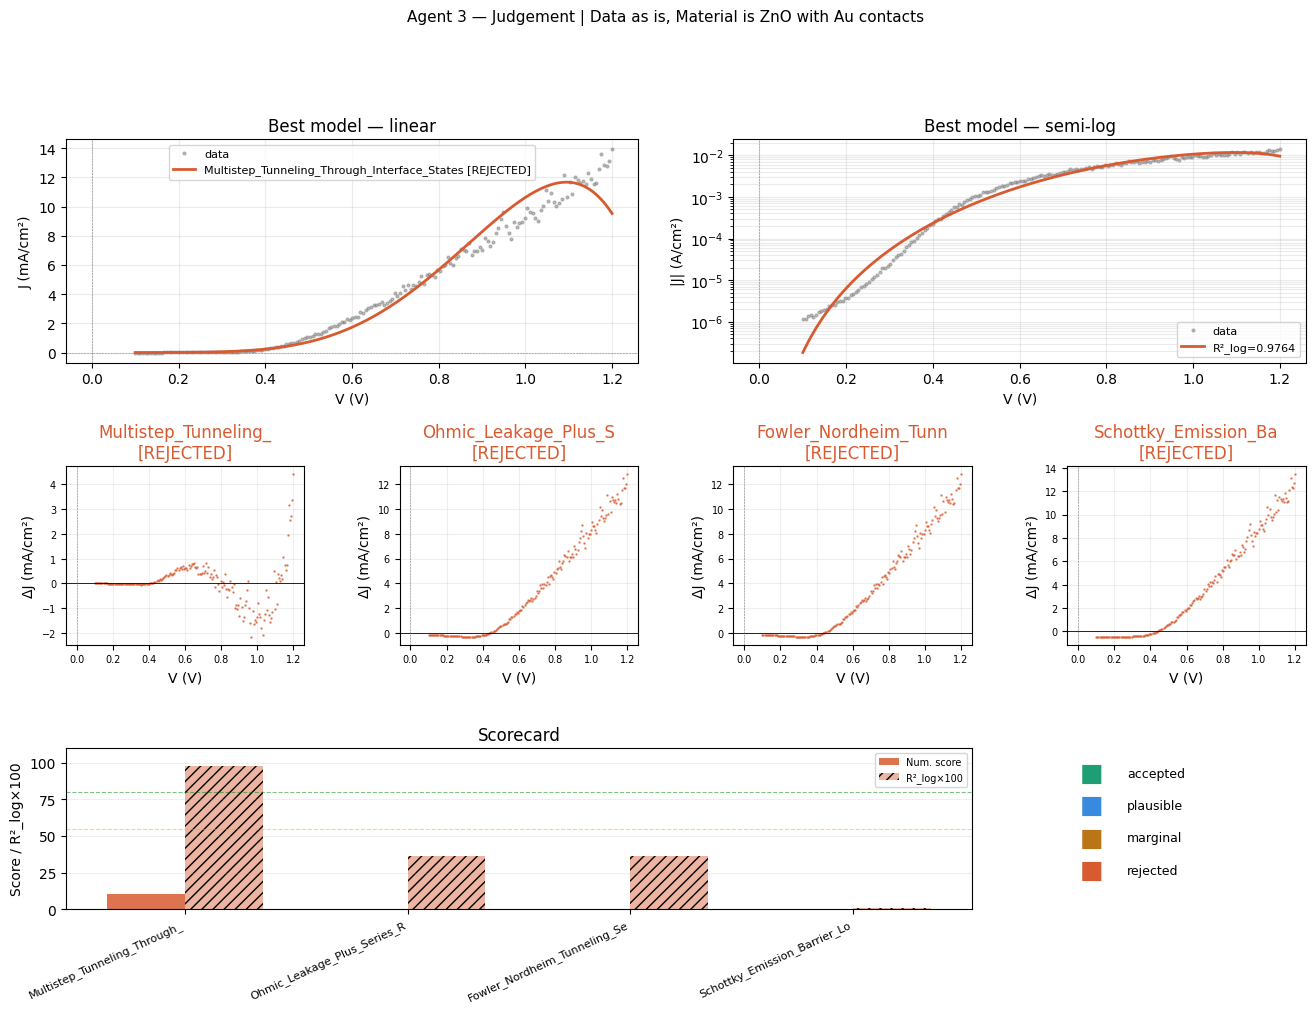

[A3] Plot saved: agent3_report.png
[A3] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent3_output.json
[A3] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent3_report.png
[A3] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/agent3_output_report.txt

[A3] ✅ Done.
  Best : Multistep_Tunneling_Through_Interface_States
  Verdict: rejected
  Orchestrator: TRIGGERED

[A4] Circuit-element diagnosis ...
  → Residuals grow 33.4× at high V → Rs≈0.1 Ω·cm².

██████████████████████████████████████████████████████████████
  ORCHESTRATOR  |  Iteration 3/3  |  ESCALATED
██████████████████████████████████████████████████████████████
  ⚠️  Max iterations reached. Best: {'iteration': 3, 'model': 'Multistep_Tunneling_Through_Interface_States', 'verdict': 'rejected', 'R2': 0.966002, 'R2_log': 0.976355, 'fit_params': {'C': 0.05932134191601784, 'm': 4.787452509405161, 'E_t': 0.999999999905, 'V0': 0.499999999951, 'Rs': 5.543612604041845}}

  AGENT IV — Final Pipeline Report
  Material   : Data as is, Material is ZnO 

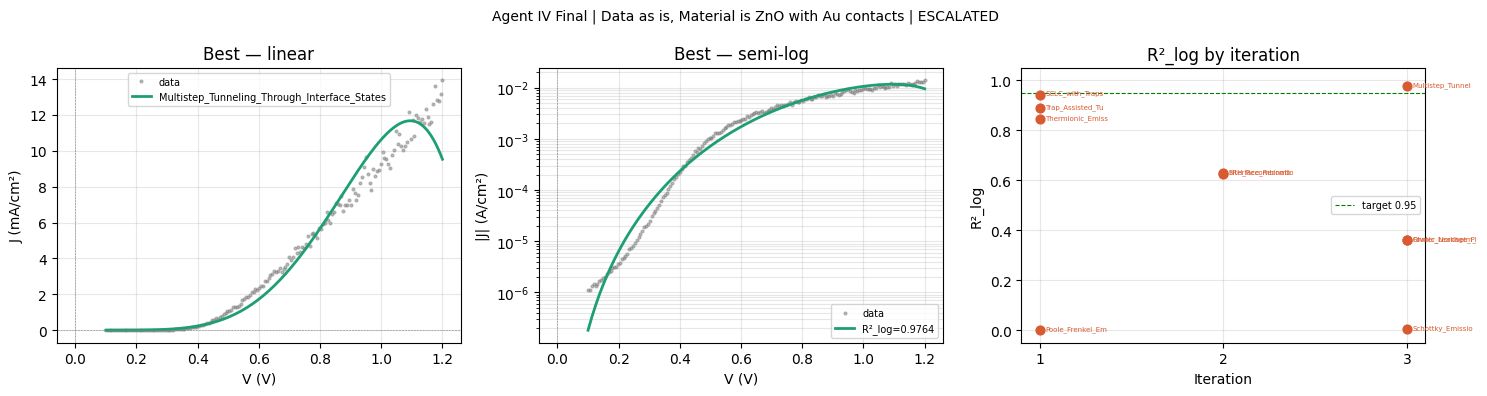

[A4] Final plot saved: pipeline_final_plot.png
[A4] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/pipeline_final.json
[A4] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/pipeline_final_report.txt
[A4] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/pipeline_final_plot.png
[A4] ✅ Updated SergeiVKalinin/IV_Agent/Analysis/orchestrator_state.json

[A4] ✅ Pipeline complete.
  Status    : ESCALATED
  Iterations: 3
  Best model: Multistep_Tunneling_Through_Interface_States
  R²_log    : 0.976355


In [33]:
final_state = run_orchestrator(
    csv_path        = "schottky_iv_dummy.csv",
    material_prompt = "Data as is, Material is ZnO with Au contacts",
    geometry        = {"area_cm2": 0.01, "thickness_nm": 200},
    n_hypotheses    = 4,
    max_iterations  = 3,
    resume          = False,
)

# Explainer

In [35]:
# ╔══════════════════════════════════════════════════════════════╗
#  META-ANALYSIS AGENT — Pipeline Audit & Validation
#  Runs independently from a fresh Colab.
#  Pulls all data from GitHub Analysis/ folder.
#  Saves outputs to GitHub Audit/ folder.
#
#  Prerequisites — run in a prior cell:
#  ─────────────────────────────────────
#  !pip install anthropic PyGithub networkx matplotlib numpy pandas
#
#  from google.colab import userdata
#  from github import Github
#  import anthropic
#
#  ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
#  MODEL             = "claude-sonnet-4-5"
#  GITHUB_TOKEN      = userdata.get('GitHub_Classic')
#  GITHUB_BRANCH     = "main"
#  gh   = Github(GITHUB_TOKEN)
#  repo = gh.get_repo("SergeiVKalinin/IV_Agent")
# ╚══════════════════════════════════════════════════════════════╝

import os, json, re, base64, textwrap
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import anthropic

try:
    import networkx as nx
    NX_AVAILABLE = True
except ImportError:
    NX_AVAILABLE = False
    print("[Meta] networkx not found — decision tree uses matplotlib fallback.")


# ═══════════════════════════════════════════════════════════════
#  CONFIGURATION
# ═══════════════════════════════════════════════════════════════

GITHUB_SOURCE_FOLDER = "Analysis"
GITHUB_AUDIT_FOLDER  = "Audit"
AUDIT_LOCAL_DIR      = "audit_outputs"

# Set to None if not using dummy data
GROUND_TRUTH_PARAMS = {
    "n"   : 1.5,
    "J0"  : 1e-8,
    "Rs"  : 50.0,
    "Rsh" : 10000.0,
}

REQUIRED_FILES = [
    "agent1_output.json",
    "agent2_output.json",
    "agent3_output.json",
    "orchestrator_state.json",
    "pipeline_final.json",
]

VERDICT_COLORS = {
    "accepted" : "#1D9E75",
    "plausible": "#378ADD",
    "marginal" : "#BA7517",
    "rejected" : "#D85A30",
    "success"  : "#1D9E75",
    "escalated": "#D85A30",
    None       : "#888780",
}


# ═══════════════════════════════════════════════════════════════
#  HELPER — legend handles using Line2D (avoids get_path() crash)
# ═══════════════════════════════════════════════════════════════

def _legend_handle(color, label):
    """Return a square Line2D proxy — safe legend handle for any axis."""
    return mlines.Line2D([], [], color=color, marker="s",
                         linestyle="none", markersize=10, label=label)


def _verdict_legend_handles():
    return [_legend_handle(c, v)
            for v, c in VERDICT_COLORS.items()
            if v not in (None, "success", "escalated")]


# ═══════════════════════════════════════════════════════════════
#  SECTION 1 — PULL FROM GITHUB
# ═══════════════════════════════════════════════════════════════

def meta_pull_json(filename, folder):
    rpath = f"{folder}/{filename}"
    try:
        obj     = repo.get_contents(rpath, ref=GITHUB_BRANCH)
        content = base64.b64decode(obj.content).decode("utf-8")
        data    = json.loads(content)
        print(f"[Meta] ✅ {rpath}  ({len(content):,} bytes)")
        return data
    except Exception as e:
        print(f"[Meta] ⚠️  {rpath}: {e}")
        return None


def meta_pull_all():
    print(f"\n[Meta] Pulling from {repo.full_name}/{GITHUB_SOURCE_FOLDER}/ ...")
    data = {}
    for fname in REQUIRED_FILES:
        key    = fname.replace(".json","").replace("_output","")
        pulled = meta_pull_json(fname, GITHUB_SOURCE_FOLDER)
        if pulled:
            data[key] = pulled

    # Pick up any extra files
    try:
        items = repo.get_contents(GITHUB_SOURCE_FOLDER, ref=GITHUB_BRANCH)
        for item in items:
            if item.name.endswith(".json") and item.name not in REQUIRED_FILES:
                key = item.name.replace(".json","")
                raw = base64.b64decode(item.content).decode("utf-8")
                data[key] = json.loads(raw)
                print(f"[Meta]    extra: {item.name}")
    except Exception as e:
        print(f"[Meta] ⚠️  folder scan: {e}")

    print(f"[Meta] Pulled {len(data)} files total.")
    return data


# ═══════════════════════════════════════════════════════════════
#  SECTION 2 — DECISION TREE
# ═══════════════════════════════════════════════════════════════

def meta_plot_decision_tree(state, output_path):
    vh = state.get("verdict_history", [])
    if not vh:
        print("[Meta] No verdict history — skipping decision tree.")
        return

    n_iter = len(vh)
    fig_h  = max(6, n_iter * 3.5)

    if NX_AVAILABLE:
        _decision_tree_nx(vh, state, output_path, fig_h)
    else:
        _decision_tree_mpl(vh, state, output_path, fig_h)


def _decision_tree_nx(vh, state, output_path, fig_h):
    G   = nx.DiGraph()
    pos = {}
    n_iter = len(vh)

    root = "START"
    G.add_node(root, label="START", verdict="root")
    pos[root] = (0, n_iter)
    prev_best = root

    for vi, v in enumerate(vh):
        y      = n_iter - vi - 1
        models = v["models"]
        n_m    = len(models)
        xs     = np.linspace(-n_m/2, n_m/2, n_m) if n_m > 1 else [0.0]
        best_name = v.get("best_model")

        for mi, m in enumerate(models):
            nid = f"i{v['iteration']}_{m['name'][:18]}"
            G.add_node(nid, label=m["name"][:20],
                       verdict=m.get("verdict","rejected"))
            pos[nid] = (xs[mi], y)
            G.add_edge(prev_best, nid,
                       best=(m["name"]==best_name),
                       verdict=m.get("verdict","rejected"))

        if best_name:
            prev_best = f"i{v['iteration']}_{best_name[:18]}"

    status   = state.get("status","unknown")
    terminal = f"END\n({status.upper()})"
    G.add_node(terminal, label=terminal, verdict=status)
    pos[terminal] = (0, -1)
    G.add_edge(prev_best, terminal, best=True, verdict=status)

    fig, ax = plt.subplots(figsize=(max(12, len(G.nodes)*1.2), fig_h))
    ax.set_title("Orchestrator Decision Tree", fontsize=12, fontweight="bold")
    ax.axis("off")

    node_colors = [VERDICT_COLORS.get(G.nodes[n].get("verdict"), "#888780")
                   for n in G.nodes]
    nx.draw_networkx(
        G, pos=pos, ax=ax,
        labels={n: G.nodes[n].get("label", n) for n in G.nodes},
        node_color=node_colors, node_size=2200,
        font_size=7, font_color="white", font_weight="bold",
        edge_color=["#1D9E75" if G.edges[e].get("best") else "#cccccc"
                    for e in G.edges],
        width=[2.5 if G.edges[e].get("best") else 0.8 for e in G.edges],
        arrows=True, arrowsize=15,
    )
    ax.legend(handles=_verdict_legend_handles(), loc="lower right", fontsize=8)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Meta] Decision tree saved: {output_path}")


def _decision_tree_mpl(vh, state, output_path, fig_h):
    n_iter = len(vh)
    fig, ax = plt.subplots(figsize=(14, fig_h))
    ax.set_xlim(-1, 1)
    ax.set_ylim(-0.5, n_iter + 0.5)
    ax.axis("off")
    ax.set_title("Orchestrator Decision Tree", fontsize=12, fontweight="bold")

    for vi, v in enumerate(vh):
        y      = n_iter - vi - 0.5
        models = v["models"]
        n_m    = len(models)
        xs     = np.linspace(-0.85, 0.85, n_m) if n_m > 1 else [0.0]
        ax.text(-0.95, y, f"Iter {v['iteration']}", fontsize=9,
                va="center", color="gray")
        for mi, m in enumerate(models):
            col   = VERDICT_COLORS.get(m.get("verdict"), "#888780")
            r2l   = m.get("R2_log")
            label = (f"{m['name'][:20]}\n[{m.get('verdict','?')}]\n"
                     f"R²_log={r2l:.3f}" if r2l else
                     f"{m['name'][:20]}\n[{m.get('verdict','?')}]")
            bbox = dict(boxstyle="round,pad=0.3", fc=col, ec="white",
                        alpha=0.85, lw=1.2)
            ax.text(xs[mi], y, label, ha="center", va="center",
                    fontsize=7, color="white", fontweight="bold", bbox=bbox)

    status = state.get("status","?")
    col    = VERDICT_COLORS.get("accepted" if status=="success" else "rejected","gray")
    ax.text(0, -0.2, f"OUTCOME: {status.upper()}",
            ha="center", fontsize=11, fontweight="bold", color=col)

    ax.legend(handles=_verdict_legend_handles(), loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Meta] Decision tree (fallback) saved: {output_path}")


# ═══════════════════════════════════════════════════════════════
#  SECTION 3 — REASONING CONSISTENCY AUDIT (LLM)
# ═══════════════════════════════════════════════════════════════

META_CONSISTENCY_SYSTEM = textwrap.dedent("""
    You are auditing the reasoning of an automated IV-curve analysis pipeline.

    Check:
      1. Did Agent 1 avoid mechanisms the Orchestrator said to avoid?
      2. Did Agent 1 follow circuit-element suggestions (add Rs, Rsh)?
      3. Was the Orchestrator's diagnosis consistent with the data statistics?
      4. Did R²_log improve across iterations?
      5. Were there logical contradictions in the reasoning chain?

    Return ONLY valid JSON:
    {
      "consistency_score": 0-100,
      "checks": [
        {"check","passed","evidence","severity"}
      ],
      "overall_assessment": "2-3 sentence summary",
      "recommendations": ["suggestion 1", ...]
    }
""")


def meta_audit_consistency(state, agent1_data):
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

    fb_hist = state.get("feedback_history", [])
    vh      = state.get("verdict_history", [])
    tried   = state.get("tried_mechanisms", [])

    hist_lines = []
    for i, v in enumerate(vh):
        fb = fb_hist[i] if i < len(fb_hist) else "(none)"
        hist_lines.append(
            f"\nIteration {v['iteration']}:\n"
            f"  Feedback sent:\n    {fb[:250]}\n"
            f"  Models generated:\n"
            + "\n".join(f"    - {m['name']} [{m.get('verdict','?')}]"
                        f"  R²_log={m.get('R2_log')}"
                        for m in v["models"])
        )

    hyp1 = [h.get("mechanism_name","") for h in agent1_data.get("hypotheses",[])]

    msg = textwrap.dedent(f"""
        PIPELINE: {state.get('material_prompt','?')}
        Iterations: {state.get('current_iteration','?')}
        Status    : {state.get('status','?')}
        All tried : {tried}

        HISTORY:
        {''.join(hist_lines)}

        INITIAL HYPOTHESES (iter 1): {hyp1}

        Audit consistency. Return ONLY the JSON.
    """).strip()

    print("[Meta] LLM consistency audit ...")
    resp = client.messages.create(
        model=MODEL, max_tokens=2048,
        system=META_CONSISTENCY_SYSTEM,
        messages=[{"role":"user","content":msg}],
    )
    raw = resp.content[0].text.strip()
    raw = re.sub(r"^```[a-z]*\s*","",raw,flags=re.IGNORECASE)
    raw = re.sub(r"\s*```$","",raw)
    try:
        result = json.loads(raw)
        print(f"[Meta] Consistency score: {result.get('consistency_score')}/100")
        for c in result.get("checks",[]):
            icon = "✓" if c.get("passed") else "✗"
            print(f"  {icon} [{c.get('severity','info').upper():7s}] {c.get('check','')}")
        return result
    except Exception as e:
        print(f"[Meta] ⚠️  Consistency parse error: {e}")
        return {"consistency_score":None,"checks":[],
                "overall_assessment":str(e),"recommendations":[]}


# ═══════════════════════════════════════════════════════════════
#  SECTION 4 — PARAMETER CONVERGENCE
# ═══════════════════════════════════════════════════════════════

def meta_plot_param_convergence(state, agent2_data, output_path):
    vh          = state.get("verdict_history",[])
    fit_results = agent2_data.get("fit_results",[])

    param_data = {}   # {pname: [(iter, model, value, error, verdict)]}
    for v in vh:
        it = v["iteration"]
        for m in v["models"]:
            fr = next((r for r in fit_results
                       if r["mechanism_name"]==m["name"]
                       and r.get("fit_params")), None)
            if not fr:
                continue
            for pname, pval in fr["fit_params"].items():
                perr = fr.get("param_errors",{}).get(pname, np.nan)
                param_data.setdefault(pname,[]).append(
                    (it, m["name"], pval, perr, m.get("verdict","rejected"))
                )

    if not param_data:
        print("[Meta] No parameter data for convergence plot.")
        return

    n_p  = len(param_data)
    cols = 2
    rows = max(1, (n_p + 1) // cols)
    fig, axes = plt.subplots(rows, cols,
                             figsize=(12, max(4, rows * 2.5)))
    axes = np.array(axes).flatten()
    fig.suptitle("Parameter Convergence Across Iterations", fontsize=11)

    for pi, (pname, entries) in enumerate(param_data.items()):
        ax = axes[pi]
        for (it, mname, val, err, verdict) in entries:
            col = VERDICT_COLORS.get(verdict,"gray")
            yerr = abs(err) if np.isfinite(err) else 0
            ax.errorbar(it, val, yerr=yerr, fmt="o", color=col,
                        ms=7, capsize=4)
            ax.annotate(mname[:12], (it, val),
                        textcoords="offset points", xytext=(5,3),
                        fontsize=6, color=col)
        if GROUND_TRUTH_PARAMS and pname in GROUND_TRUTH_PARAMS:
            gt = GROUND_TRUTH_PARAMS[pname]
            ax.axhline(gt, color="black", lw=1.2, ls="--",
                       label=f"true={gt:.3g}")
            ax.legend(fontsize=6)
        ax.set(xlabel="Iteration", ylabel=pname,
               title=f"Parameter: {pname}")
        ax.set_xticks(range(1, len(vh)+1))
        ax.grid(True, alpha=0.3)
        vals = [abs(e[2]) for e in entries if e[2] != 0]
        if vals and max(vals)/min(vals) > 1000:
            ax.set_yscale("log")

    for ax in axes[n_p:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Meta] Parameter convergence saved: {output_path}")


# ═══════════════════════════════════════════════════════════════
#  SECTION 5 — RESIDUAL FINGERPRINTS
# ═══════════════════════════════════════════════════════════════

def meta_plot_residuals(agent2_data, state, output_path):
    nd = agent2_data.get("normalized_data",{})
    V  = np.array(nd.get("V_V",[]))
    if len(V)==0:
        print("[Meta] No V data for residual plot.")
        return

    fit_results = agent2_data.get("fit_results",[])
    vh          = state.get("verdict_history",[])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Residual Fingerprints — All Models All Iterations",
                 fontsize=11)
    ax_lin, ax_log = axes

    plotted = 0
    for v in vh:
        it = v["iteration"]
        for m in v["models"]:
            fr = next((r for r in fit_results
                       if r["mechanism_name"]==m["name"]
                       and r.get("residuals")), None)
            if not fr:
                continue
            res   = np.array([x if x is not None else np.nan
                               for x in fr["residuals"]])
            col   = VERDICT_COLORS.get(m.get("verdict"),"gray")
            alpha = 0.7 if m.get("verdict") in ("accepted","plausible") else 0.35
            lw    = 1.8 if m.get("verdict") in ("accepted","plausible") else 0.8
            label = f"[i{it}] {m['name'][:20]}"

            ax_lin.plot(V, res*1e3, "-", lw=lw, color=col,
                        alpha=alpha, label=label)
            ax_log.plot(V, np.abs(res), "-", lw=lw, color=col,
                        alpha=alpha, label=label)
            plotted += 1

    ax_lin.axhline(0, color="black", lw=0.8)
    ax_lin.axvline(0, color="gray",  lw=0.4, ls="--")
    ax_lin.set(xlabel="V (V)", ylabel="ΔJ (mA/cm²)", title="Linear residuals")
    ax_lin.grid(True, alpha=0.25)
    if plotted <= 8:
        ax_lin.legend(fontsize=6)

    ax_log.set_yscale("log")
    ax_log.axvline(0, color="gray", lw=0.4, ls="--")
    ax_log.set(xlabel="V (V)", ylabel="|ΔJ| (A/cm²)", title="Log |residuals|")
    ax_log.grid(True, alpha=0.25, which="both")
    ax_log.legend(handles=_verdict_legend_handles(),
                  loc="lower right", fontsize=7)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Meta] Residual fingerprints saved: {output_path}")


# ═══════════════════════════════════════════════════════════════
#  SECTION 6 — PHYSICS SCORECARD
# ═══════════════════════════════════════════════════════════════

def meta_plot_physics_scorecard(agent3_data, output_path):
    judgements = agent3_data.get("judgements",[])
    if not judgements:
        print("[Meta] No judgements for scorecard.")
        return

    color_map = {
        "reasonable"   : "#1D9E75",
        "borderline"   : "#BA7517",
        "unreasonable" : "#D85A30",
        "unknown"      : "#888780",
    }

    all_params   = []
    model_names  = []
    cell_data    = {}

    for j in judgements:
        mname = j["mechanism_name"]
        if mname not in model_names:
            model_names.append(mname)
        for pc in j.get("parameter_checks",[]):
            pname = pc.get("param_name","?")
            if pname not in all_params:
                all_params.append(pname)
            cell_data[(mname,pname)] = {
                "assessment": pc.get("value_assessment","unknown"),
                "value"     : pc.get("fitted_value"),
                "expected"  : pc.get("expected_range",""),
            }

    if not all_params:
        print("[Meta] No parameter checks in Agent 3 output.")
        return

    n_rows = len(all_params)
    n_cols = len(model_names)
    fig, ax = plt.subplots(figsize=(max(8, n_cols*2.5),
                                    max(4, n_rows*0.7+2)))
    ax.set_title("Physics Parameter Scorecard", fontsize=12, fontweight="bold")
    ax.set_xlim(0, n_cols)
    ax.set_ylim(0, n_rows)
    ax.axis("off")

    for ri, pname in enumerate(reversed(all_params)):
        for ci, mname in enumerate(model_names):
            cd    = cell_data.get((mname,pname),{})
            assmt = cd.get("assessment","unknown")
            val   = cd.get("value")
            col   = color_map.get(assmt,"#888780")

            rect = mpatches.FancyBboxPatch(
                (ci + 0.05, ri + 0.05), 0.90, 0.90,
                boxstyle="round,pad=0.05",
                fc=col, ec="white", lw=1, alpha=0.85
            )
            ax.add_patch(rect)

            def _fmt(v):
                try:    return f"{float(v):.2e}"
                except: return str(v) if v is not None else "—"

            ax.text(ci+0.5, ri+0.60, _fmt(val),
                    ha="center", va="center",
                    fontsize=7, color="white", fontweight="bold")
            ax.text(ci+0.5, ri+0.22, assmt[:12],
                    ha="center", va="center",
                    fontsize=6, color="white")

    for ci, mname in enumerate(model_names):
        ax.text(ci+0.5, n_rows+0.1, mname[:22],
                ha="center", va="bottom", fontsize=7,
                fontweight="bold", rotation=30)

    for ri, pname in enumerate(reversed(all_params)):
        ax.text(-0.05, ri+0.5, pname,
                ha="right", va="center", fontsize=8, fontweight="bold")

    # Legend — Line2D proxies, no FancyBboxPatch in legend
    legend_handles = [
        _legend_handle(col, assmt)
        for assmt, col in color_map.items()
        if assmt != "unknown"
    ]
    ax.legend(handles=legend_handles, loc="lower right",
              fontsize=8, framealpha=0.9)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Meta] Physics scorecard saved: {output_path}")


# ═══════════════════════════════════════════════════════════════
#  SECTION 7 — GROUND TRUTH COMPARISON
# ═══════════════════════════════════════════════════════════════

def meta_plot_ground_truth(state, agent2_data, ground_truth, output_path):
    if not ground_truth:
        print("[Meta] No ground truth — skipping.")
        return

    fit_results = agent2_data.get("fit_results",[])
    best_model  = state.get("best_result",{}).get("model")
    best_fr     = next((r for r in fit_results
                        if r["mechanism_name"]==best_model
                        and r.get("fit_params")), None)
    if not best_fr:
        print("[Meta] No best model fit for ground truth comparison.")
        return

    fitted = best_fr["fit_params"]
    errors = best_fr.get("param_errors",{})
    common = [p for p in ground_truth if p in fitted]
    if not common:
        print("[Meta] No common parameters between ground truth and fitted.")
        return

    fig, axes = plt.subplots(1, len(common),
                              figsize=(max(6, len(common)*3), 5))
    if len(common)==1: axes = [axes]
    fig.suptitle(f"Ground Truth vs Fitted — {best_model}",
                 fontsize=11, fontweight="bold")

    print("\n── Ground truth recovery ───────────────────────────────")
    print(f"  {'Param':<12}  {'True':>12}  {'Fitted':>12}  "
          f"{'±Error':>12}  {'Rel.err':>9}")
    print("  " + "-"*62)

    for ax, pname in zip(axes, common):
        gt_v  = ground_truth[pname]
        ft_v  = fitted[pname]
        fe_v  = errors.get(pname, np.nan)
        rel   = abs(ft_v-gt_v)/abs(gt_v)*100 if gt_v!=0 else np.nan

        bars = ax.bar(["True","Fitted"], [abs(gt_v), abs(ft_v)],
                      color=["#378ADD","#1D9E75"], alpha=0.8, width=0.5)
        ax.errorbar(1, abs(ft_v), yerr=abs(fe_v) if np.isfinite(fe_v) else 0,
                    fmt="none", color="black", capsize=6, lw=2)

        if abs(gt_v)>0 and abs(ft_v)>0:
            ratio = max(abs(gt_v),abs(ft_v))/min(abs(gt_v),abs(ft_v))
            if ratio > 10:
                ax.set_yscale("log")

        title = (f"{pname}\nError: {rel:.1f}%"
                 if not np.isnan(rel) else pname)
        ax.set_title(title, fontsize=9)
        ax.set_ylabel("Value (absolute)", fontsize=8)
        ax.grid(True, alpha=0.3, axis="y")

        for bar, val in zip(bars, [gt_v, ft_v]):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()*1.05,
                    f"{val:.3g}", ha="center", va="bottom", fontsize=8)

        print(f"  {pname:<12}  {gt_v:>12.4e}  {ft_v:>12.4e}  "
              f"{fe_v:>12.2e}  {rel:>8.1f}%")

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Meta] Ground truth comparison saved: {output_path}")


# ═══════════════════════════════════════════════════════════════
#  SECTION 8 — EFFICIENCY METRICS
# ═══════════════════════════════════════════════════════════════

def meta_plot_efficiency(state, output_path):
    vh = state.get("verdict_history",[])
    if not vh:
        return

    iterations  = [v["iteration"] for v in vh]
    best_r2logs = [v.get("best_R2_log") or 0 for v in vh]
    n_models    = [len(v["models"]) for v in vh]

    vc = {"accepted":0,"plausible":0,"marginal":0,"rejected":0}
    for v in vh:
        for m in v["models"]:
            verd = m.get("verdict","rejected")
            if verd in vc: vc[verd] += 1

    fig, axes = plt.subplots(1, 3, figsize=(14,4))
    fig.suptitle("Pipeline Efficiency Metrics", fontsize=11)

    # R²_log progression
    ax = axes[0]
    ax.plot(iterations, best_r2logs, "o-", color="#378ADD", lw=2, ms=8)
    ax.axhline(0.99, color="#1D9E75", lw=1, ls="--", label="target 0.99")
    ax.set(xlabel="Iteration", ylabel="Best R²_log",
           title="R²_log Progression", ylim=(-0.05,1.05))
    ax.set_xticks(iterations)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    for i, r in zip(iterations, best_r2logs):
        ax.annotate(f"{r:.3f}",(i,r),
                    textcoords="offset points",xytext=(0,8),
                    ha="center",fontsize=8)

    # Models per iteration
    ax = axes[1]
    ax.bar(iterations, n_models, color="#7F77DD", alpha=0.8, width=0.5)
    ax.set(xlabel="Iteration", ylabel="# Models",
           title="Models per Iteration")
    ax.set_xticks(iterations)
    ax.grid(True, alpha=0.3, axis="y")
    for i, n in zip(iterations, n_models):
        ax.text(i, n+0.05, str(n), ha="center", fontsize=9)

    # Verdict pie
    ax = axes[2]
    labels  = [v for v,c in vc.items() if c>0]
    sizes   = [c for c in vc.values() if c>0]
    colors  = [VERDICT_COLORS.get(v,"gray") for v in labels]
    ax.pie(sizes, labels=labels, colors=colors, autopct="%1.0f%%",
           startangle=90, textprops={"fontsize":9})
    ax.set_title("Verdict Distribution\n(all iterations)")

    total = sum(vc.values())
    print(f"\n── Efficiency ──────────────────────────────────────────")
    print(f"  Iterations  : {len(vh)}")
    print(f"  Total models: {total}")
    print(f"  Per iter    : {total/len(vh):.1f}")
    print(f"  Status      : {state.get('status','?').upper()}")
    print(f"  Verdicts    : {vc}")

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Meta] Efficiency metrics saved: {output_path}")


# ═══════════════════════════════════════════════════════════════
#  SECTION 9 — COUNTERFACTUAL + NARRATIVE (LLM)
# ═══════════════════════════════════════════════════════════════

META_COUNTERFACTUAL_SYSTEM = textwrap.dedent("""
    You are a senior semiconductor physicist reviewing an automated IV-curve
    analysis pipeline output.

    Answer two questions:

    Q1 — COUNTERFACTUAL: What mechanism would an expert have tried first?
    Would they reach the same conclusion? If not, what did the pipeline miss?

    Q2 — NARRATIVE: Write a 4-6 sentence methods-section paragraph describing
    what the pipeline did, what it found, and whether the result is credible.

    Return ONLY valid JSON:
    {
      "expert_first_choice"    : "mechanism name",
      "expert_reasoning"       : "2-3 sentences",
      "pipeline_vs_expert"     : "agreed|diverged|partially",
      "divergence_explanation" : "if diverged, explain",
      "methods_narrative"      : "4-6 sentence paragraph",
      "confidence_in_result"   : "high|medium|low",
      "recommended_follow_up"  : ["experiment 1", ...]
    }
""")


def meta_counterfactual(state, agent3_data):
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

    iv     = agent3_data.get("iv_stats",{})
    jdgs   = agent3_data.get("judgements",[])
    best   = state.get("best_result",{})

    models_str = "\n".join(
        f"  [{j['final_verdict'].upper():8s}] {j['mechanism_name']}  "
        f"R²={j.get('R2')}  R²_log={j.get('R2_log')}  "
        f"physical={j.get('physical_verdict')}"
        for j in jdgs
    )
    params_str = "\n".join(f"  {k}={v:.4e}"
                           for k,v in best.get("fit_params",{}).items())

    def f(v): return str(v) if v is not None else "N/A"

    msg = textwrap.dedent(f"""
        MATERIAL: {state.get('material_prompt','?')}
        IV STATS:
          Rectification: {f(iv.get('rectification'))}
          Rsh estimate : {f(iv.get('Rsh_estimate_ohm'))} Ω·cm²
          Ideality n   : {f(iv.get('n_ideality_est'))}
          J(V=0)       : {f(iv.get('J_at_0V'))} A/cm²

        ALL MODELS TRIED:
        {models_str}

        WINNING MODEL : {best.get('model','none')}
        Verdict       : {best.get('verdict','none')}
        R²_log        : {best.get('R2_log')}
        Parameters    :
        {params_str}

        GROUND TRUTH (dummy):
        {json.dumps(GROUND_TRUTH_PARAMS, indent=2) if GROUND_TRUTH_PARAMS else 'unknown'}

        Return ONLY the JSON.
    """).strip()

    print("[Meta] LLM counterfactual analysis ...")
    resp = client.messages.create(
        model=MODEL, max_tokens=1500,
        system=META_COUNTERFACTUAL_SYSTEM,
        messages=[{"role":"user","content":msg}],
    )
    raw = resp.content[0].text.strip()
    raw = re.sub(r"^```[a-z]*\s*","",raw,flags=re.IGNORECASE)
    raw = re.sub(r"\s*```$","",raw)
    try:
        result = json.loads(raw)
        print(f"[Meta] Expert first choice : {result.get('expert_first_choice')}")
        print(f"[Meta] Pipeline vs expert  : {result.get('pipeline_vs_expert')}")
        print(f"[Meta] Confidence          : {result.get('confidence_in_result')}")
        return result
    except Exception as e:
        print(f"[Meta] ⚠️  Counterfactual parse error: {e}")
        return {"methods_narrative": raw, "expert_first_choice": "unknown"}


# ═══════════════════════════════════════════════════════════════
#  SECTION 10 — AUDIT REPORT TEXT
# ═══════════════════════════════════════════════════════════════

def meta_build_report(state, consistency, counterfactual, output_path):
    best = state.get("best_result",{})
    lines = [
        "="*68,
        "  AGENT IV — Meta-Analysis Audit Report",
        f"  Material   : {state.get('material_prompt','?')}",
        f"  Timestamp  : {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')}",
        f"  Status     : {state.get('status','?').upper()}",
        f"  Iterations : {state.get('current_iteration','?')}",
        "="*68, "",
        "WINNING MODEL", "-"*50,
        f"  Model   : {best.get('model','none')}",
        f"  Verdict : {best.get('verdict','none')}",
        f"  R²      : {best.get('R2')}",
        f"  R²_log  : {best.get('R2_log')}",
        "",
        "REASONING CONSISTENCY AUDIT", "-"*50,
        f"  Score: {consistency.get('consistency_score')}/100",
        f"  {consistency.get('overall_assessment','')}",
        "",
    ]
    for c in consistency.get("checks",[]):
        icon = "✓" if c.get("passed") else "✗"
        lines.append(f"  {icon} [{c.get('severity','info').upper():7s}] "
                     f"{c.get('check','')}")
        if not c.get("passed"):
            lines.append(f"          {c.get('evidence','')[:100]}")

    lines += [
        "", "EXPERT COUNTERFACTUAL", "-"*50,
        f"  Expert first choice : {counterfactual.get('expert_first_choice')}",
        f"  Pipeline vs expert  : {counterfactual.get('pipeline_vs_expert')}",
        f"  Confidence          : {counterfactual.get('confidence_in_result')}",
        f"  {counterfactual.get('divergence_explanation','')}",
        "", "METHODS NARRATIVE", "-"*50,
        f"  {counterfactual.get('methods_narrative','')}",
        "", "FOLLOW-UP EXPERIMENTS", "-"*50,
    ]
    for exp in counterfactual.get("recommended_follow_up",[]):
        lines.append(f"  • {exp}")

    if consistency.get("recommendations"):
        lines += ["", "PIPELINE IMPROVEMENTS", "-"*50]
        for rec in consistency["recommendations"]:
            lines.append(f"  • {rec}")

    lines += ["", "="*68]
    report = "\n".join(lines)
    print(report)
    with open(output_path,"w") as f: f.write(report)
    print(f"\n[Meta] Audit report saved: {output_path}")
    return report


# ═══════════════════════════════════════════════════════════════
#  SECTION 11 — PUSH TO GITHUB Audit/
# ═══════════════════════════════════════════════════════════════

def meta_push(local_path):
    try:
        fname   = os.path.basename(local_path)
        rpath   = f"{GITHUB_AUDIT_FOLDER}/{fname}"
        content = open(local_path,"rb").read()
        msg     = (f"Meta-analysis | "
                   f"{datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M')} UTC")
        try:
            ex = repo.get_contents(rpath, ref=GITHUB_BRANCH)
            repo.update_file(rpath,msg,content,ex.sha,branch=GITHUB_BRANCH)
            print(f"[Meta] ✅ Updated  {repo.full_name}/{rpath}")
        except Exception:
            repo.create_file(rpath,msg,content,branch=GITHUB_BRANCH)
            print(f"[Meta] ✅ Created  {repo.full_name}/{rpath}")
    except Exception as e:
        print(f"[Meta] ⚠️  GitHub push failed '{local_path}': {e}")


# ═══════════════════════════════════════════════════════════════
#  SECTION 12 — MAIN
# ═══════════════════════════════════════════════════════════════

def run_meta_analysis(
    ground_truth   = GROUND_TRUTH_PARAMS,
    source_folder  = GITHUB_SOURCE_FOLDER,
    audit_folder   = GITHUB_AUDIT_FOLDER,
    local_dir      = AUDIT_LOCAL_DIR,
):
    os.makedirs(local_dir, exist_ok=True)

    print("="*62)
    print("  META-ANALYSIS AGENT  |  Pipeline Audit")
    print(f"  Source : {repo.full_name}/{source_folder}/")
    print(f"  Output : {repo.full_name}/{audit_folder}/")
    print("="*62)

    # 1. Pull data
    data        = meta_pull_all()
    agent1_data = data.get("agent1",{})
    agent2_data = data.get("agent2",{})
    agent3_data = data.get("agent3",{})
    state       = data.get("orchestrator_state",{})
    final_data  = data.get("pipeline_final",{})
    if not state and final_data:
        state = final_data
        print("[Meta] Using pipeline_final.json as state fallback.")

    results = {}
    p = lambda name: os.path.join(local_dir, name)

    # 2. Decision tree
    if state.get("verdict_history"):
        meta_plot_decision_tree(state, p("audit_decision_tree.png"))
        results["decision_tree"] = p("audit_decision_tree.png")
    else:
        print("[Meta] Skipping decision tree.")

    # 3. Consistency audit
    consistency = {}
    if state and agent1_data:
        consistency = meta_audit_consistency(state, agent1_data)
        results["consistency"] = consistency
    else:
        print("[Meta] Skipping consistency audit.")

    # 4. Parameter convergence
    if state.get("verdict_history") and agent2_data:
        meta_plot_param_convergence(state, agent2_data,
                                    p("audit_param_convergence.png"))
        results["param_convergence"] = p("audit_param_convergence.png")
    else:
        print("[Meta] Skipping parameter convergence.")

    # 5. Residual fingerprints
    if agent2_data and state:
        meta_plot_residuals(agent2_data, state, p("audit_residuals.png"))
        results["residuals"] = p("audit_residuals.png")
    else:
        print("[Meta] Skipping residual fingerprints.")

    # 6. Physics scorecard
    if agent3_data:
        meta_plot_physics_scorecard(agent3_data, p("audit_physics_scorecard.png"))
        results["physics_scorecard"] = p("audit_physics_scorecard.png")
    else:
        print("[Meta] Skipping physics scorecard.")

    # 7. Ground truth
    if ground_truth and agent2_data and state:
        meta_plot_ground_truth(state, agent2_data, ground_truth,
                               p("audit_ground_truth.png"))
        results["ground_truth"] = p("audit_ground_truth.png")
    else:
        print("[Meta] Skipping ground truth comparison.")

    # 8. Efficiency metrics
    if state.get("verdict_history"):
        meta_plot_efficiency(state, p("audit_efficiency.png"))
        results["efficiency"] = p("audit_efficiency.png")
    else:
        print("[Meta] Skipping efficiency metrics.")

    # 9. Counterfactual + narrative
    counterfactual = {}
    if state and agent3_data:
        counterfactual = meta_counterfactual(state, agent3_data)
        results["counterfactual"] = counterfactual
    else:
        print("[Meta] Skipping counterfactual.")

    # 10. Audit report
    if state:
        meta_build_report(state, consistency, counterfactual,
                          p("audit_report.txt"))
        results["report"] = p("audit_report.txt")
    else:
        print("[Meta] Skipping audit report.")

    # 11. Save summary JSON
    summary = {
        "timestamp"      : datetime.now(timezone.utc).isoformat(),
        "source_repo"    : repo.full_name,
        "source_folder"  : source_folder,
        "material_prompt": state.get("material_prompt","unknown"),
        "pipeline_status": state.get("status","unknown"),
        "consistency"    : consistency,
        "counterfactual" : counterfactual,
        "ground_truth"   : ground_truth,
        "analyses_run"   : [k for k in results if not k.endswith(".png")
                            and isinstance(results[k], str)],
    }
    path_json = p("audit_summary.json")
    with open(path_json,"w") as f:
        json.dump(summary, f, indent=2, default=str)
    results["summary_json"] = path_json

    # 12. Push to GitHub Audit/
    print(f"\n[Meta] Pushing {len(results)} outputs to "
          f"{repo.full_name}/{audit_folder}/ ...")
    for key, fpath in results.items():
        if isinstance(fpath, str) and os.path.exists(fpath):
            meta_push(fpath)

    print(f"\n[Meta] ✅ Meta-analysis complete.")
    print(f"  Analyses : {list(results.keys())}")
    print(f"  GitHub   : {repo.full_name}/{audit_folder}/")
    return results


print("✅ Meta-analysis agent loaded  (run_meta_analysis ready)")

✅ Meta-analysis agent loaded  (run_meta_analysis ready)


  META-ANALYSIS AGENT  |  Pipeline Audit
  Source : SergeiVKalinin/IV_Agent/Analysis/
  Output : SergeiVKalinin/IV_Agent/Audit/

[Meta] Pulling from SergeiVKalinin/IV_Agent/Analysis/ ...
[Meta] ✅ Analysis/agent1_output.json  (39,478 bytes)
[Meta] ✅ Analysis/agent2_output.json  (85,125 bytes)
[Meta] ✅ Analysis/agent3_output.json  (29,288 bytes)
[Meta] ✅ Analysis/orchestrator_state.json  (10,197 bytes)
[Meta] ✅ Analysis/pipeline_final.json  (33,826 bytes)
[Meta] Pulled 5 files total.


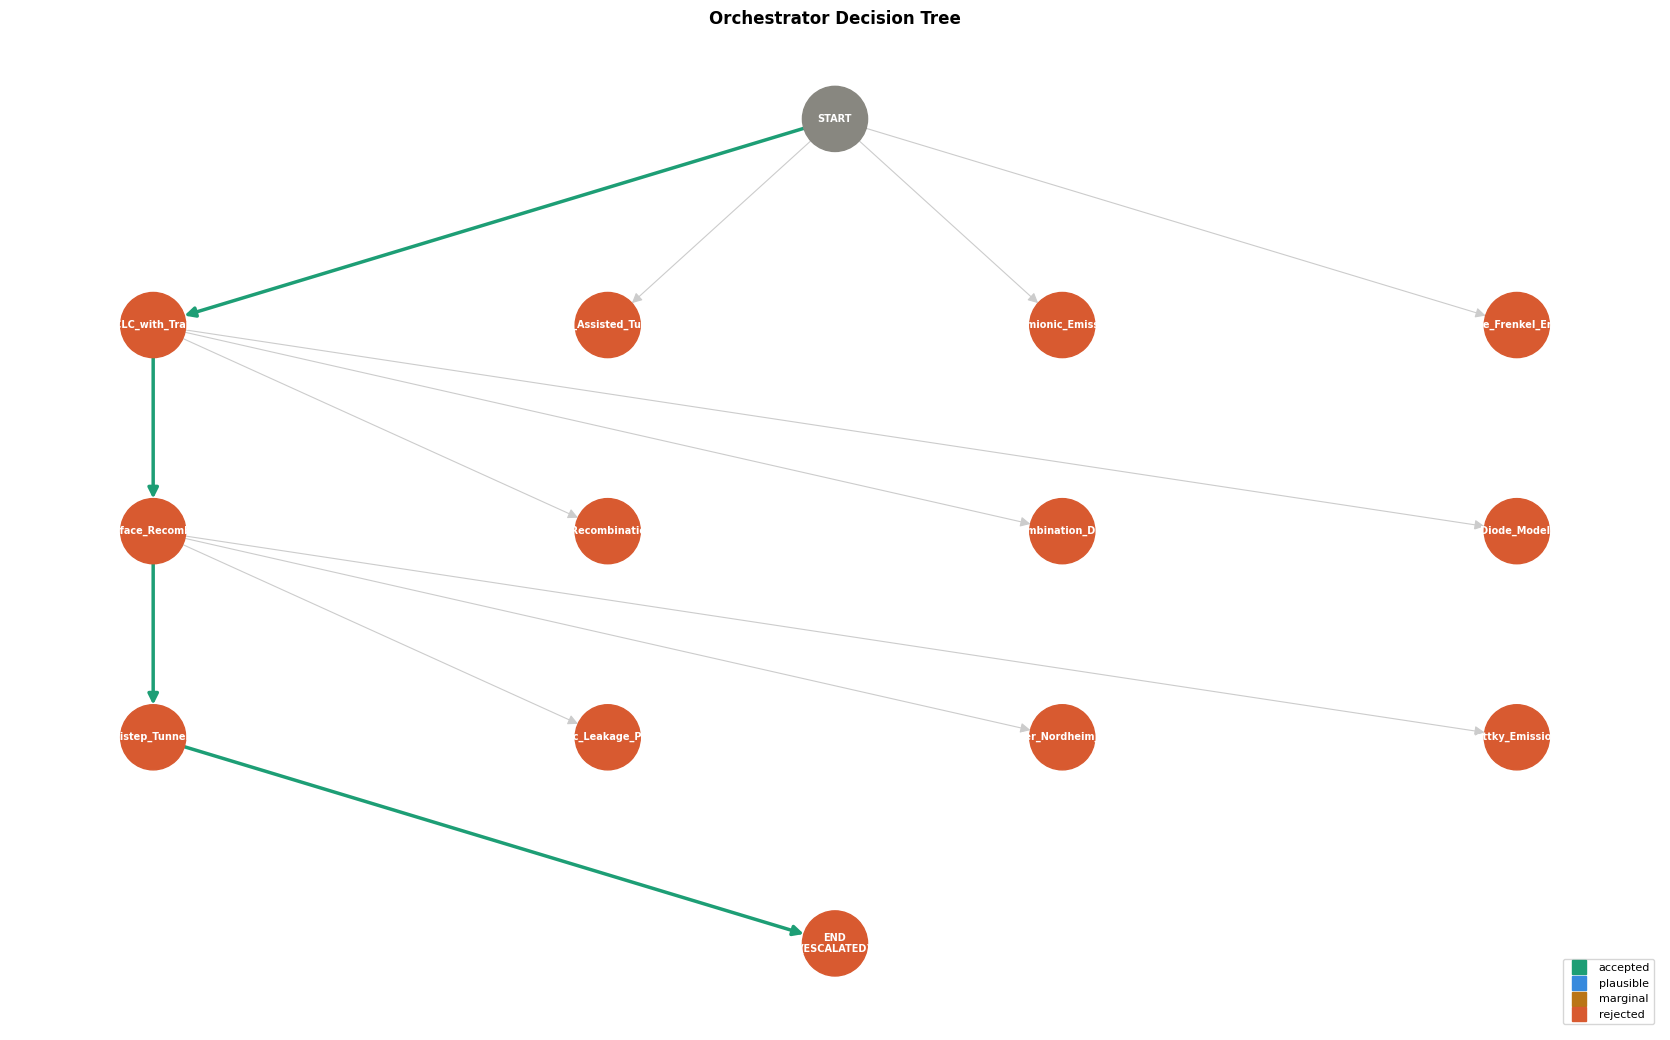

[Meta] Decision tree saved: audit_outputs/audit_decision_tree.png
[Meta] LLM consistency audit ...
[Meta] Consistency score: 35/100
  ✗ [CRITICAL] Agent 1 avoided Orchestrator-rejected mechanisms
  ✓ [LOW    ] Agent 1 followed circuit-element suggestions
  ✗ [HIGH   ] Orchestrator diagnosis consistent with data statistics
  ✗ [HIGH   ] R²_log improvement across iterations
  ✗ [CRITICAL] Logical contradictions in reasoning chain


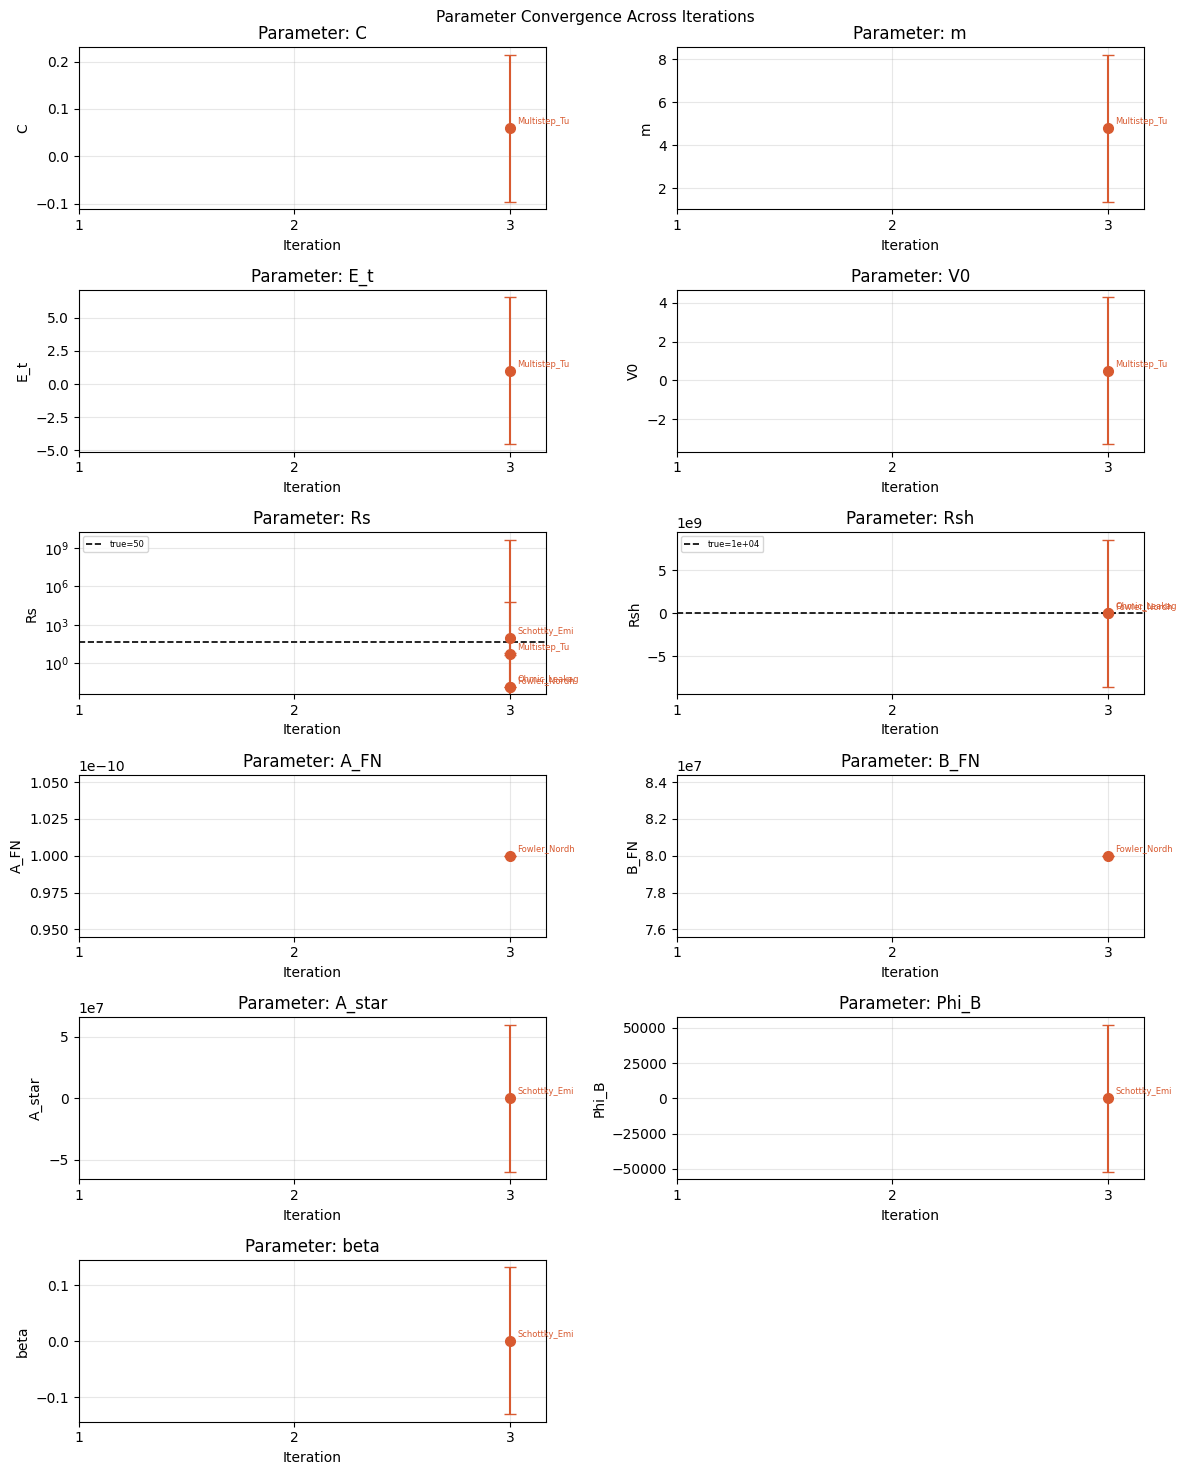

[Meta] Parameter convergence saved: audit_outputs/audit_param_convergence.png


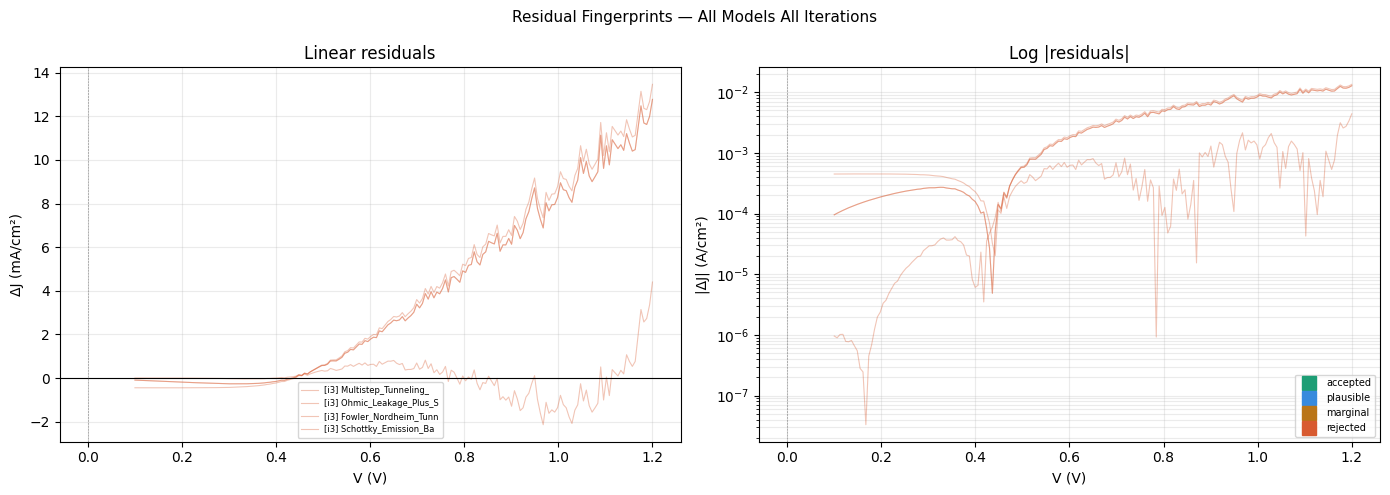

[Meta] Residual fingerprints saved: audit_outputs/audit_residuals.png


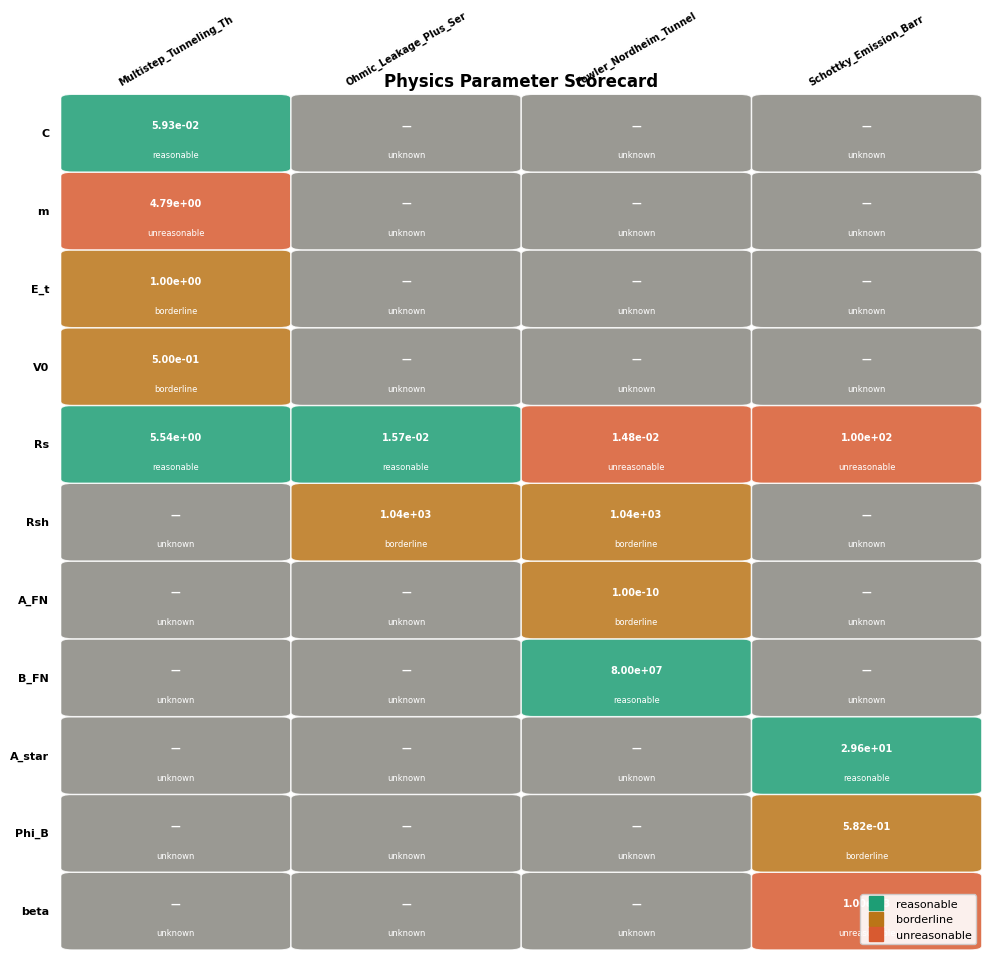

[Meta] Physics scorecard saved: audit_outputs/audit_physics_scorecard.png

── Ground truth recovery ───────────────────────────────
  Param                 True        Fitted        ±Error    Rel.err
  --------------------------------------------------------------
  Rs              5.0000e+01    5.5436e+00      1.00e+00      88.9%


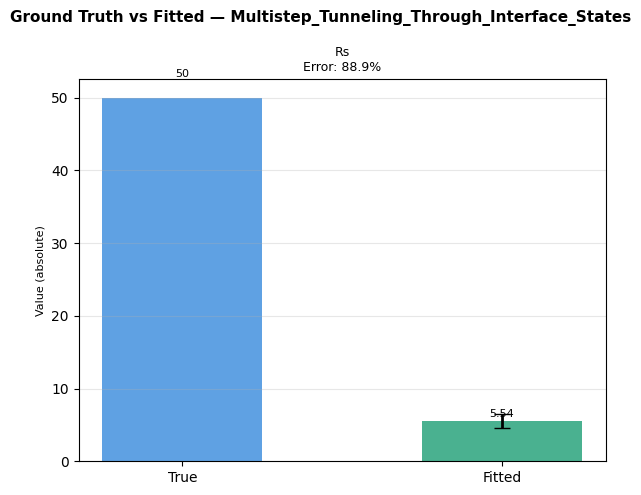

[Meta] Ground truth comparison saved: audit_outputs/audit_ground_truth.png

── Efficiency ──────────────────────────────────────────
  Iterations  : 3
  Total models: 12
  Per iter    : 4.0
  Status      : ESCALATED
  Verdicts    : {'accepted': 0, 'plausible': 0, 'marginal': 0, 'rejected': 12}


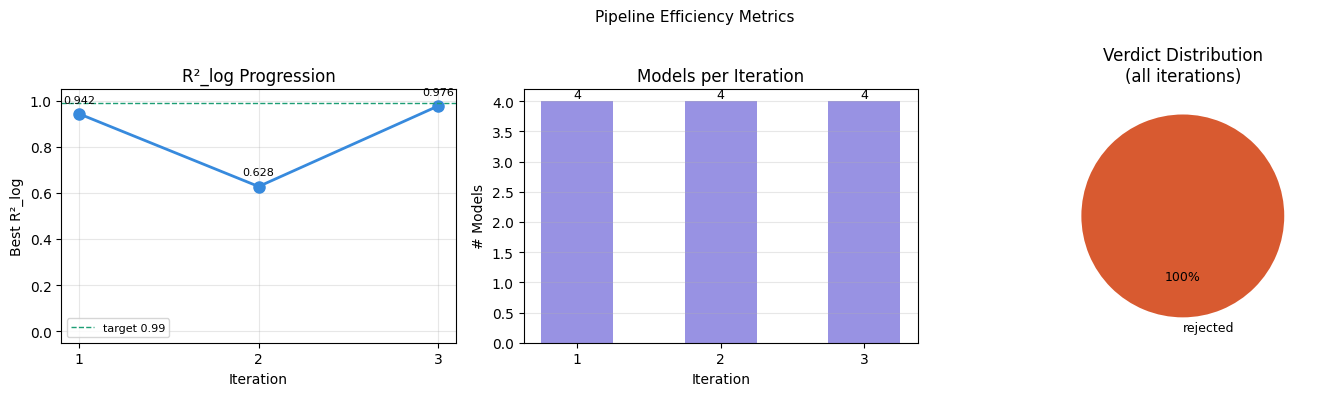

[Meta] Efficiency metrics saved: audit_outputs/audit_efficiency.png
[Meta] LLM counterfactual analysis ...
[Meta] Expert first choice : Schottky_diode_with_high_ideality_factor
[Meta] Pipeline vs expert  : diverged
[Meta] Confidence          : low
  AGENT IV — Meta-Analysis Audit Report
  Material   : Data as is, Material is ZnO with Au contacts
  Timestamp  : 2026-05-08 21:37 UTC
  Status     : ESCALATED
  Iterations : 3

WINNING MODEL
--------------------------------------------------
  Model   : Multistep_Tunneling_Through_Interface_States
  Verdict : rejected
  R²      : 0.966002
  R²_log  : 0.976355

REASONING CONSISTENCY AUDIT
--------------------------------------------------
  Score: 35/100
  The pipeline exhibits severe logical inconsistencies. The Orchestrator demanded recombination-dominated mechanisms in iteration 1 while simultaneously listing Ohmic and tunneling models as initial hypotheses. Agent 1 ignored the recombination directive in iteration 1, generating rejected b

In [36]:
audit_results = run_meta_analysis()

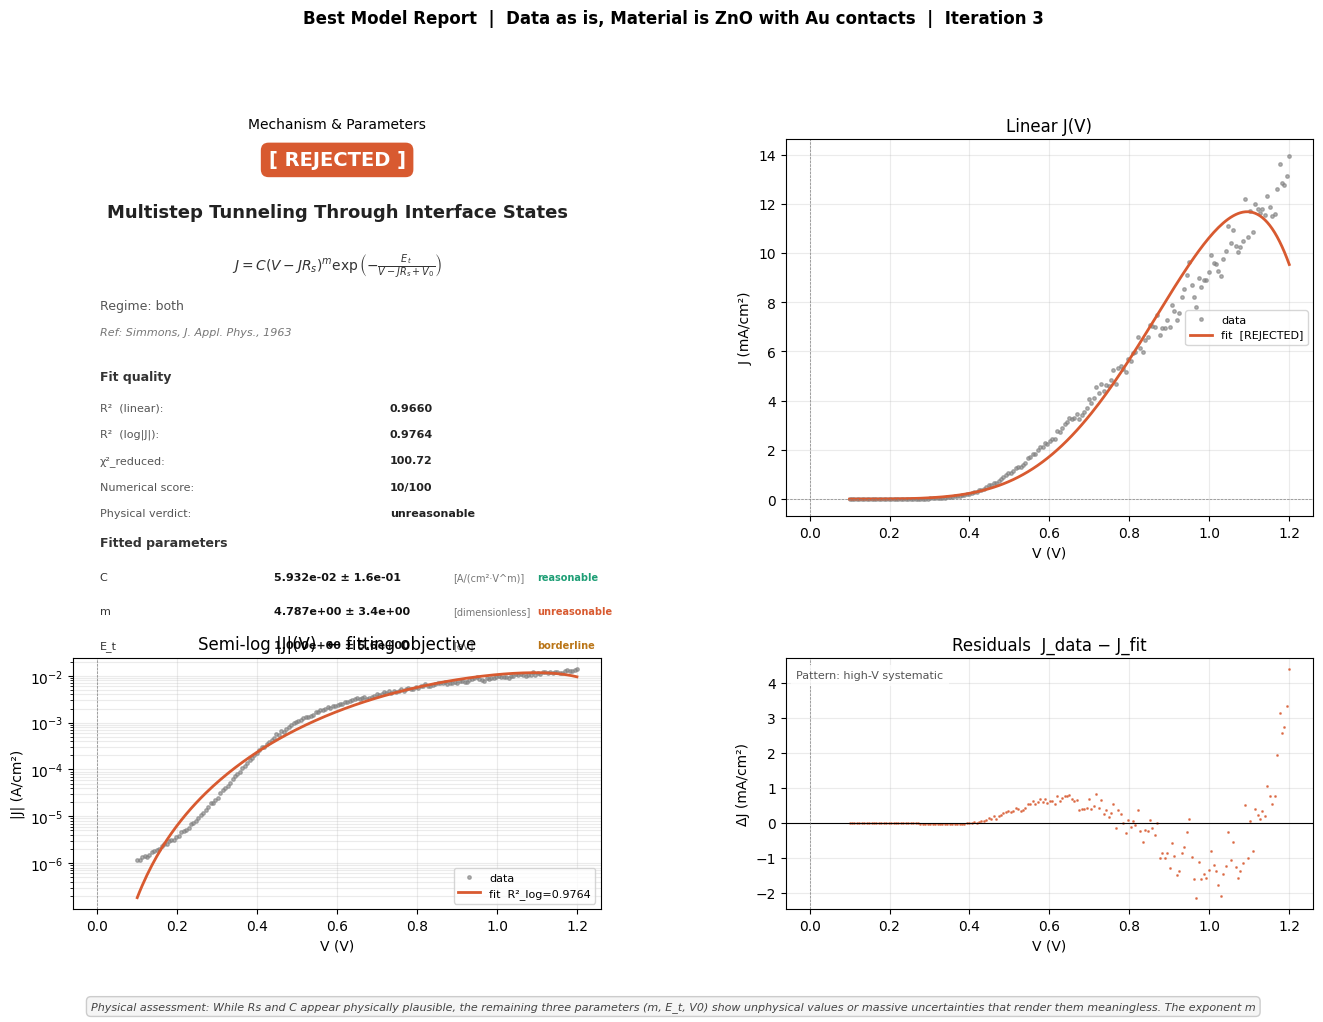

Saved: best_model_report.png


In [37]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Load outputs ──────────────────────────────────────────────
with open("agent2_output.json") as f: a2 = json.load(f)
with open("agent3_output.json") as f: a3 = json.load(f)

# ── Find best model ───────────────────────────────────────────
best_name = a2["summary"]["best_model"]
best_fit  = next(r for r in a2["fit_results"]
                 if r["mechanism_name"] == best_name)
best_jdg  = next(j for j in a3["judgements"]
                 if j["mechanism_name"] == best_name)

# ── Data arrays ───────────────────────────────────────────────
nd    = a2["normalized_data"]
V     = np.array(nd["V_V"])
J     = np.array([x if x is not None else np.nan for x in nd["J_Acm2"]])
J_fit = np.array(best_fit["J_fit"])
res   = J - J_fit

# ── Metrics ───────────────────────────────────────────────────
R2    = best_fit.get("R2")
R2l   = best_fit.get("R2_log")
chi2r = best_fit.get("chi2_reduced")
verdict    = best_jdg["final_verdict"].upper()
phys_v     = best_jdg["physical_verdict"]
num_score  = best_jdg["numerical_quality_score"]
verdict_color = {
    "ACCEPTED" : "#1D9E75",
    "PLAUSIBLE": "#378ADD",
    "MARGINAL" : "#BA7517",
    "REJECTED" : "#D85A30",
}.get(verdict, "gray")

# ── Figure ────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35,
                         height_ratios=[1.8, 1.2])

# ── Panel 1: mechanism + formula (text) ──────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax0.axis("off")

# Verdict badge
ax0.text(0.5, 0.97, f"[ {verdict} ]",
         ha="center", va="top", transform=ax0.transAxes,
         fontsize=14, fontweight="bold", color="white",
         bbox=dict(fc=verdict_color, ec="none",
                   boxstyle="round,pad=0.4"))

# Mechanism name
ax0.text(0.5, 0.83, best_name.replace("_"," "),
         ha="center", va="top", transform=ax0.transAxes,
         fontsize=13, fontweight="bold", color="#222222")

# Equation (LaTeX)
eq = best_fit.get("equation_latex","—")
ax0.text(0.5, 0.70, f"${eq}$",
         ha="center", va="top", transform=ax0.transAxes,
         fontsize=10, color="#333333",
         wrap=True)

# Regime + reference
regime = best_fit.get("dominant_regime","—")
ref    = best_fit.get("literature_ref","—")
ax0.text(0.05, 0.55, f"Regime: {regime}",
         transform=ax0.transAxes, fontsize=9, color="#555555")
ax0.text(0.05, 0.48, f"Ref: {ref}",
         transform=ax0.transAxes, fontsize=8,
         color="#777777", style="italic")

# Fit metrics
ax0.text(0.05, 0.36, "Fit quality",
         transform=ax0.transAxes, fontsize=9,
         fontweight="bold", color="#333333")
metrics = [
    ("R²  (linear)",  f"{R2:.4f}"  if R2  is not None else "N/A"),
    ("R²  (log|J|)",  f"{R2l:.4f}" if R2l is not None else "N/A"),
    ("χ²_reduced",    f"{chi2r:.2f}" if chi2r is not None else "N/A"),
    ("Numerical score", f"{num_score}/100"),
    ("Physical verdict", phys_v),
]
for i, (label, val) in enumerate(metrics):
    ax0.text(0.05, 0.28 - i*0.07, f"{label}:", fontsize=8,
             transform=ax0.transAxes, color="#555555")
    ax0.text(0.60, 0.28 - i*0.07, val, fontsize=8,
             transform=ax0.transAxes, fontweight="bold", color="#222222")

# Parameter table
ax0.text(0.05, -0.08, "Fitted parameters",
         transform=ax0.transAxes, fontsize=9,
         fontweight="bold", color="#333333")
fps_meta = {fp["name"]: fp for fp in best_fit.get("free_params_meta", [])}
for i, (pname, pval) in enumerate(best_fit["fit_params"].items()):
    perr  = best_fit["param_errors"].get(pname, float("nan"))
    units = fps_meta.get(pname, {}).get("units", "")
    pcheck= next((pc for pc in best_jdg.get("parameter_checks",[])
                  if pc.get("param_name")==pname), {})
    assess= pcheck.get("value_assessment","—")
    assess_col = {"reasonable":"#1D9E75",
                  "borderline":"#BA7517",
                  "unreasonable":"#D85A30"}.get(assess,"gray")
    row = -0.17 - i*0.09
    ax0.text(0.05, row, f"{pname}",
             transform=ax0.transAxes, fontsize=8, color="#333333")
    ax0.text(0.38, row, f"{pval:.3e} ± {perr:.1e}",
             transform=ax0.transAxes, fontsize=8,
             fontweight="bold", color="#111111")
    ax0.text(0.72, row, f"[{units}]",
             transform=ax0.transAxes, fontsize=7, color="#777777")
    ax0.text(0.88, row, assess,
             transform=ax0.transAxes, fontsize=7,
             fontweight="bold", color=assess_col)

ax0.set_title("Mechanism & Parameters", fontsize=10, pad=8)

# ── Panel 2: linear J(V) ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(V, J*1e3, "o", ms=2.5, color="gray",
         alpha=0.6, label="data")
ax1.plot(V, J_fit*1e3, "-", lw=2, color=verdict_color,
         label=f"fit  [{verdict}]")
ax1.set(xlabel="V (V)", ylabel="J (mA/cm²)",
        title="Linear J(V)")
ax1.axhline(0, color="gray", lw=0.5, ls="--")
ax1.axvline(0, color="gray", lw=0.5, ls="--")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.25)

# ── Panel 3: semi-log |J|(V)  ← fitting objective ────────────
ax2 = fig.add_subplot(gs[1, 0])
absJ  = np.abs(J);     m1 = absJ  > 0
absJf = np.abs(J_fit); m2 = absJf > 0
ax2.semilogy(V[m1], absJ[m1],  "o", ms=2.5,
             color="gray", alpha=0.6, label="data")
ax2.semilogy(V[m2], absJf[m2], "-", lw=2,
             color=verdict_color,
             label=f"fit  R²_log={R2l:.4f}" if R2l else "fit")
ax2.set(xlabel="V (V)", ylabel="|J| (A/cm²)",
        title="Semi-log |J|(V)  ← fitting objective")
ax2.axvline(0, color="gray", lw=0.5, ls="--")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.25, which="both")

# ── Panel 4: residuals ────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(V, res*1e3, ".", ms=2, color=verdict_color, alpha=0.7)
ax3.axhline(0, color="black", lw=0.8)
ax3.axvline(0, color="gray",  lw=0.5, ls="--")
ax3.set(xlabel="V (V)", ylabel="ΔJ (mA/cm²)",
        title="Residuals  J_data − J_fit")
ax3.grid(True, alpha=0.25)

# Annotate residual pattern
rp = best_jdg.get("residual_pattern","?")
ax3.text(0.02, 0.95, f"Pattern: {rp}",
         transform=ax3.transAxes, fontsize=8,
         va="top", color="#555555",
         bbox=dict(fc="white", ec="none", alpha=0.8))

# ── Physical reasoning box ────────────────────────────────────
phys_text = best_jdg.get("physical_reasoning","")
fig.text(0.5, 0.01, f"Physical assessment: {phys_text[:180]}",
         ha="center", fontsize=8, color="#444444",
         style="italic",
         bbox=dict(fc="#f5f5f5", ec="#cccccc",
                   boxstyle="round,pad=0.4"))

fig.suptitle(
    f"Best Model Report  |  {a2['meta']['material_prompt']}  "
    f"|  Iteration {a2['meta']['iteration']}",
    fontsize=12, fontweight="bold", y=1.01
)

plt.savefig("best_model_report.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: best_model_report.png")